---
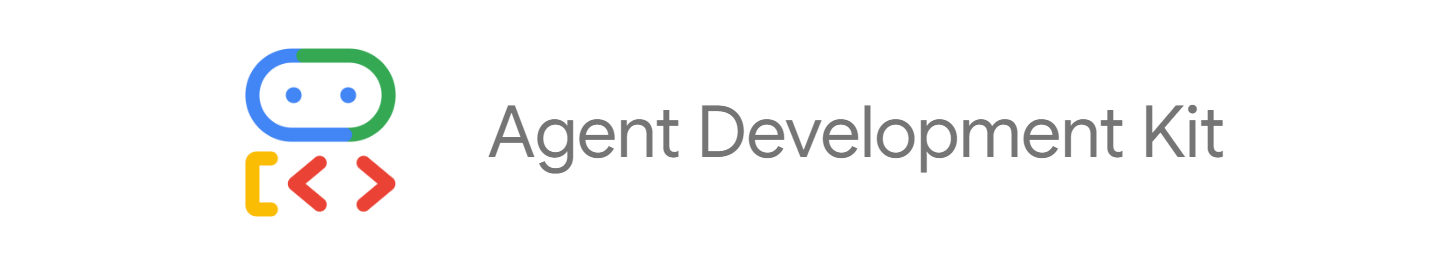

---

# Deploy to Vertex AI Agent Engine 👉 [Learn more](https://google.github.io/adk-docs/deploy/agent-engine/)
[Agent Engine](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview) is a fully managed Google Cloud service enabling developers to deploy, manage, and scale AI agents in production. Agent Engine handles the infrastructure to scale agents in production so you can focus on creating intelligent and impactful applications. This guide provides an accelerated deployment instruction set for when you want to deploy an ADK project quickly, and a standard, step-by-step set of instructions for when you want to carefully manage deploying an agent to Agent Engine.

## Accelerated deployment
This section describes how to perform a deployment using the [Agent Starter Pack](https://github.com/GoogleCloudPlatform/agent-starter-pack) (ASP) and the ADK command line interface (CLI) tool. This approach uses the ASP tool to apply a project template to your existing project, add deployment artifacts, and prepare your agent project for deployment. These instructions show you how to use ASP to provision a Google Cloud project with services needed for deploying your ADK project

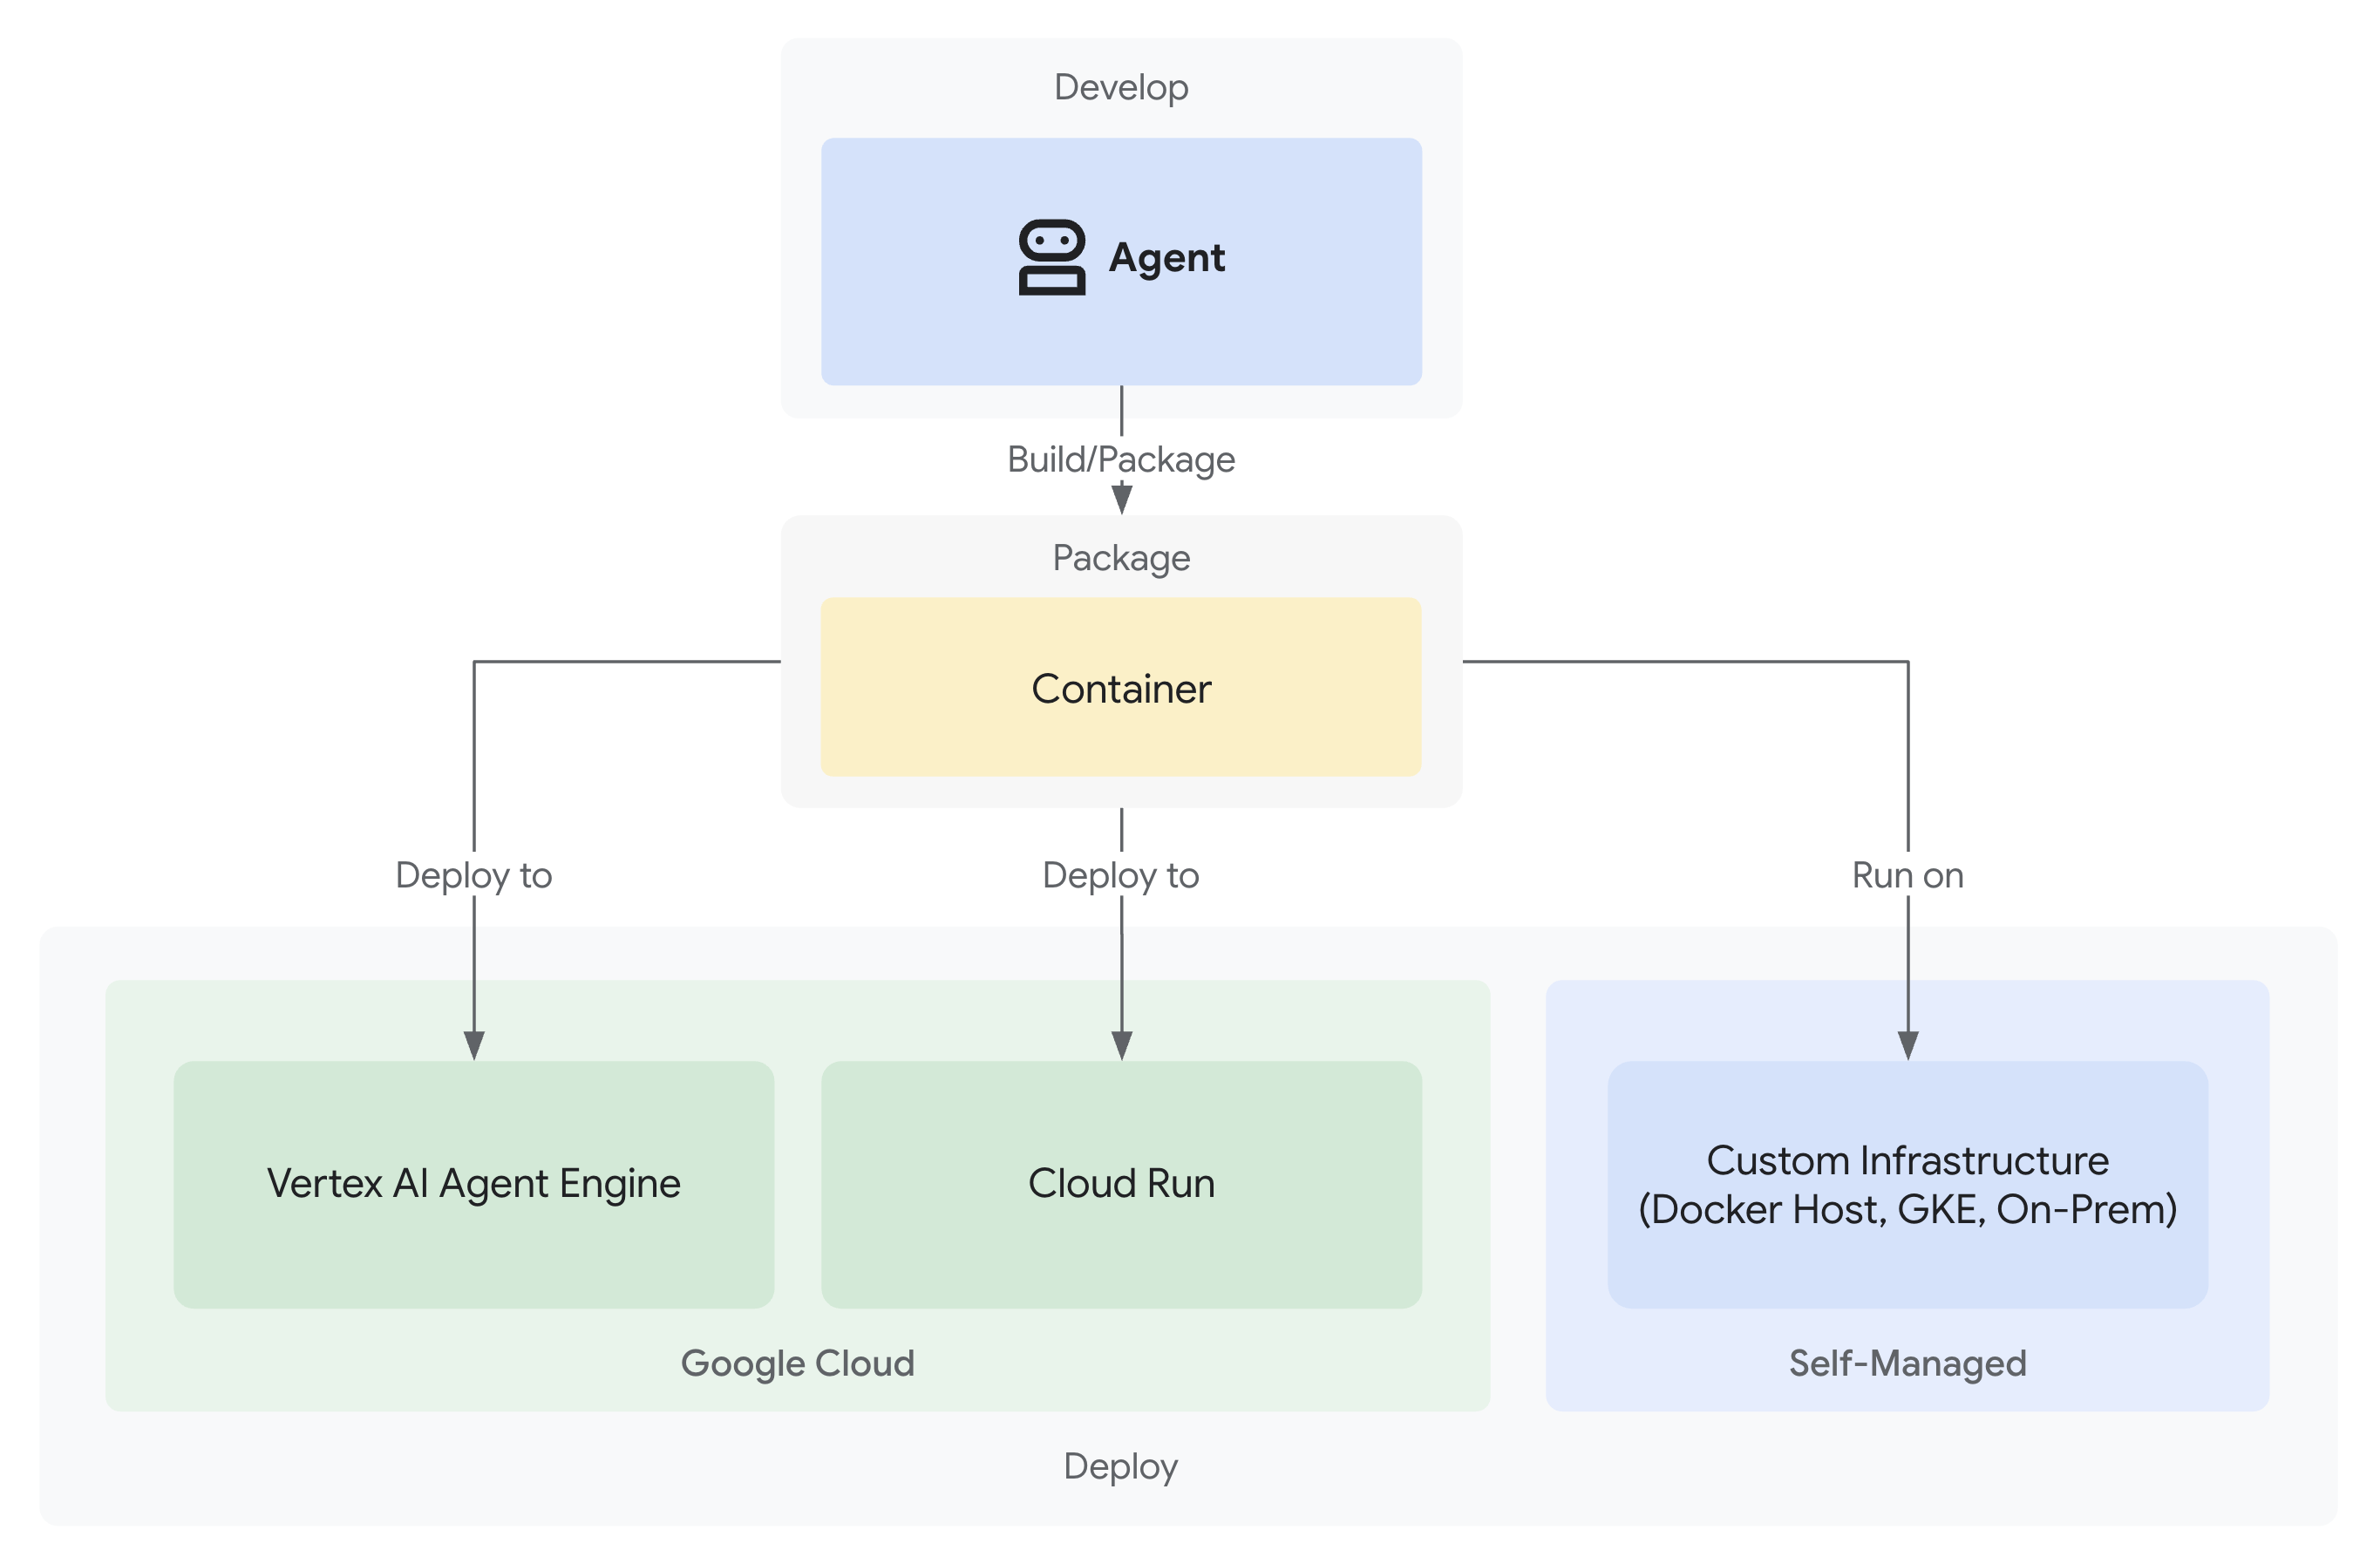

----

### Google Cloud
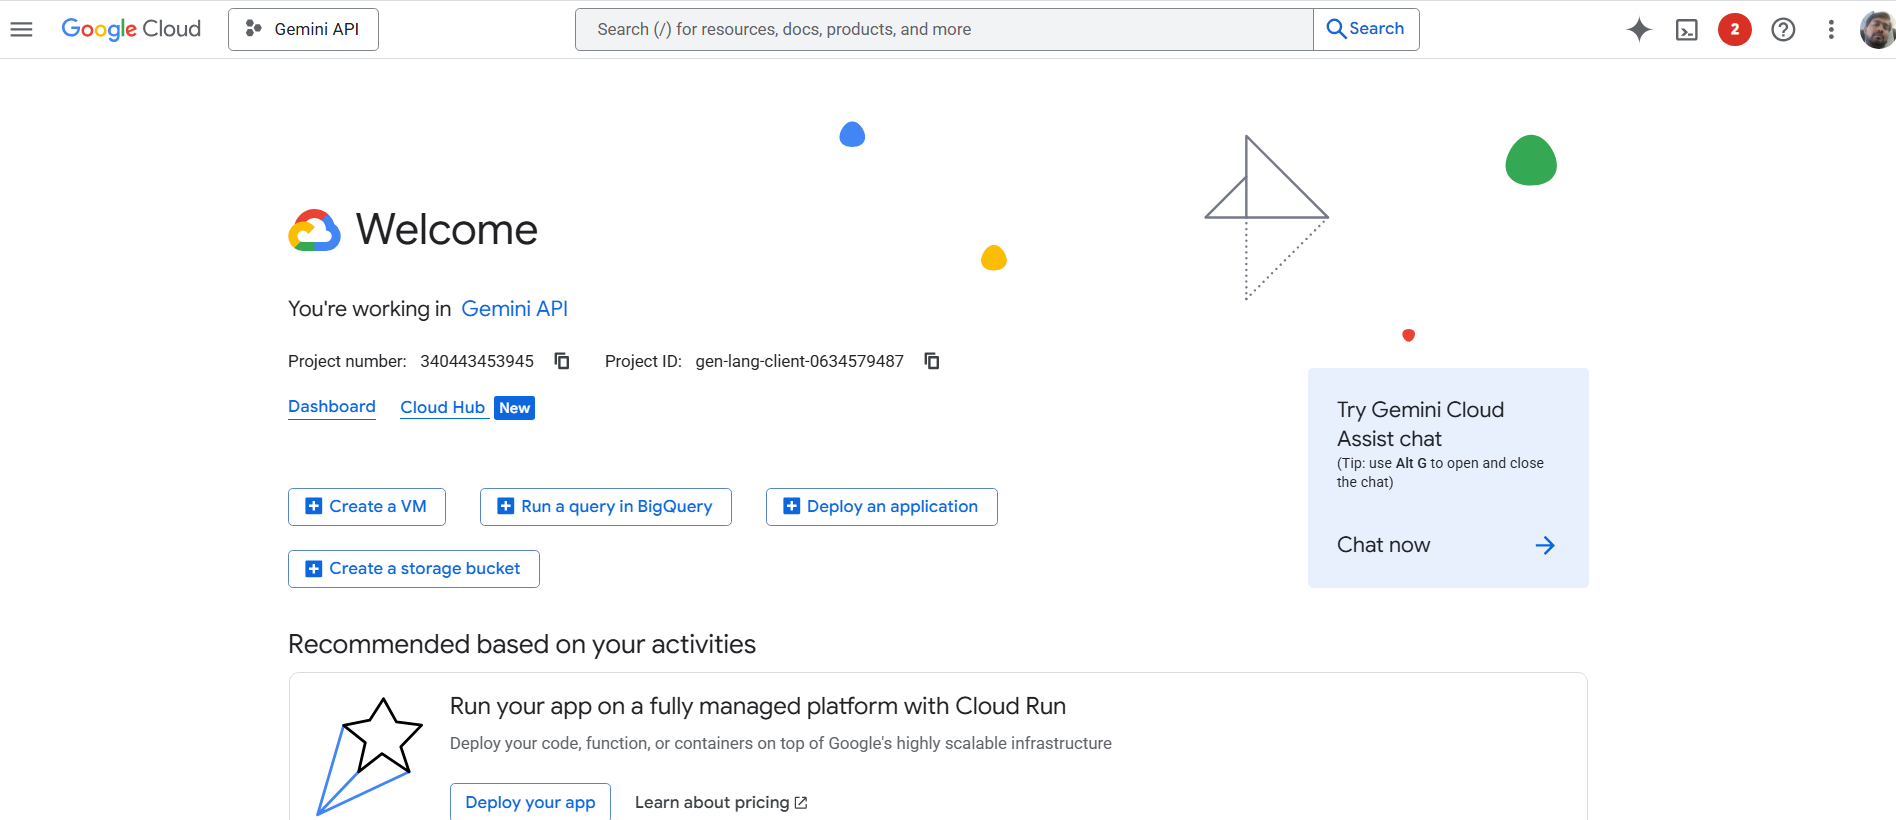 <br><br>

#### `Gcloud Authentication`
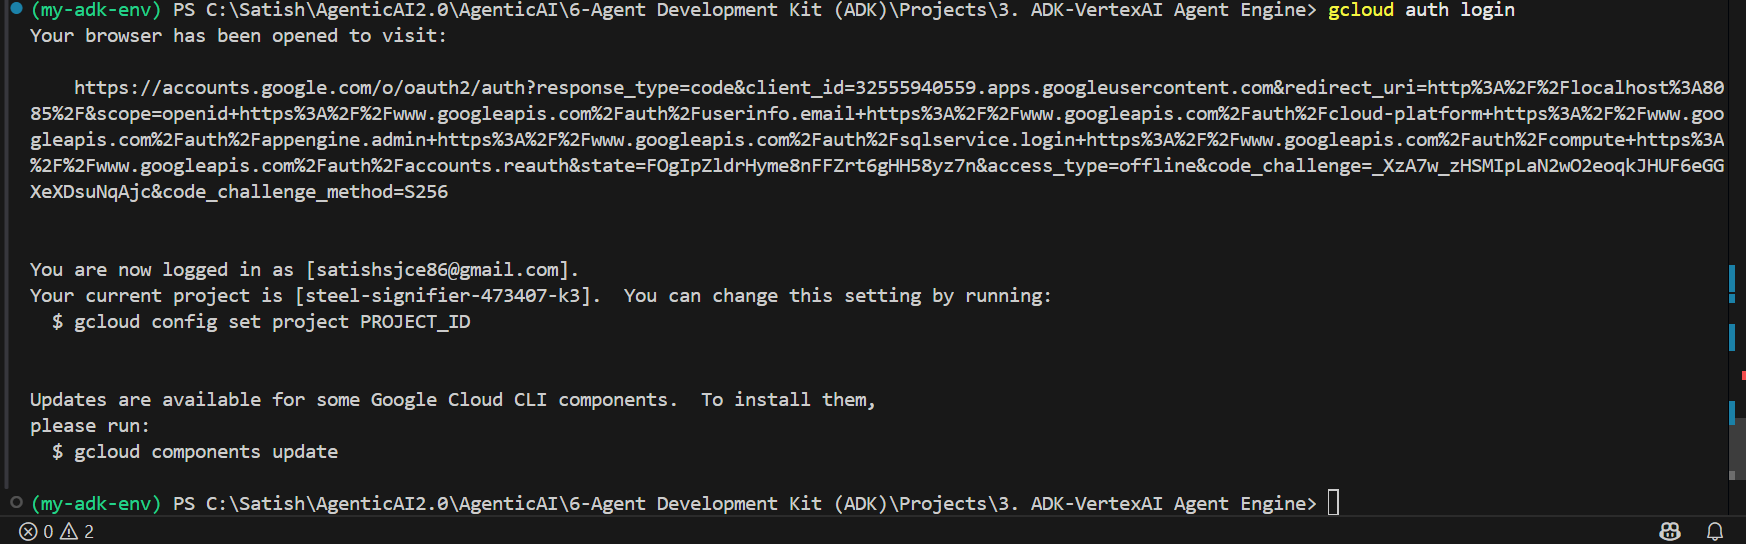 <br> 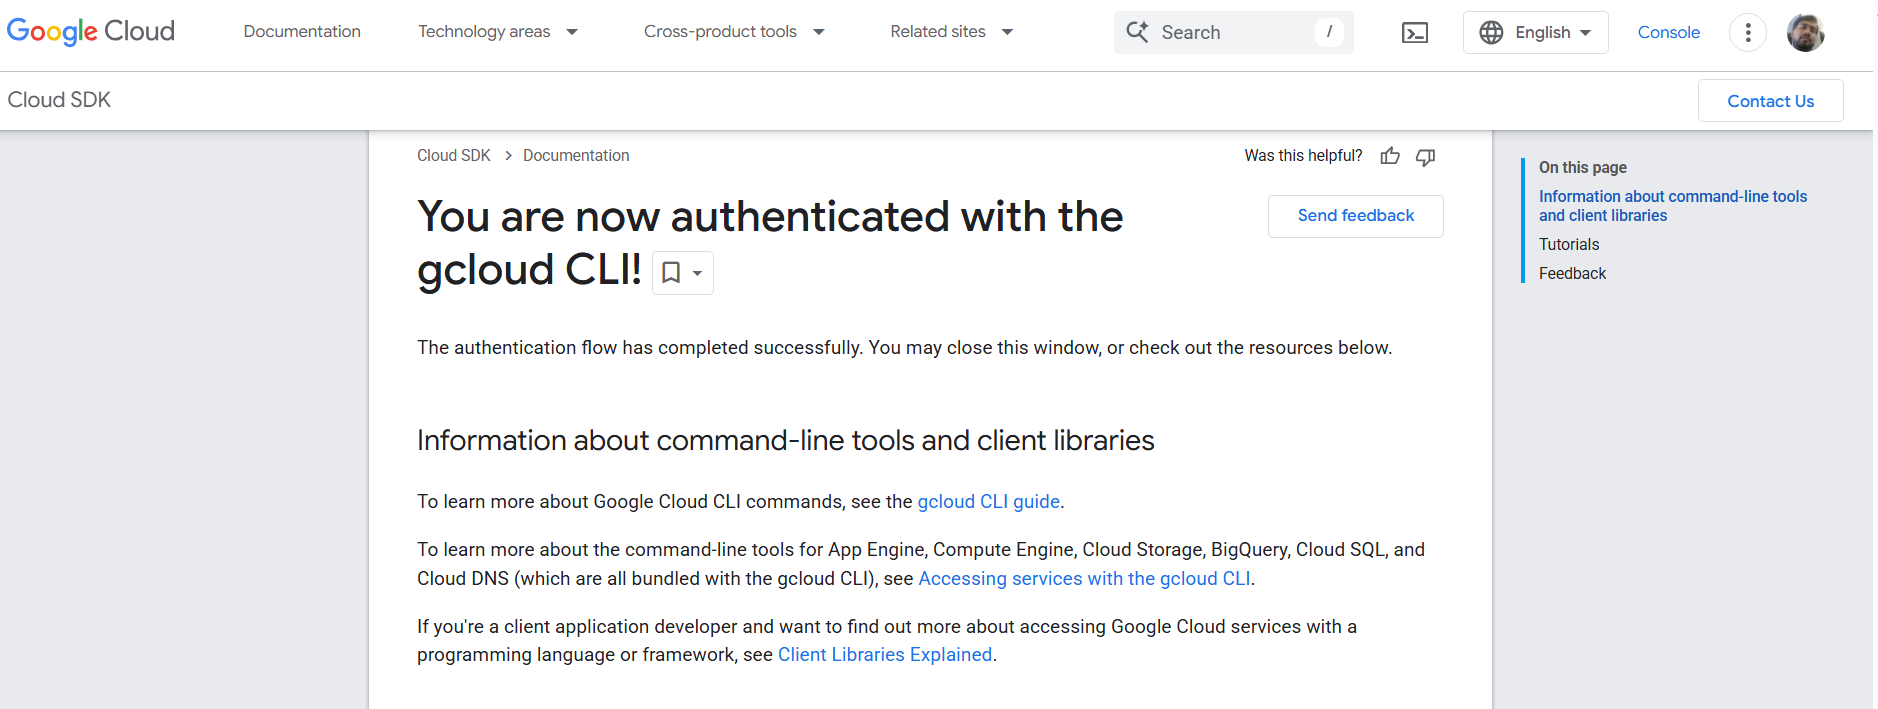 <br><br>

#### `updating correct Project ID`
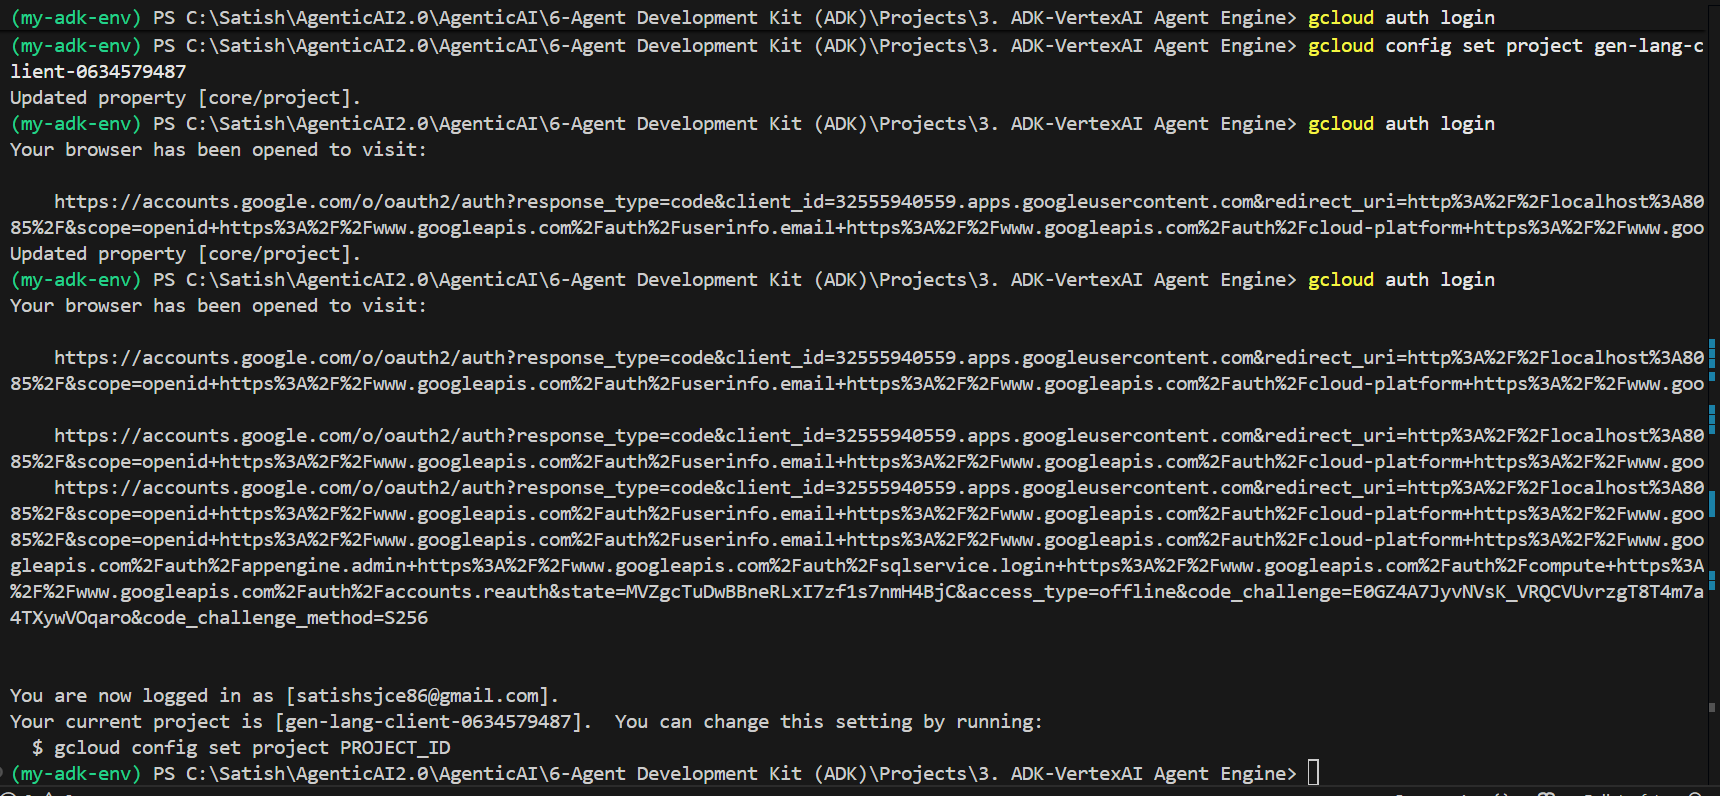 <br> 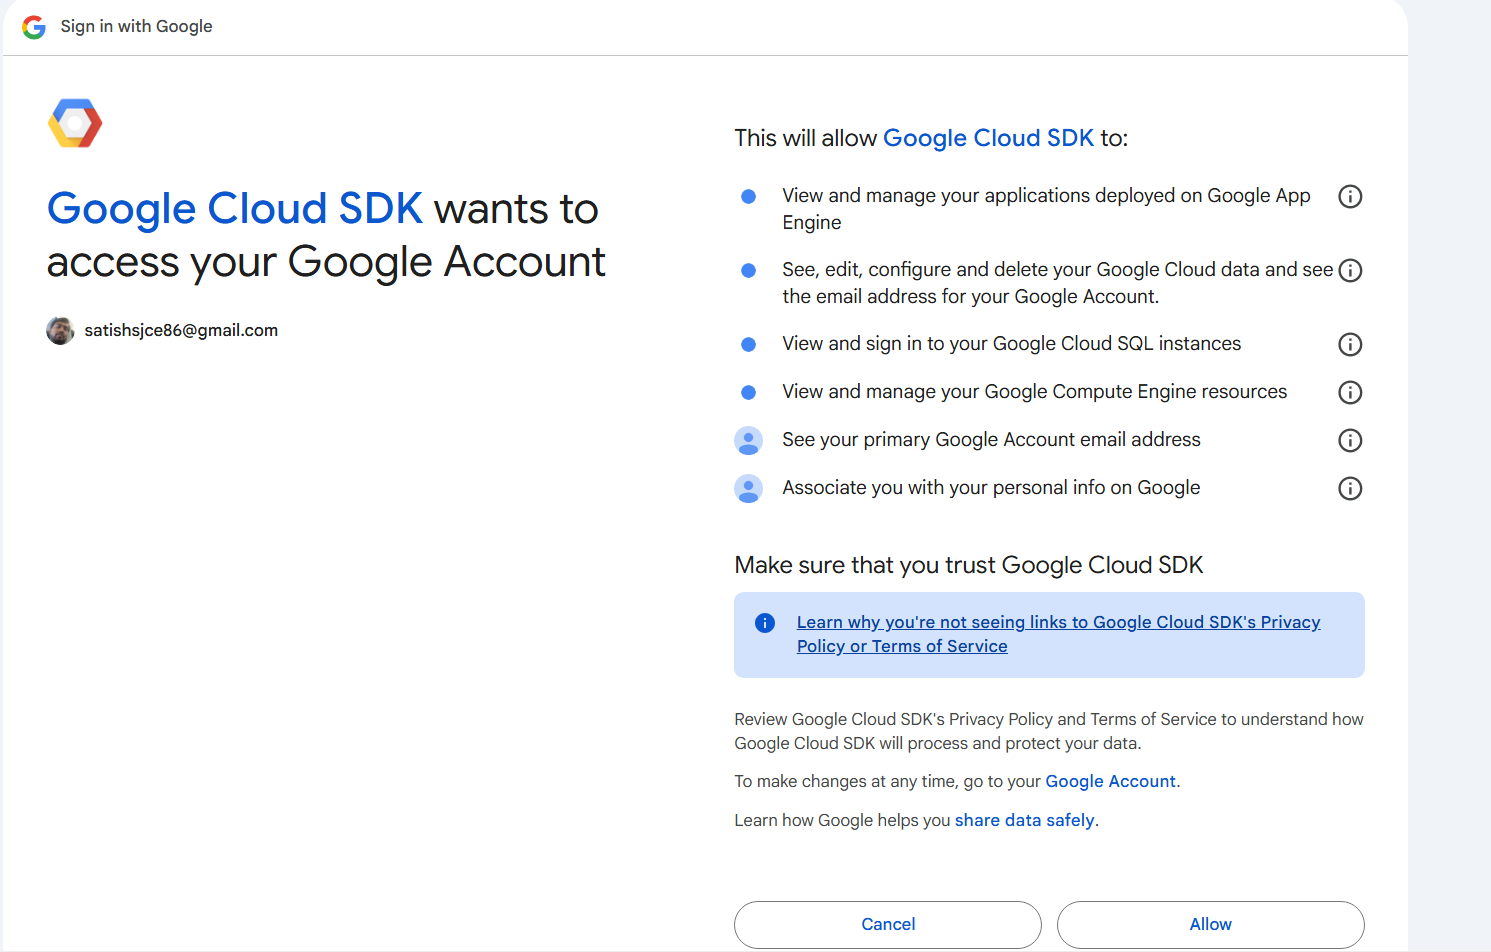 <br> 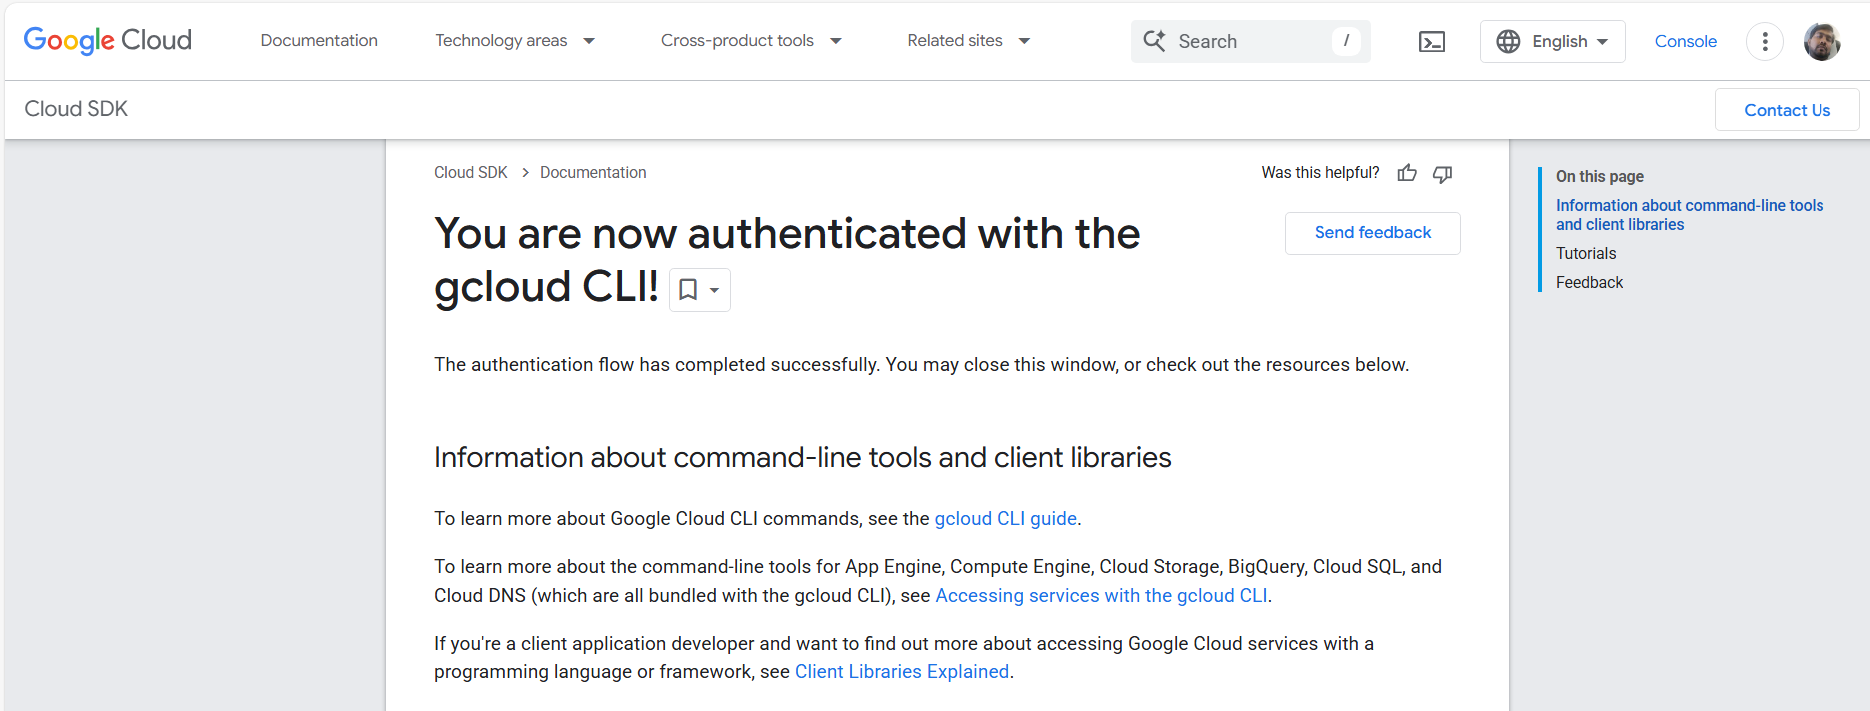 <br><br>

#### `Billing account management`
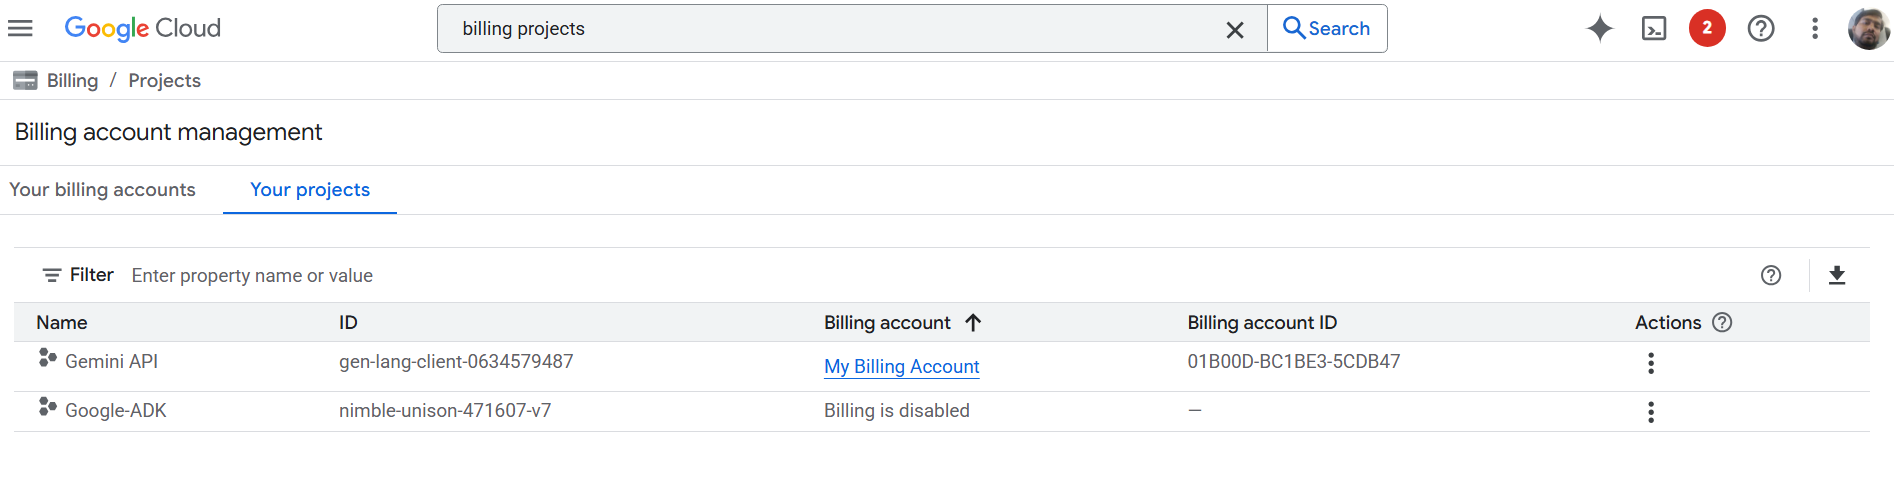

#### `Created a new directory -> vertex_ai_adk_deployment`
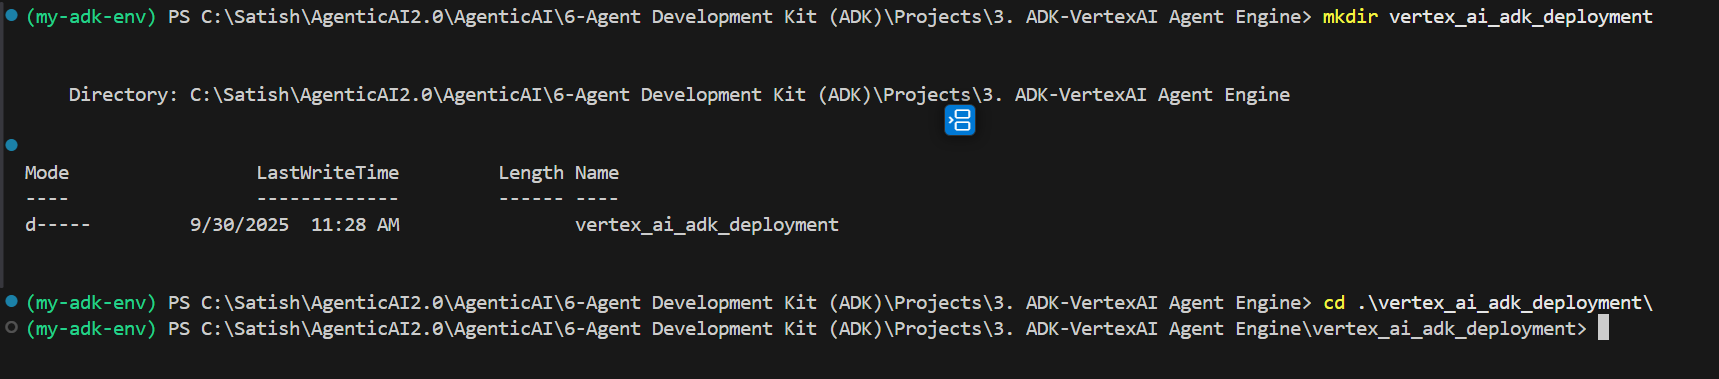

#### `multi_tool_agent`
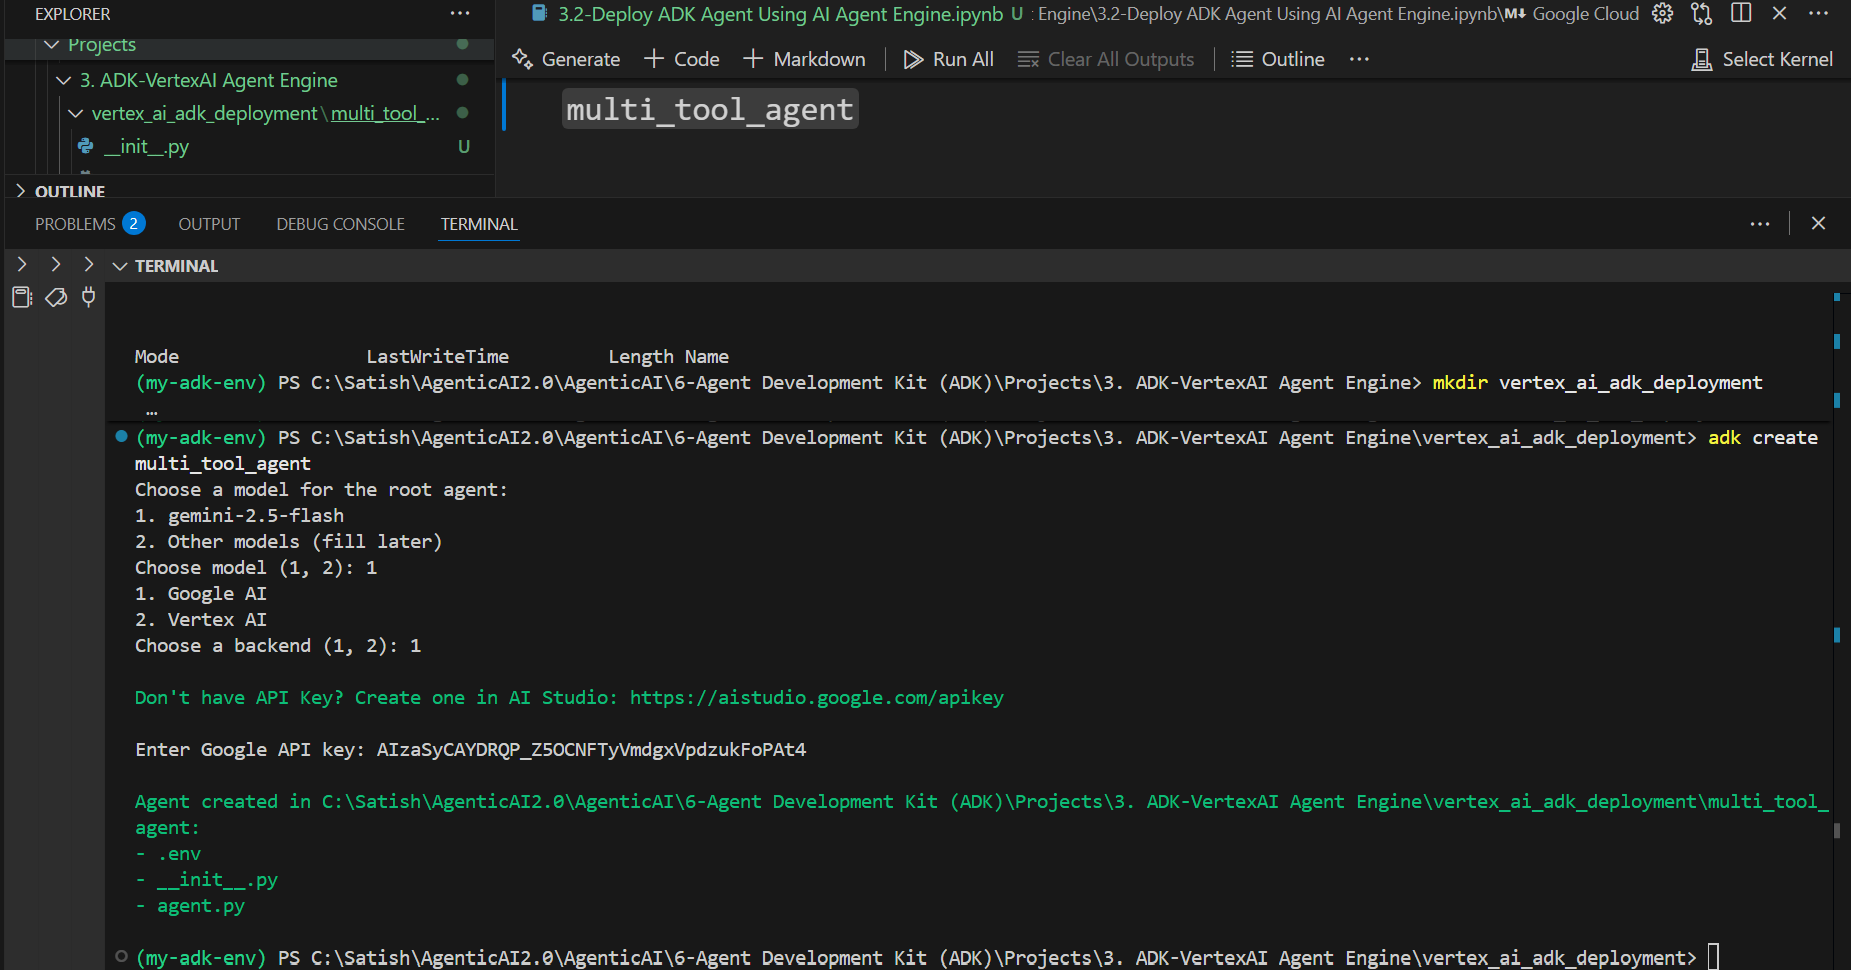 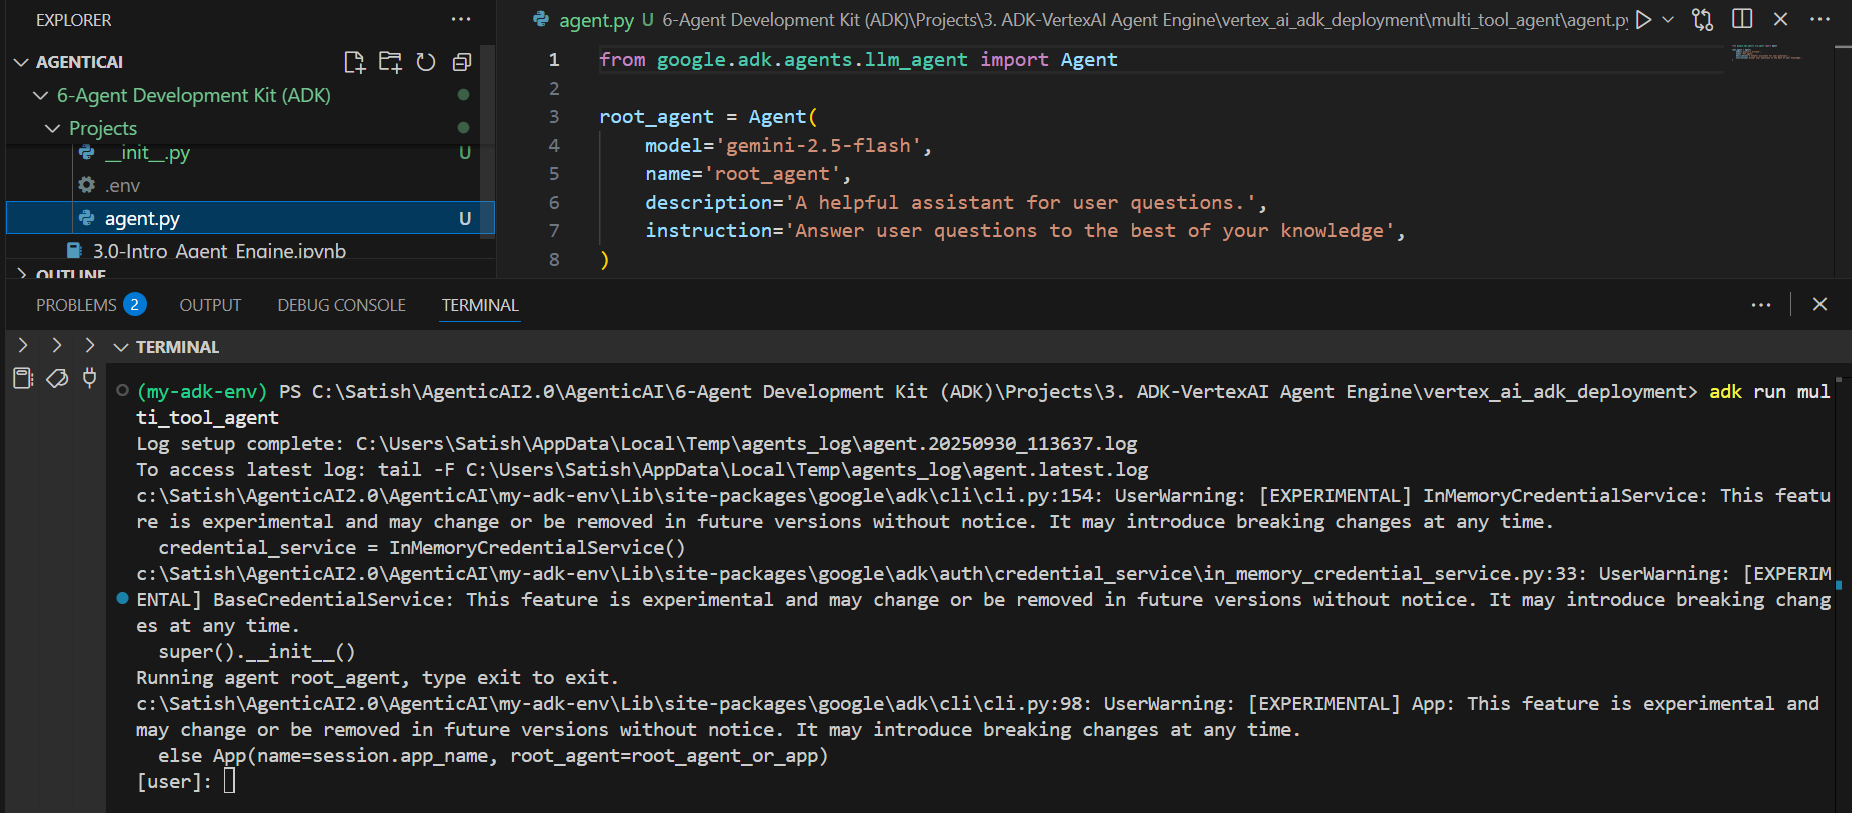 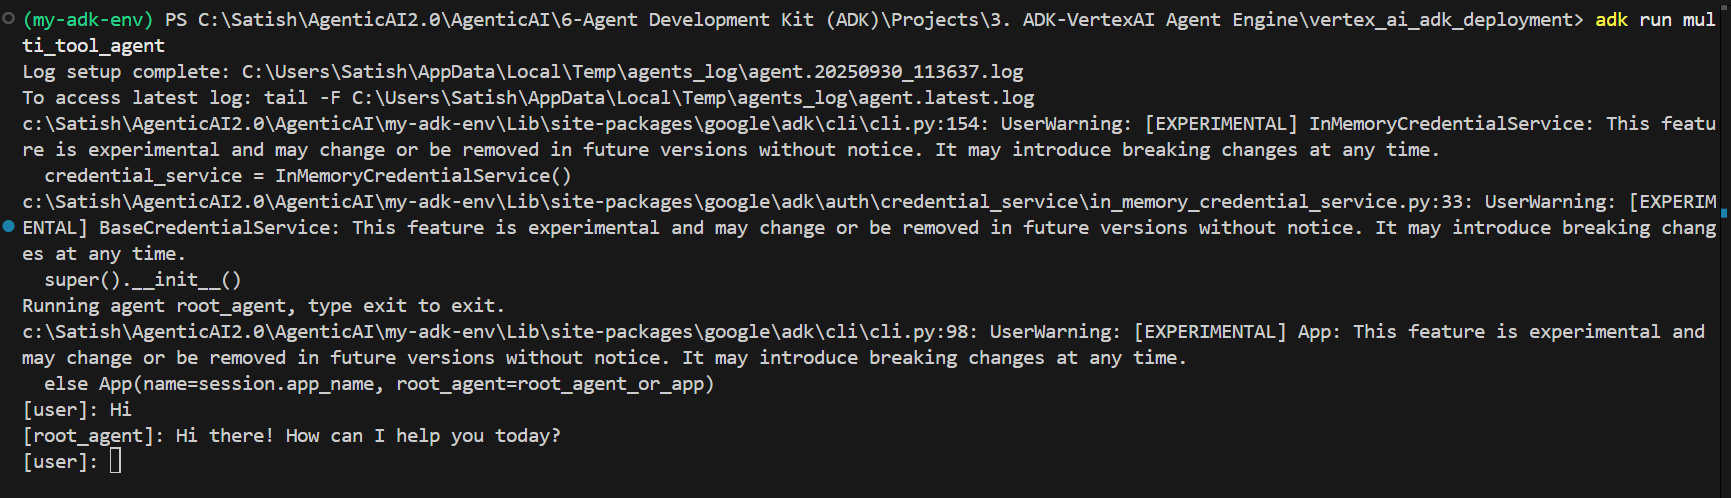 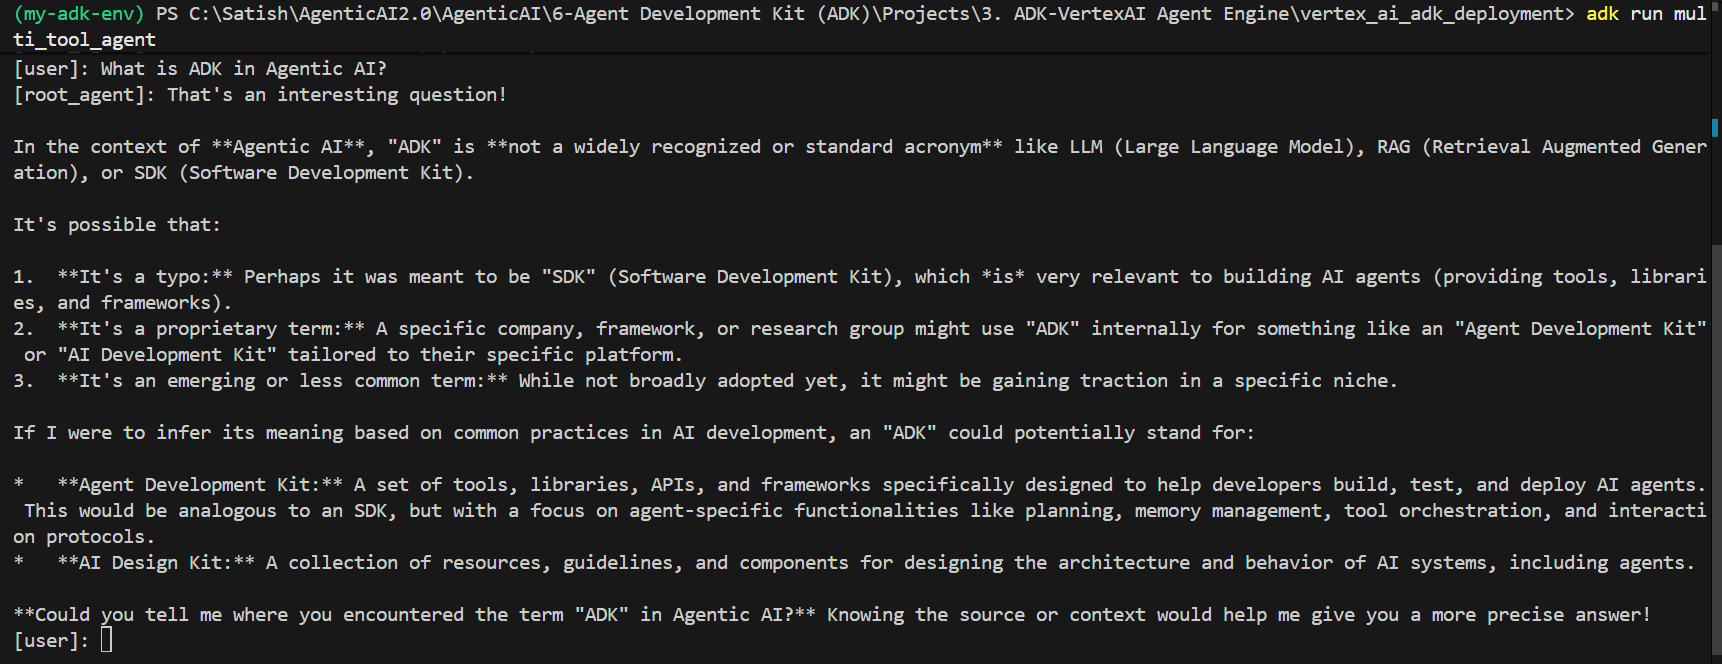

----

### Prepare your ADK project
Run the ASP `enhance` command to add the needed files required for deployment into your project.

uvx agent-starter-pack enhance --adk -d agent_engine

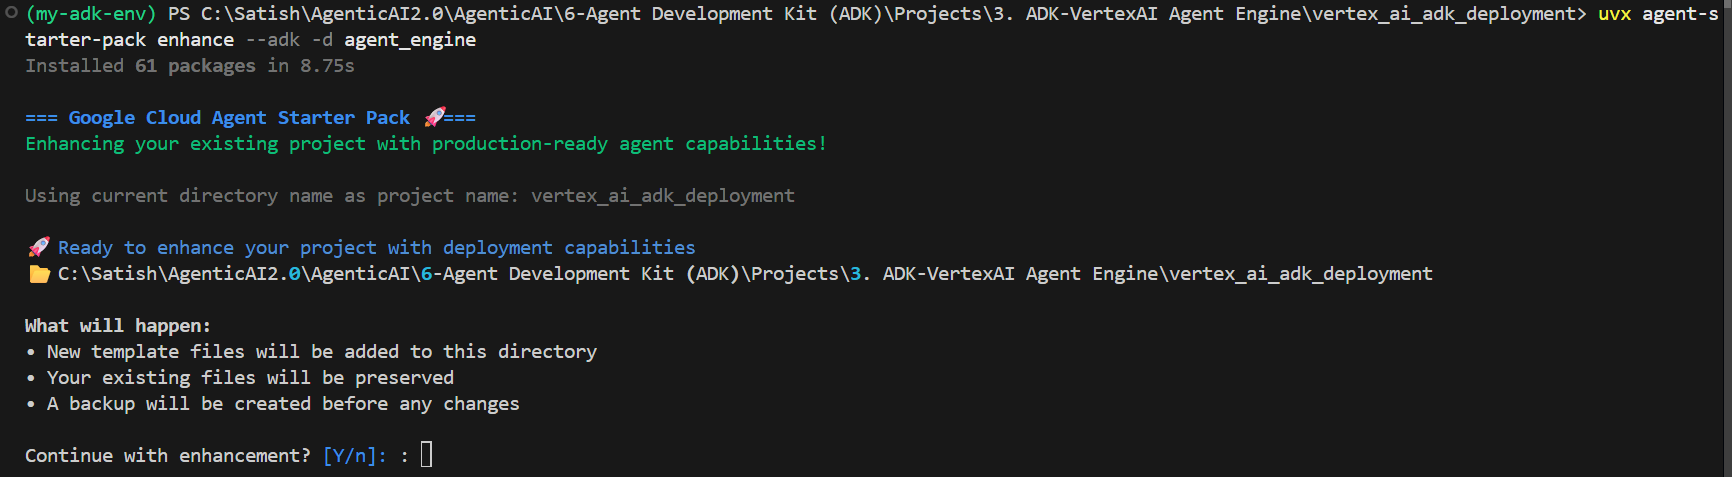 <br> 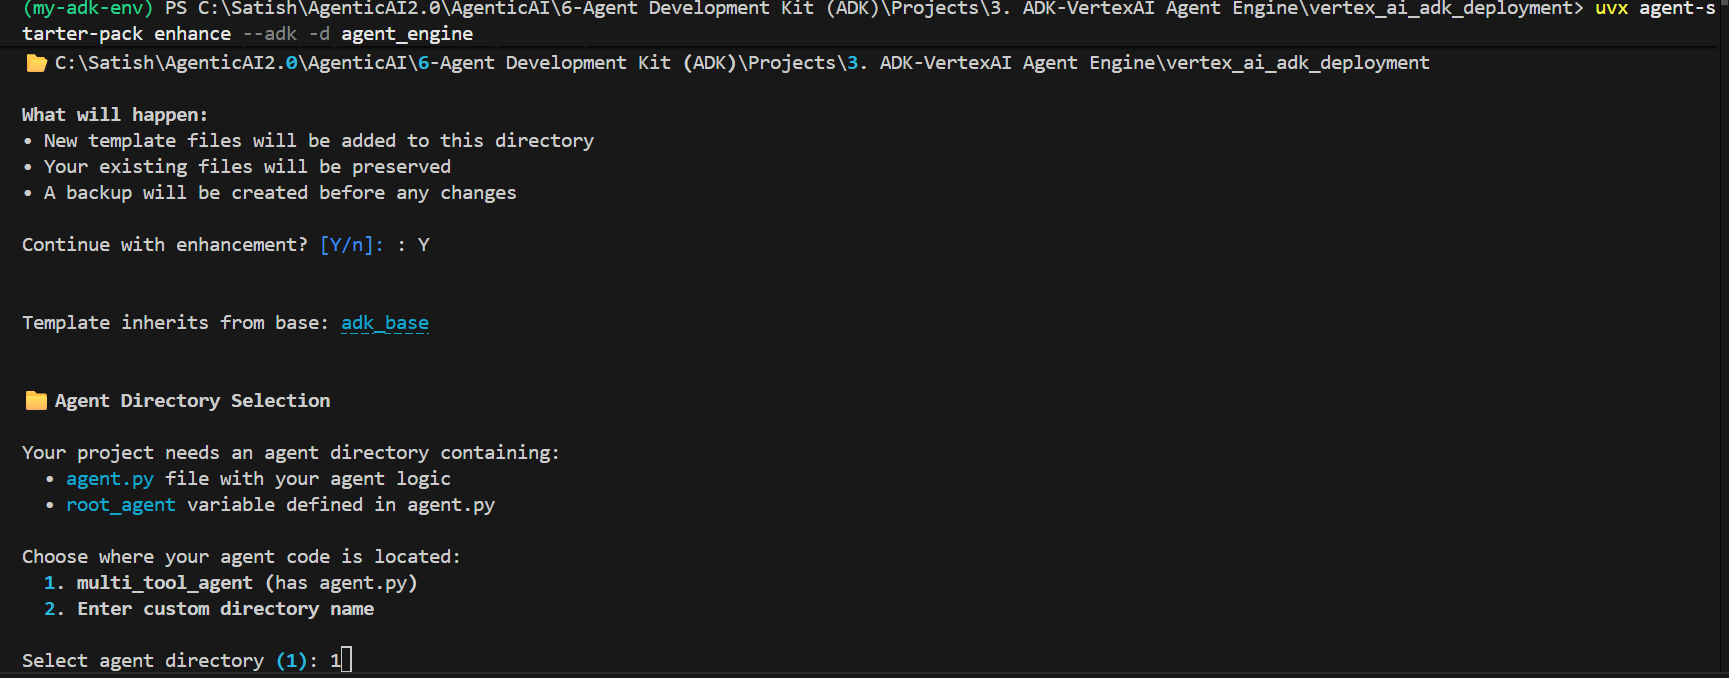 <br> 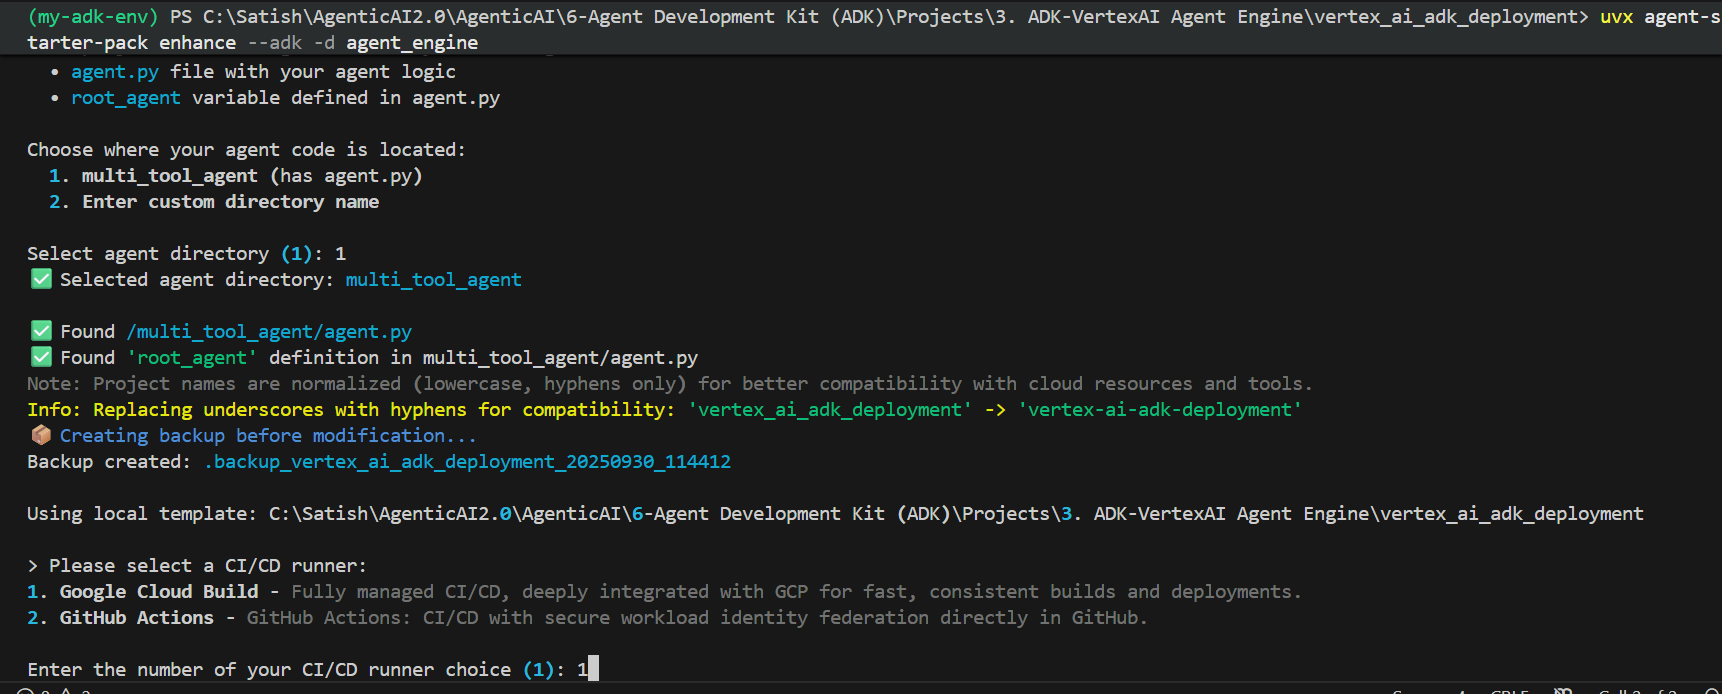 <br> 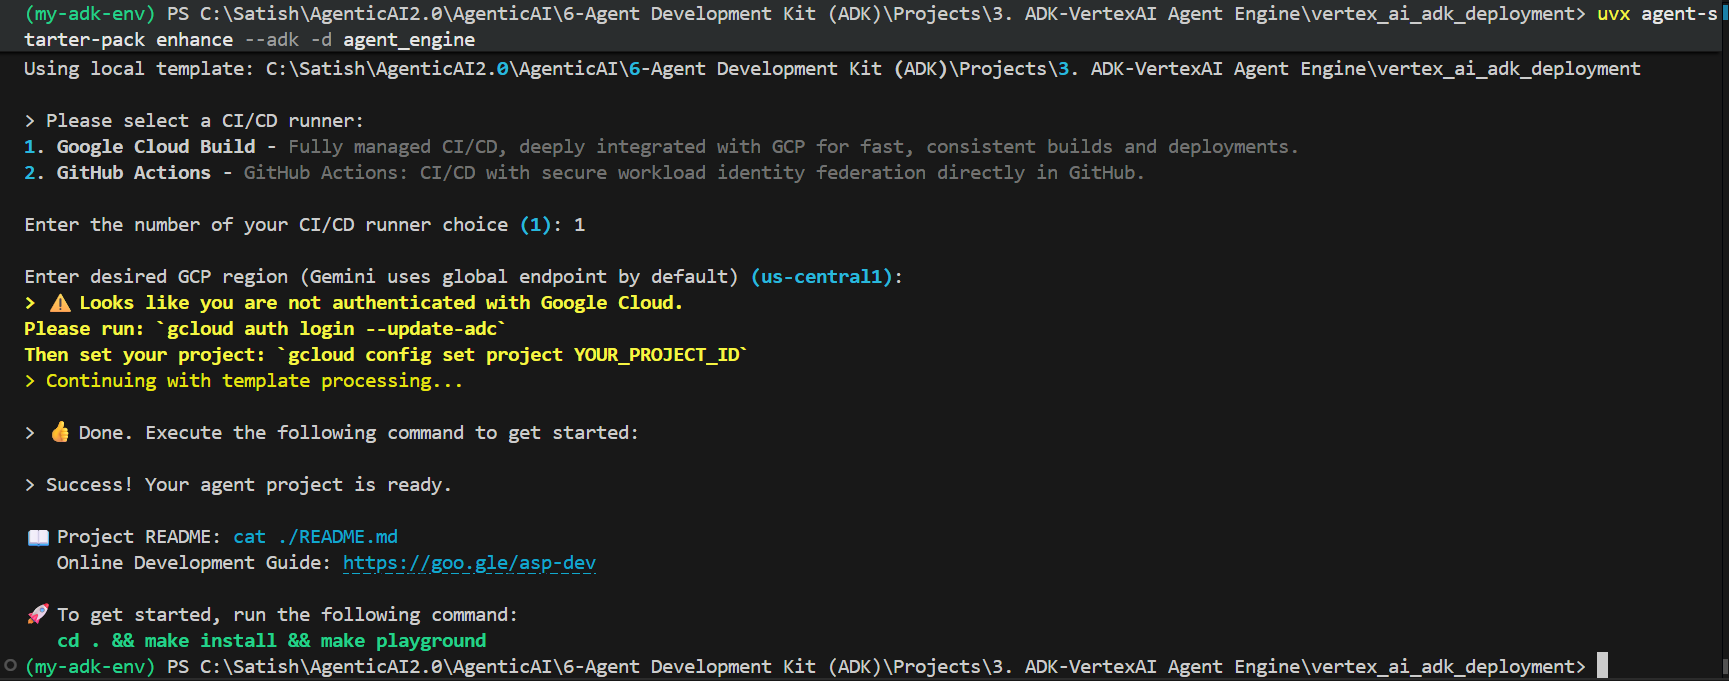 <br> 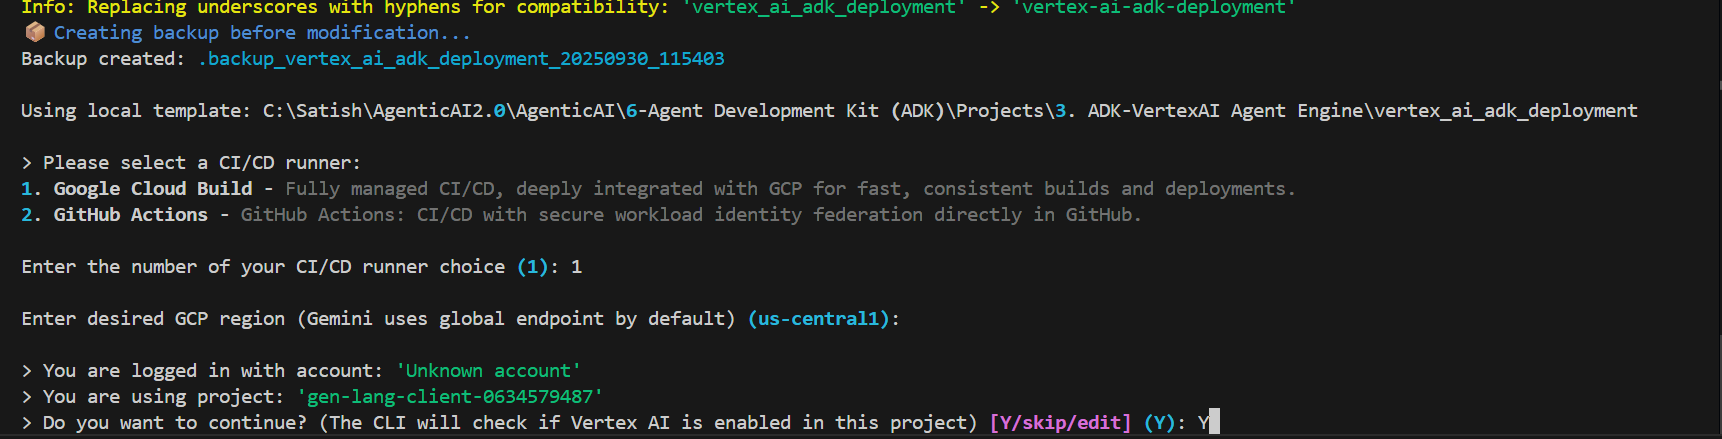 <br> 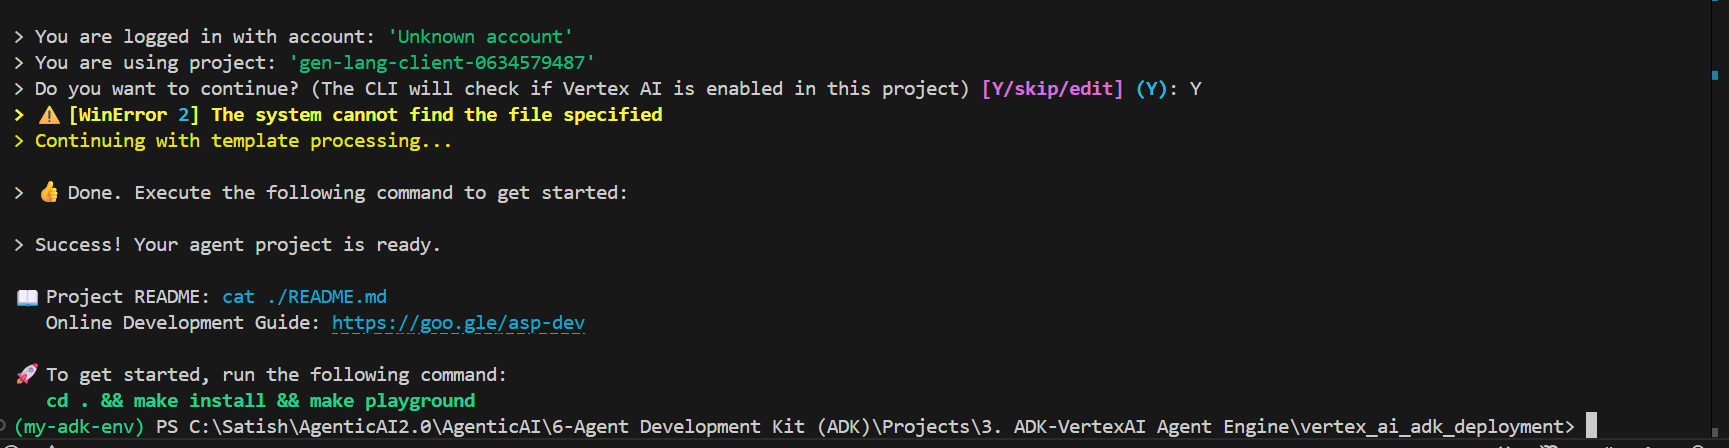 <br> 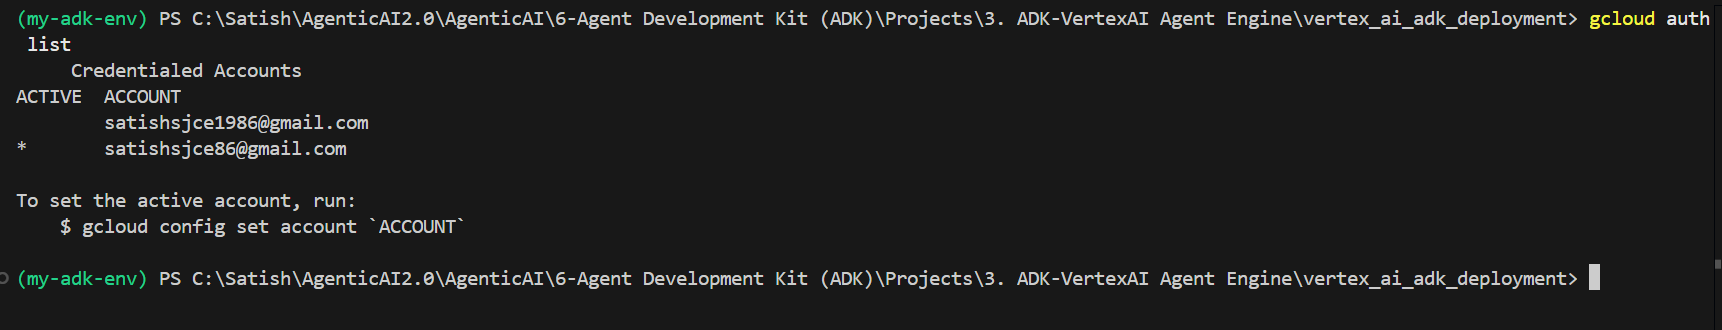 <br> 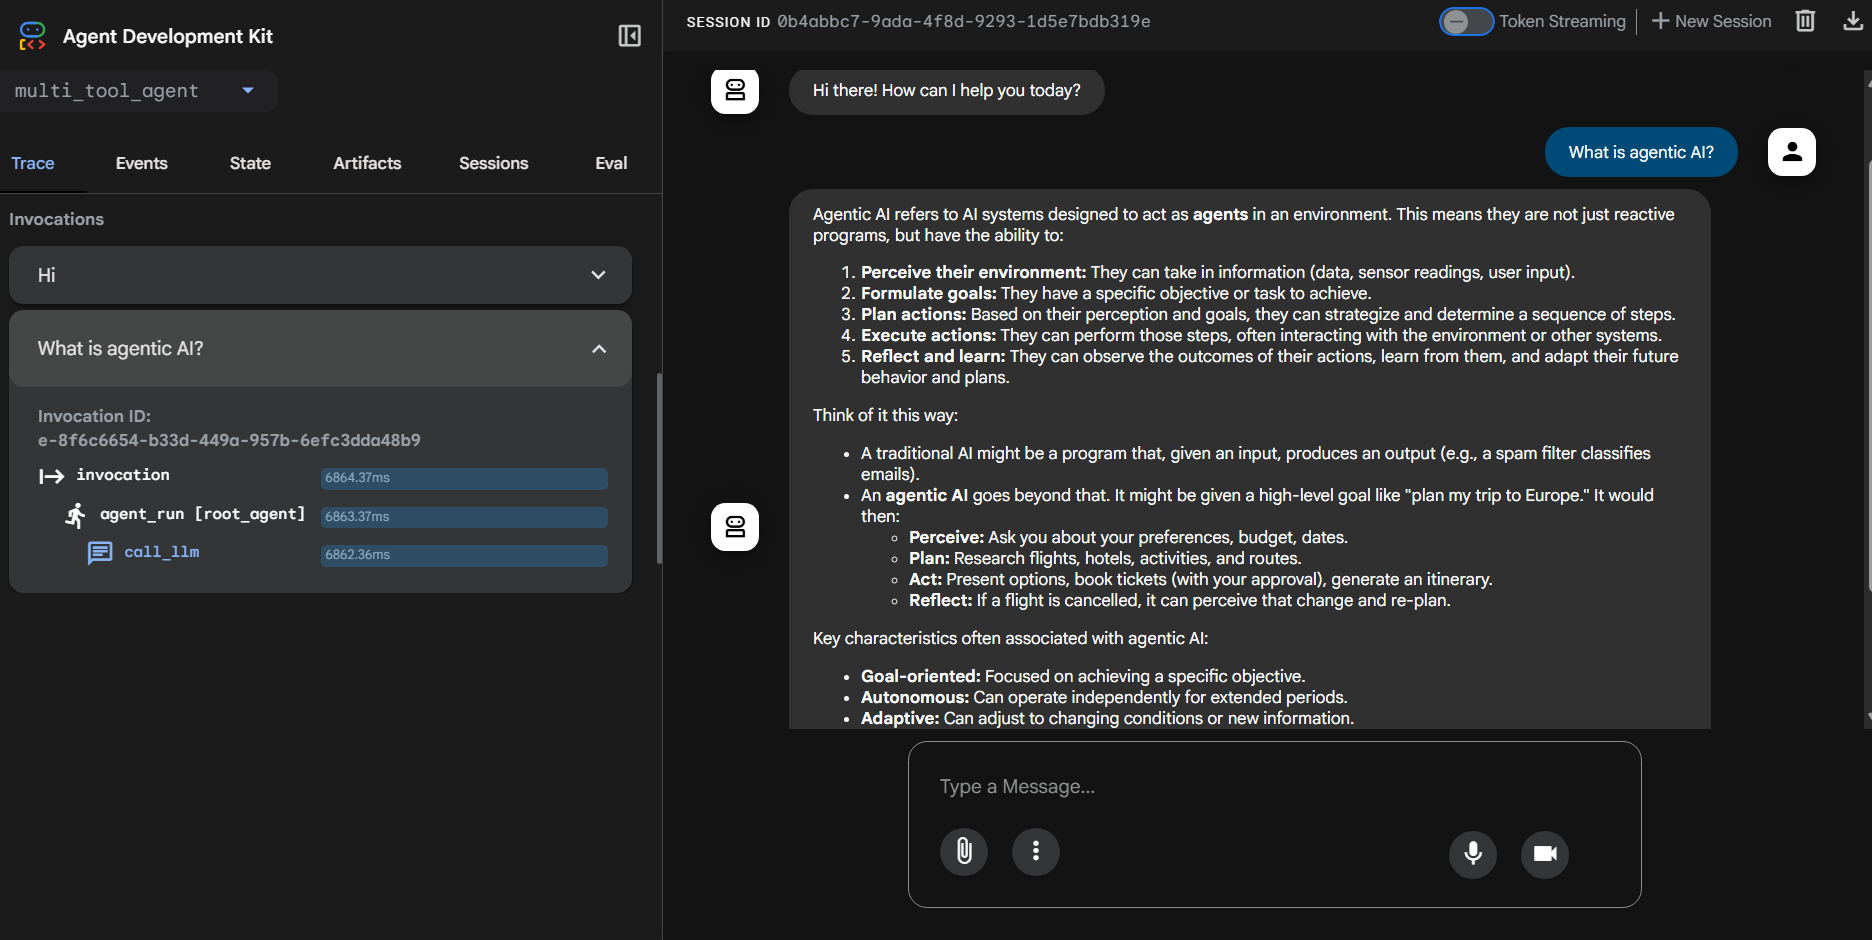 <br> 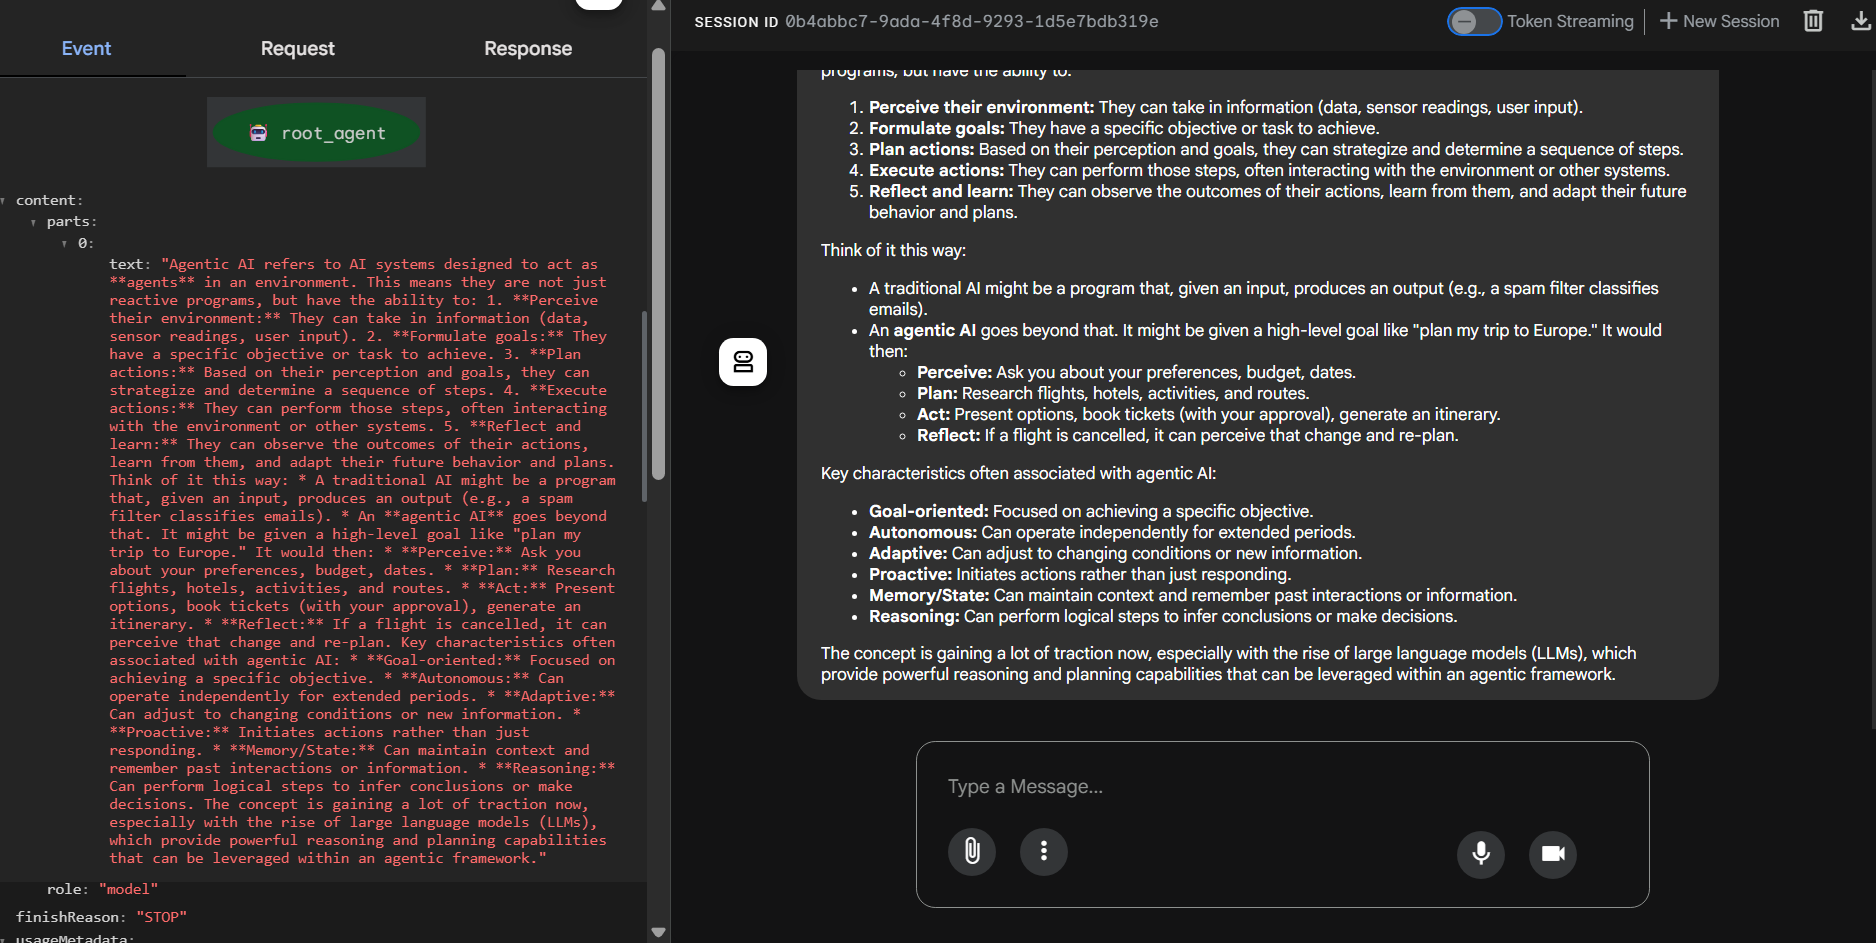 <br> 

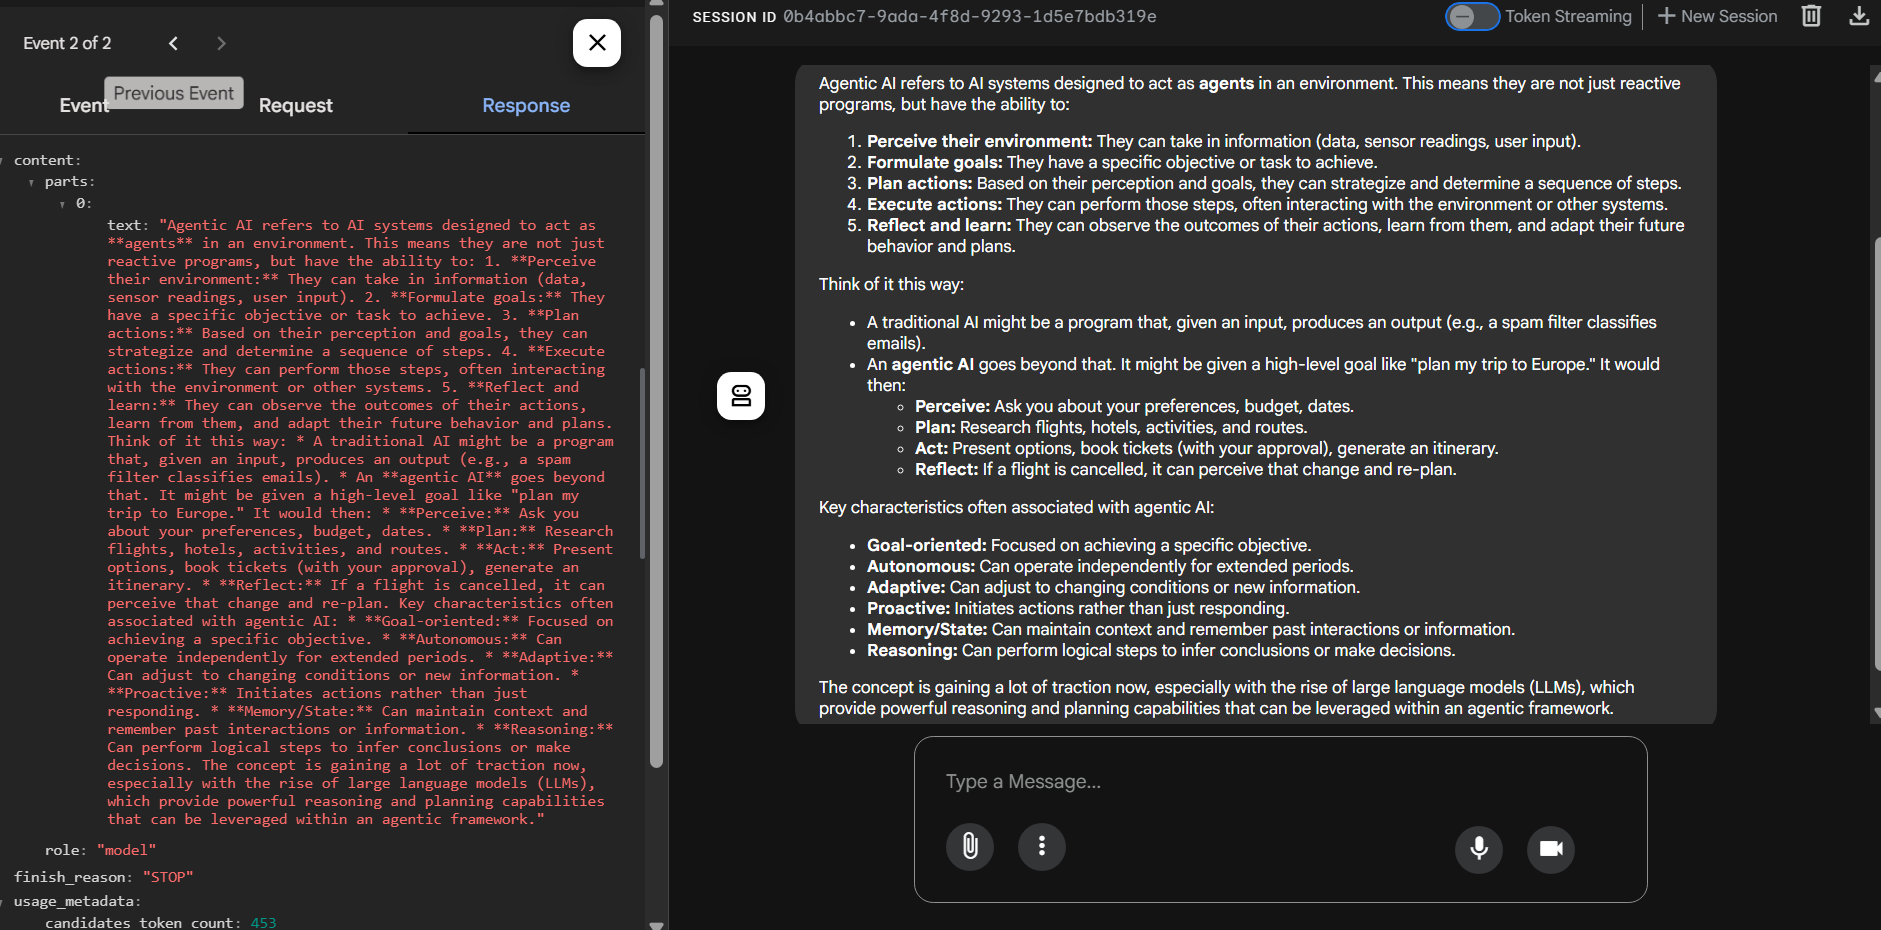 <br> 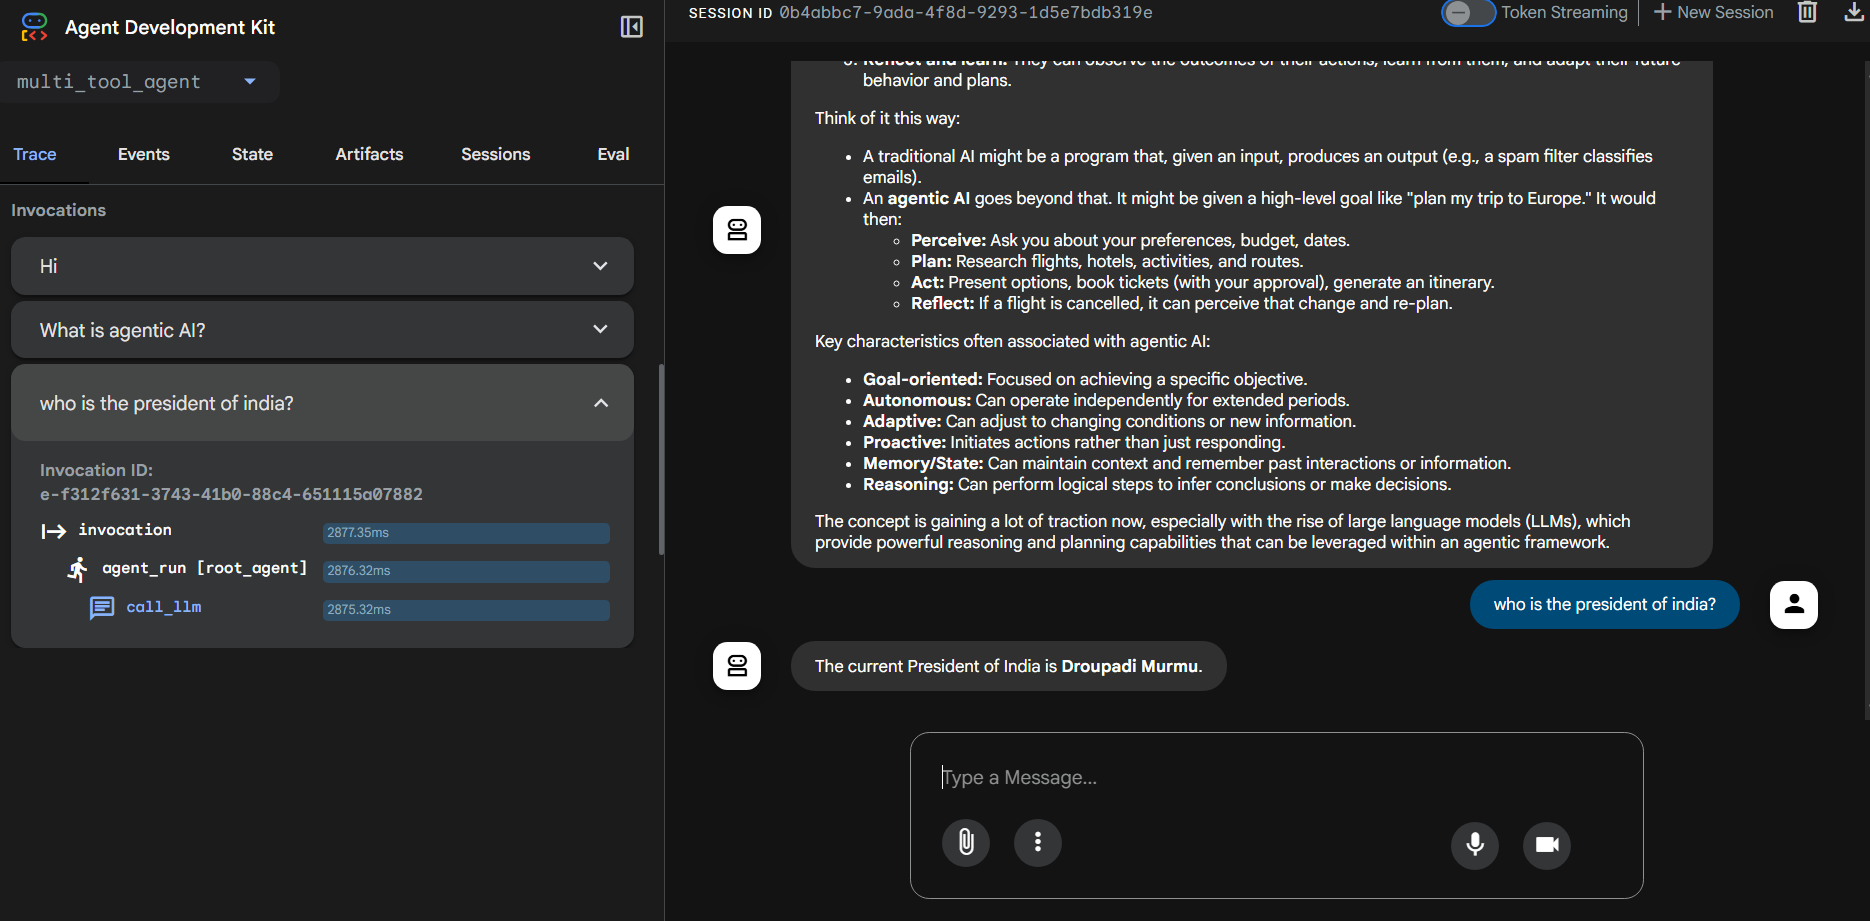 <br> 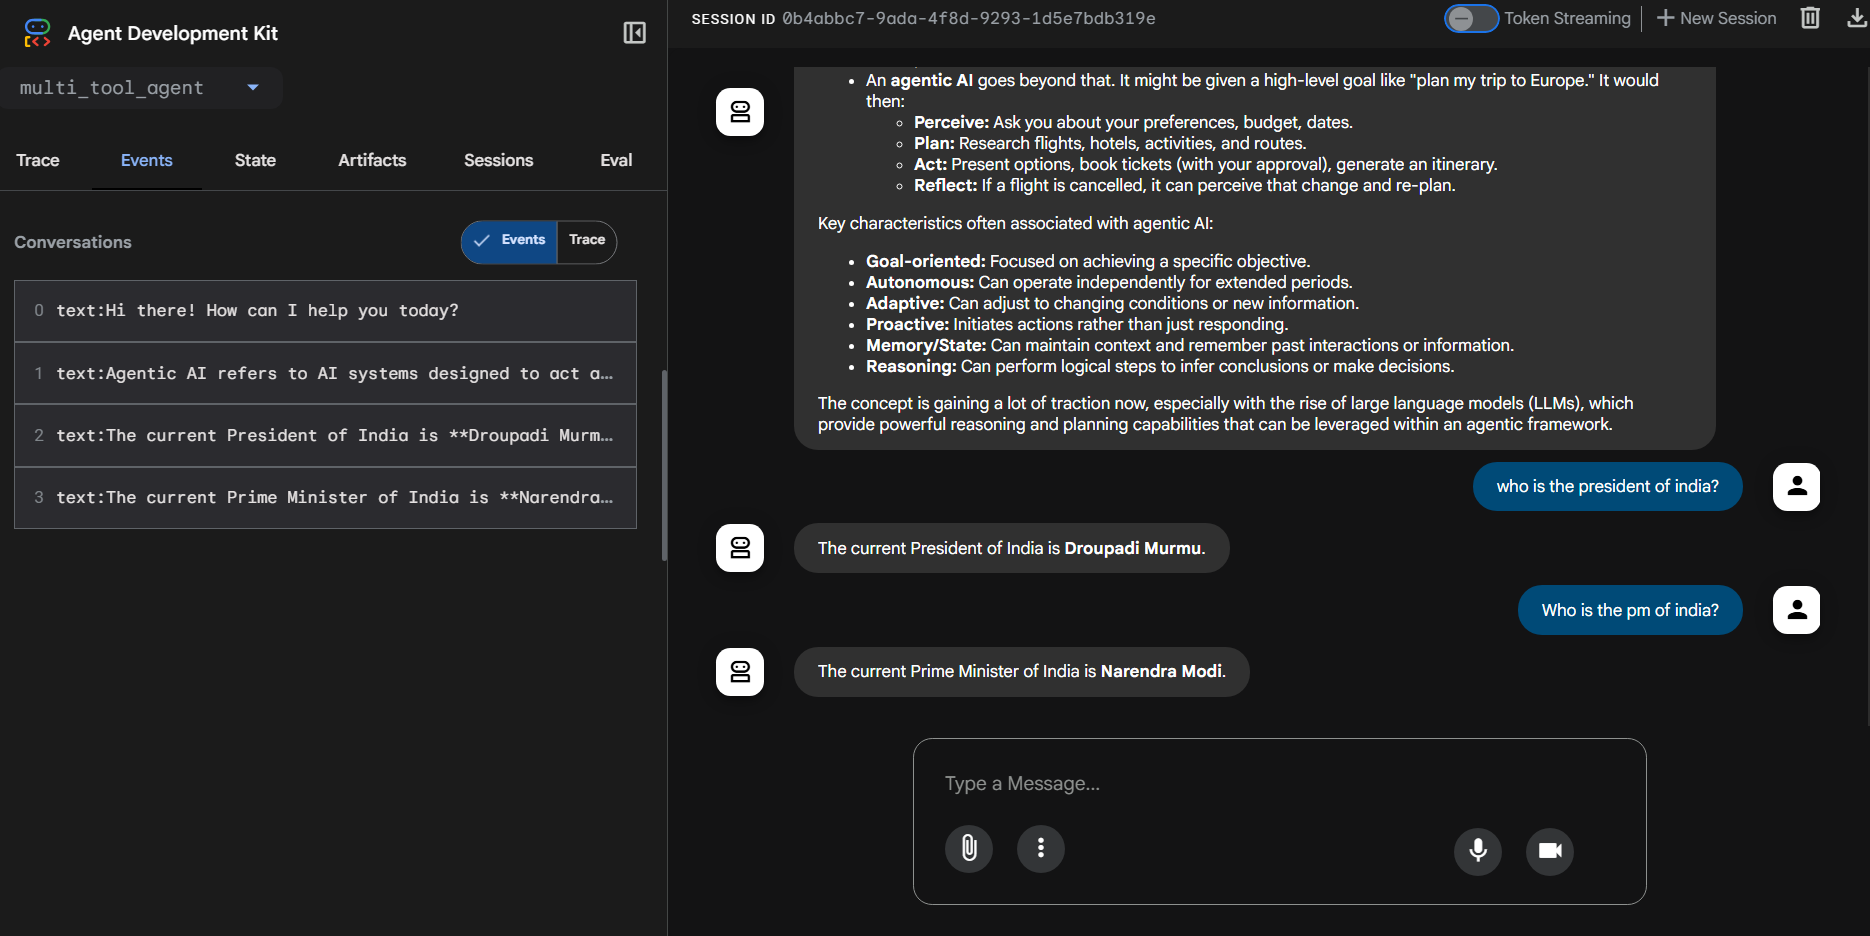 <br>

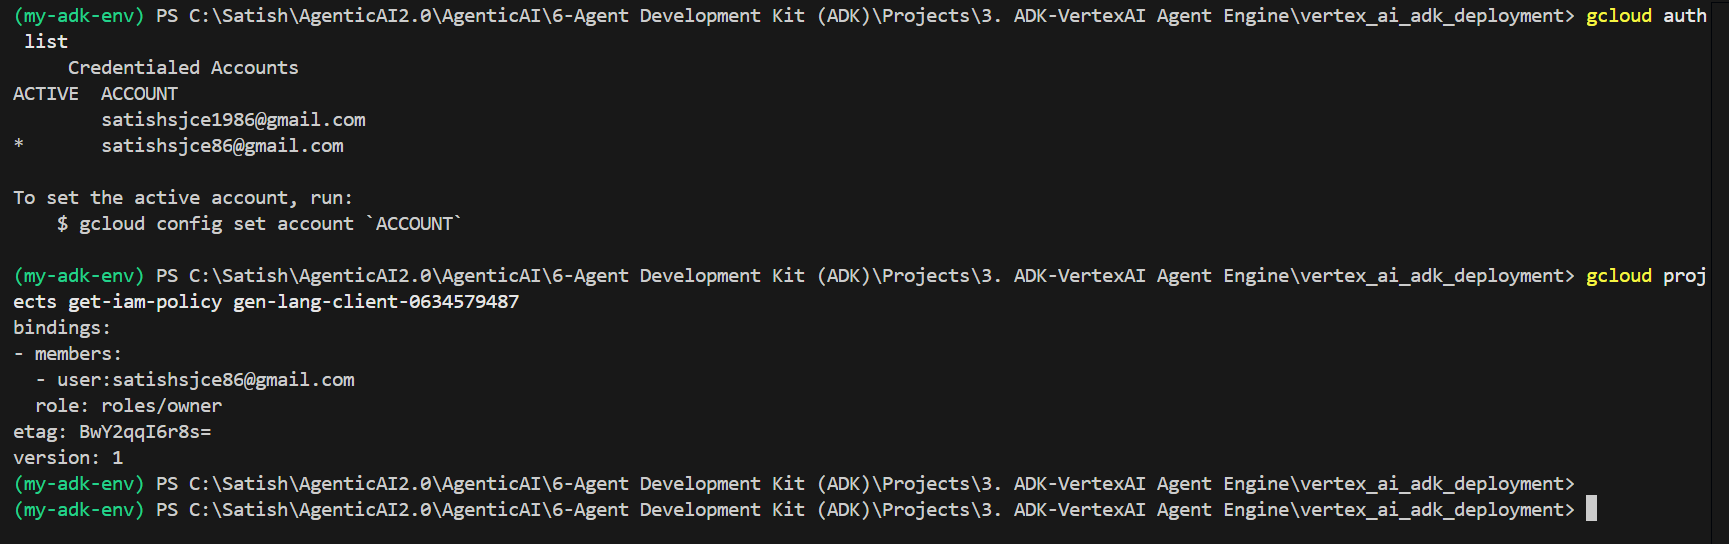

#### Run below bash command
```bash
# Check if uv is installed, otherwise install it
command -v uv >/dev/null 2>&1 || { echo "uv is not installed. Installing uv..."; curl -LsSf https://astral.sh/uv/0.6.12/install.sh | sh; source $HOME/.local/bin/env; }

# Sync dependencies (including dev deps)
uv sync --dev
```

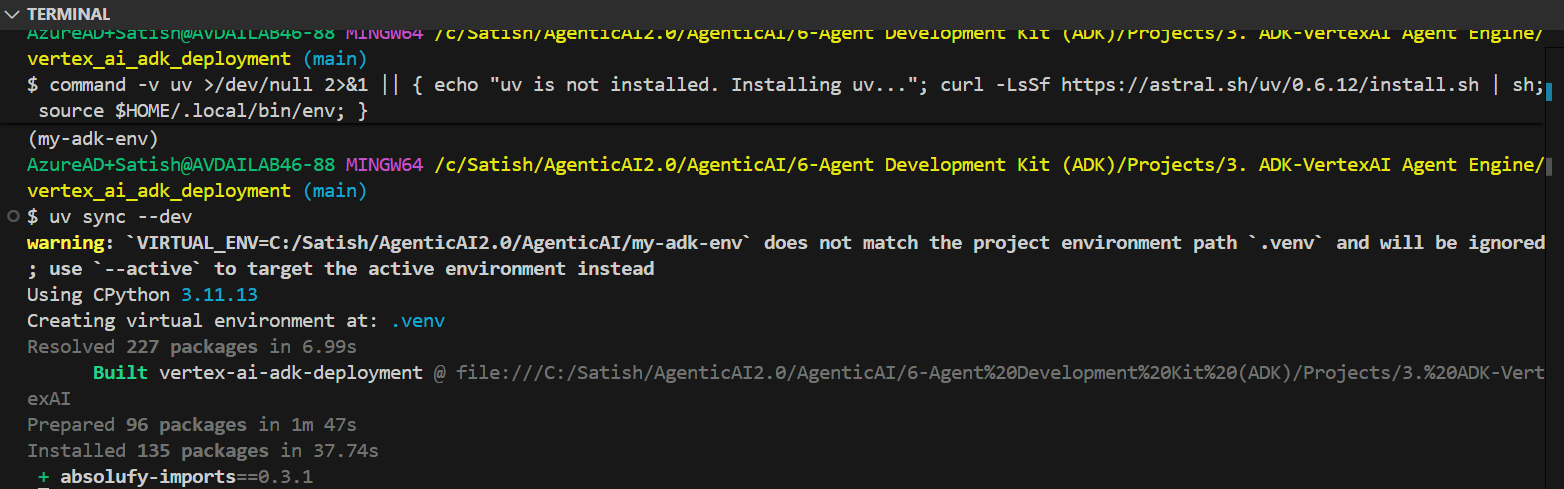 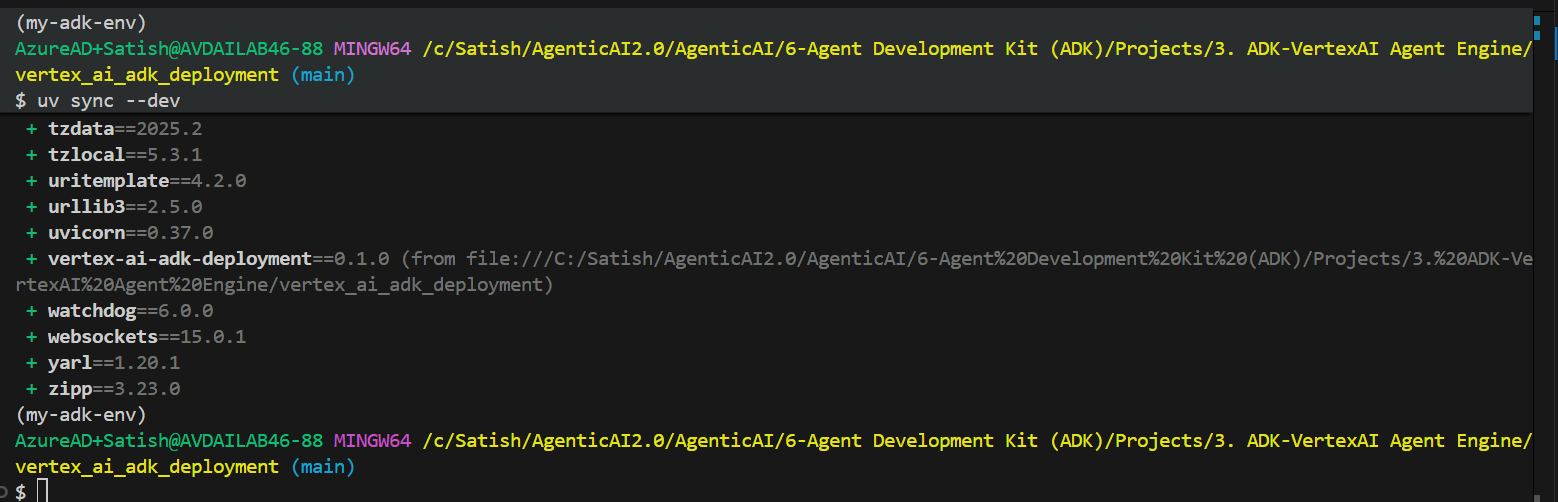

##### **Run**
```bash
uv run adk web . --port 8501 --reload_agents
```

### Deploy your ADK project
When using the ASP tool, you deploy in stages. In the first stage, you run a `make` command that provisions the services needed to run your ADK workflow on Agent Engine. In the second stage, your project code is uploaded to the Agent Engine service and the agent project is executed.

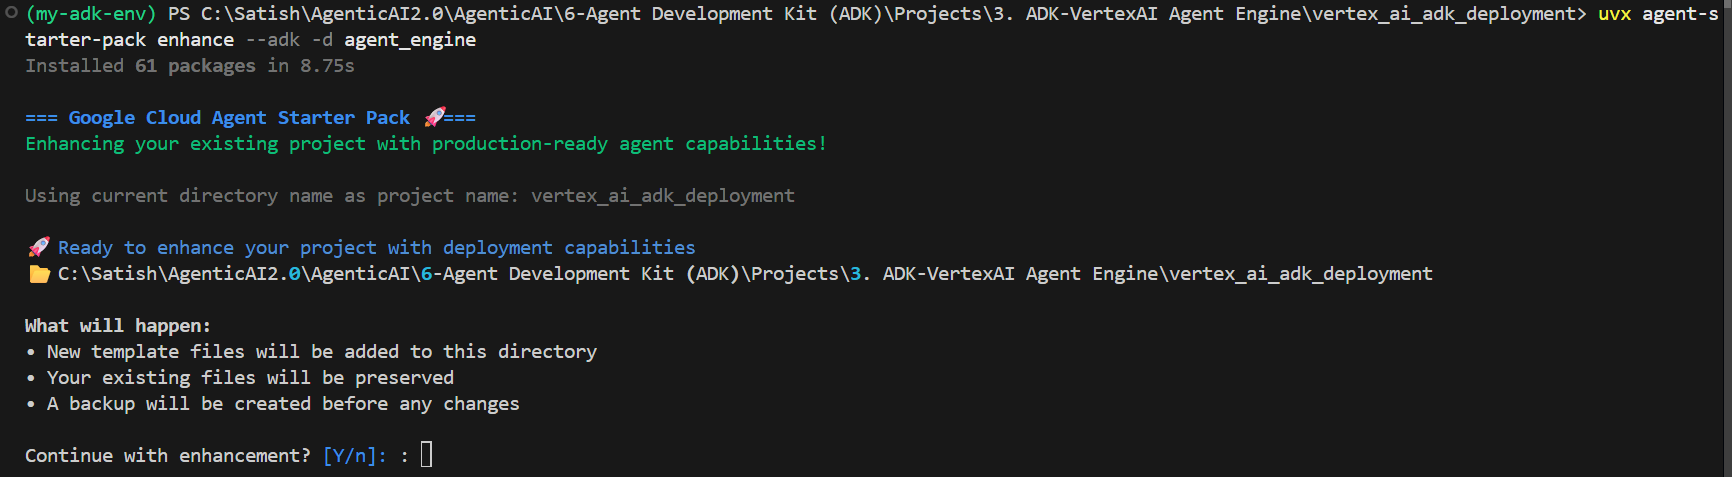

To deploy your ADK project to Agent Engine in your Google Cloud project:

1. In a terminal window of your development environment, navigate to the root directory of your project, for example: 
    ```bash
    cd multi_tool_agent/
    ```

1. Provision a development environment, including logging, services accounts, storage, and Vertex AI API by running the following ASP make command:
    ```bash
    make setup-dev-env
    ```
1. Deploy the code from the updated local project into the Google Cloud development environment, by running the following ASP make command:
    ```bash
    make backend
    ```

Once this process completes successfully, you should be able to interact with the agent running on Google Cloud Agent Engine. For details on testing the deployed agent, see the next section.

Once this process completes successfully, you should be able to interact with the agent running on Google Cloud Agent Engine. For details on testing the deployed agent, see [Test deployed agent](https://google.github.io/adk-docs/deploy/agent-engine/#test-deployment).

##### **Makefile**
```bash
# Install dependencies using uv package manager
install:
	@command -v uv >/dev/null 2>&1 || { echo "uv is not installed. Installing uv..."; curl -LsSf https://astral.sh/uv/0.6.12/install.sh | sh; source $HOME/.local/bin/env; }
	uv sync --dev
# Launch local dev playground
playground:
	@echo "==============================================================================="
	@echo "| 🚀 Starting your agent playground...                                        |"
	@echo "|                                                                             |"
	@echo "| 💡 Try asking: What's the weather in San Francisco?                         |"
	@echo "|                                                                             |"
	@echo "| 🔍 IMPORTANT: Select the 'multi_tool_agent' folder to interact with your agent.          |"
	@echo "==============================================================================="
	uv run adk web . --port 8501 --reload_agents

# Deploy the agent remotely
backend:
	# Export dependencies to requirements file using uv export.
	uv export --no-hashes --no-header --no-dev --no-emit-project --no-annotate > .requirements.txt 2>/dev/null || \
	uv export --no-hashes --no-header --no-dev --no-emit-project > .requirements.txt && uv run multi_tool_agent/agent_engine_app.py

# Set up development environment resources using Terraform
setup-dev-env:
	PROJECT_ID=$$(gcloud config get-value project) && \
	(cd deployment/terraform/dev && terraform init && terraform apply --var-file vars/env.tfvars --var dev_project_id=$$PROJECT_ID --auto-approve)

# Run unit and integration tests
test:
	uv run pytest tests/unit && uv run pytest tests/integration

# Run code quality checks (codespell, ruff, mypy)
lint:
	uv sync --dev --extra lint
	uv run codespell
	uv run ruff check . --diff
	uv run ruff format . --check --diff
	uv run mypy .
```
----

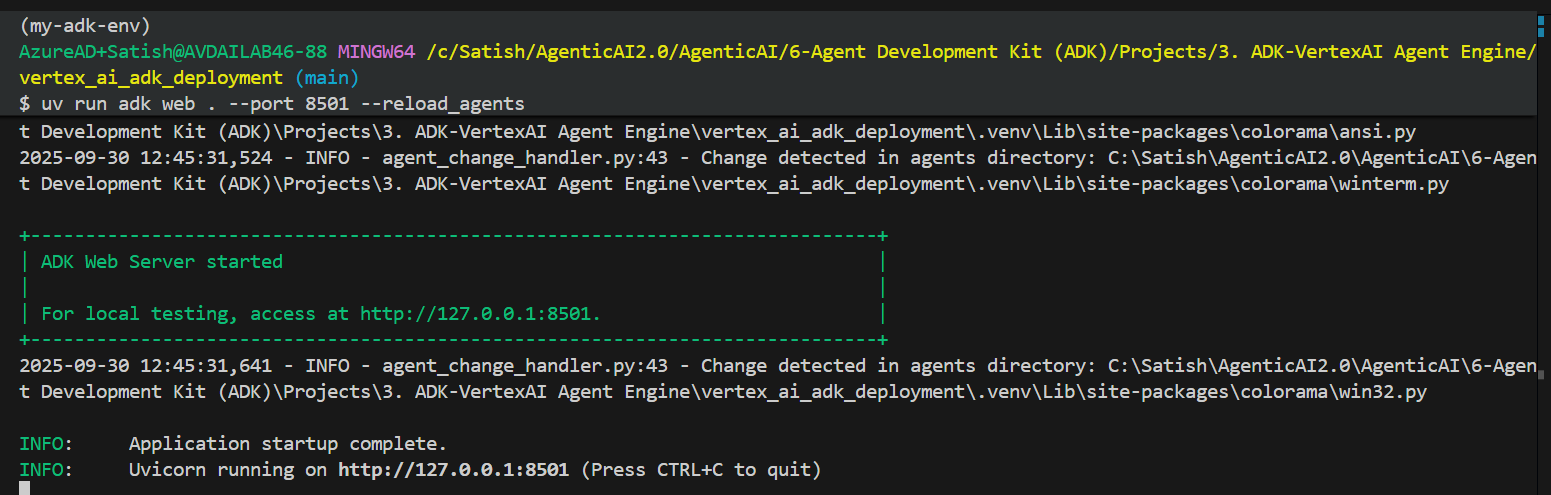 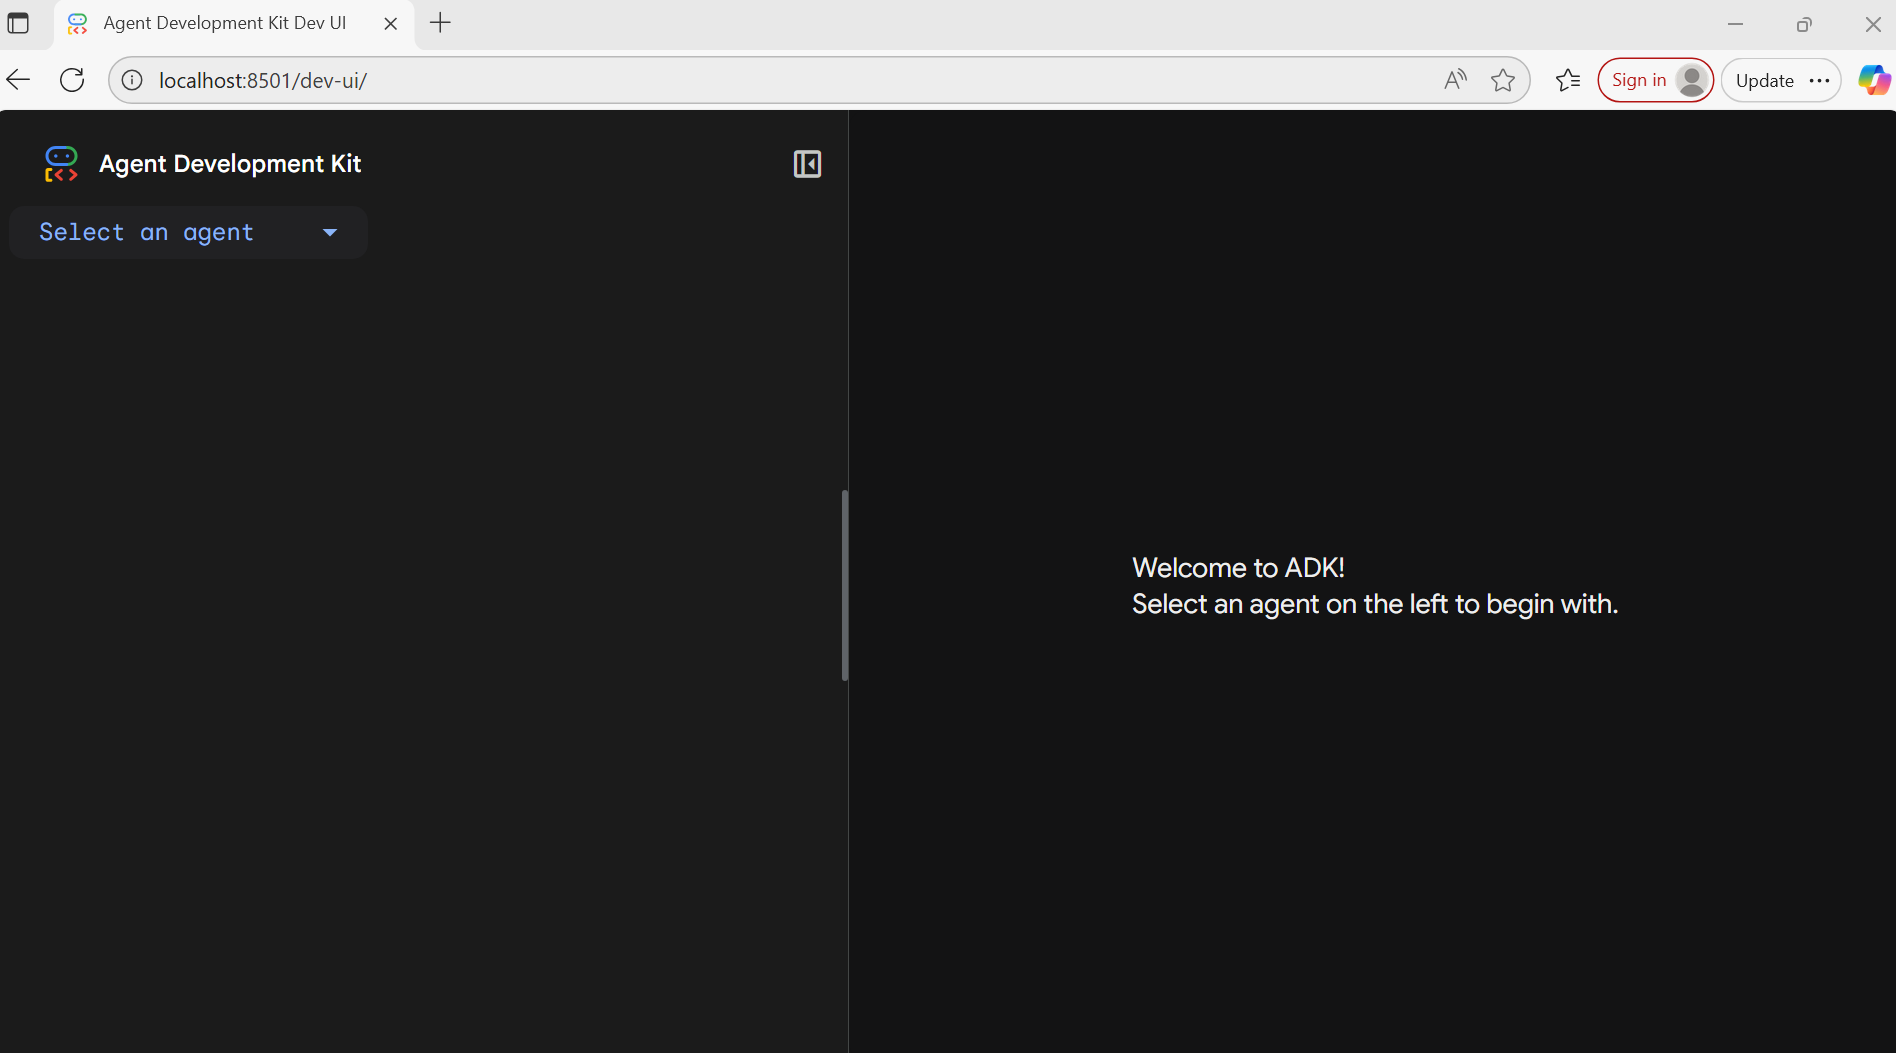 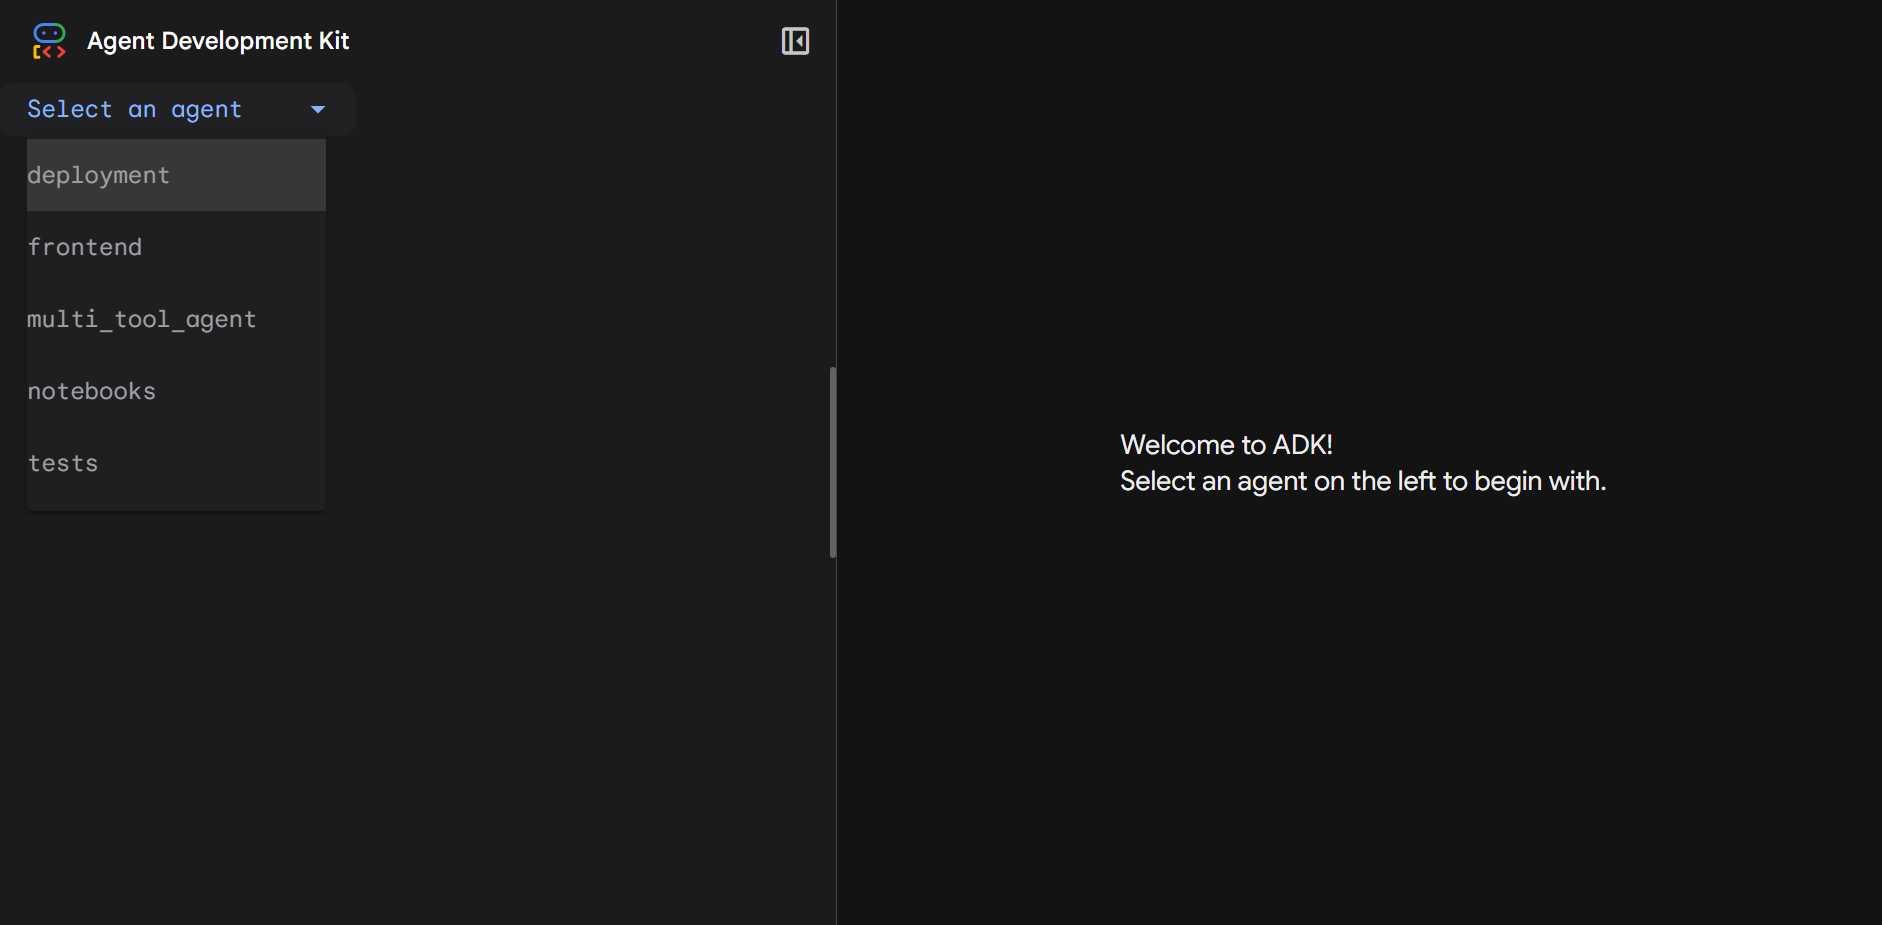 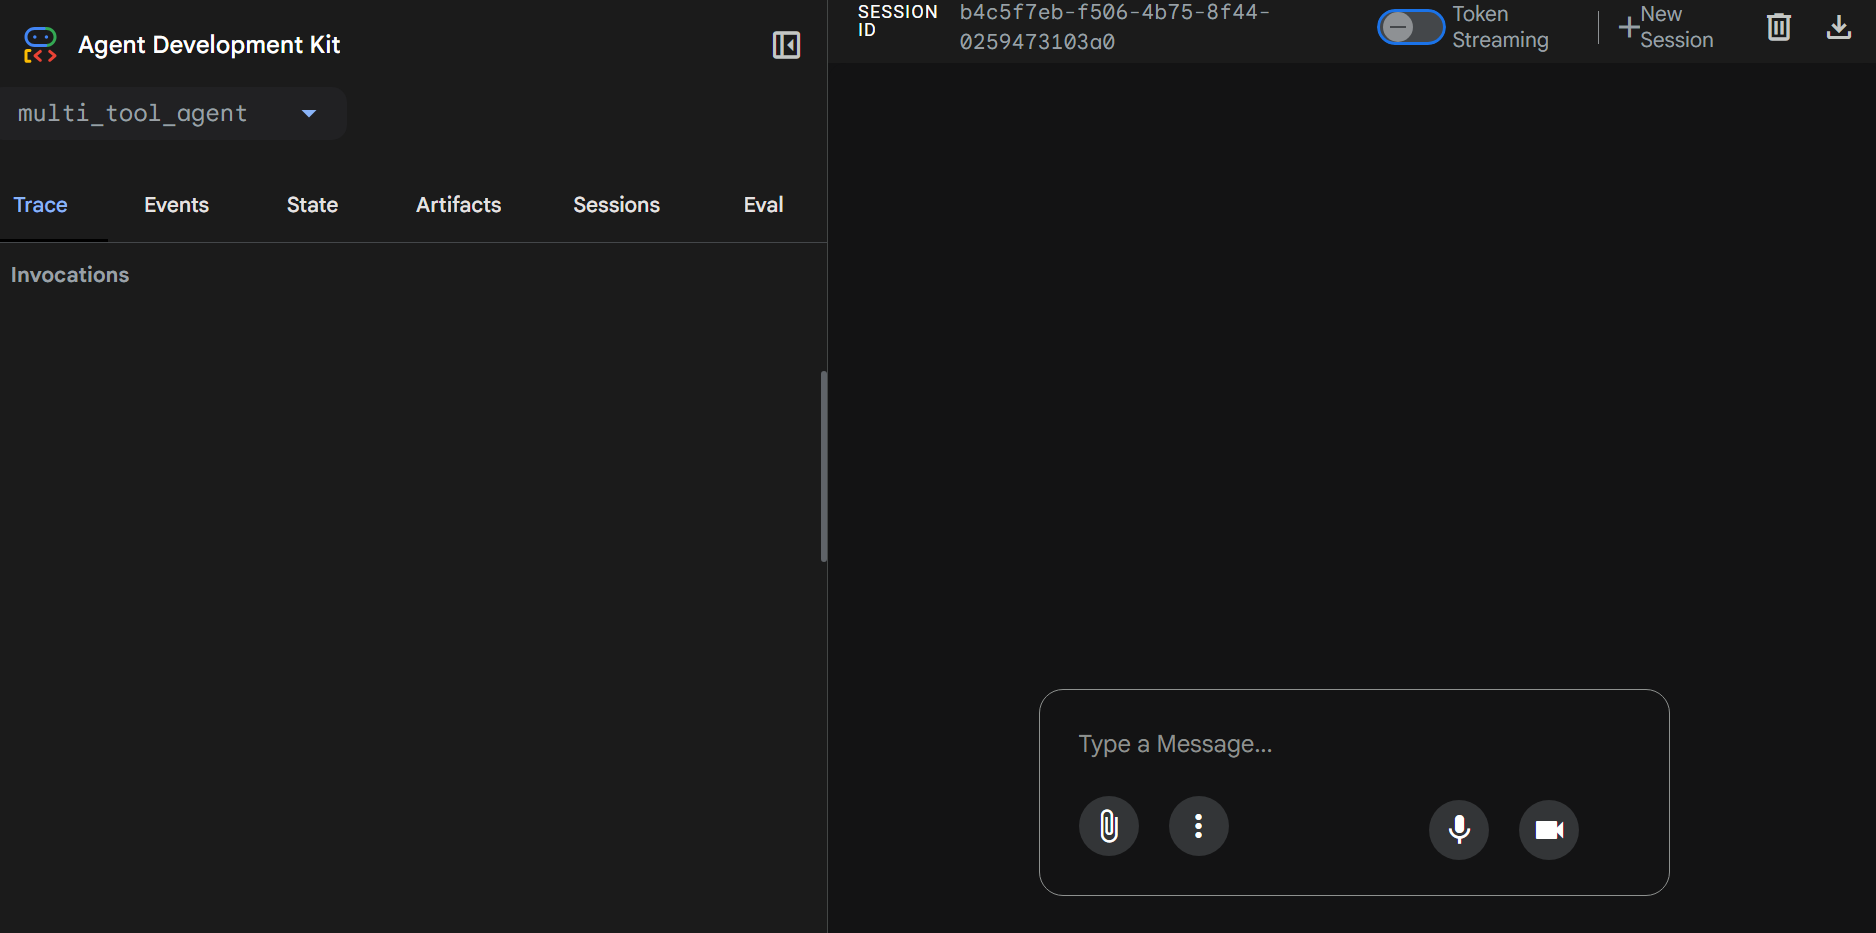 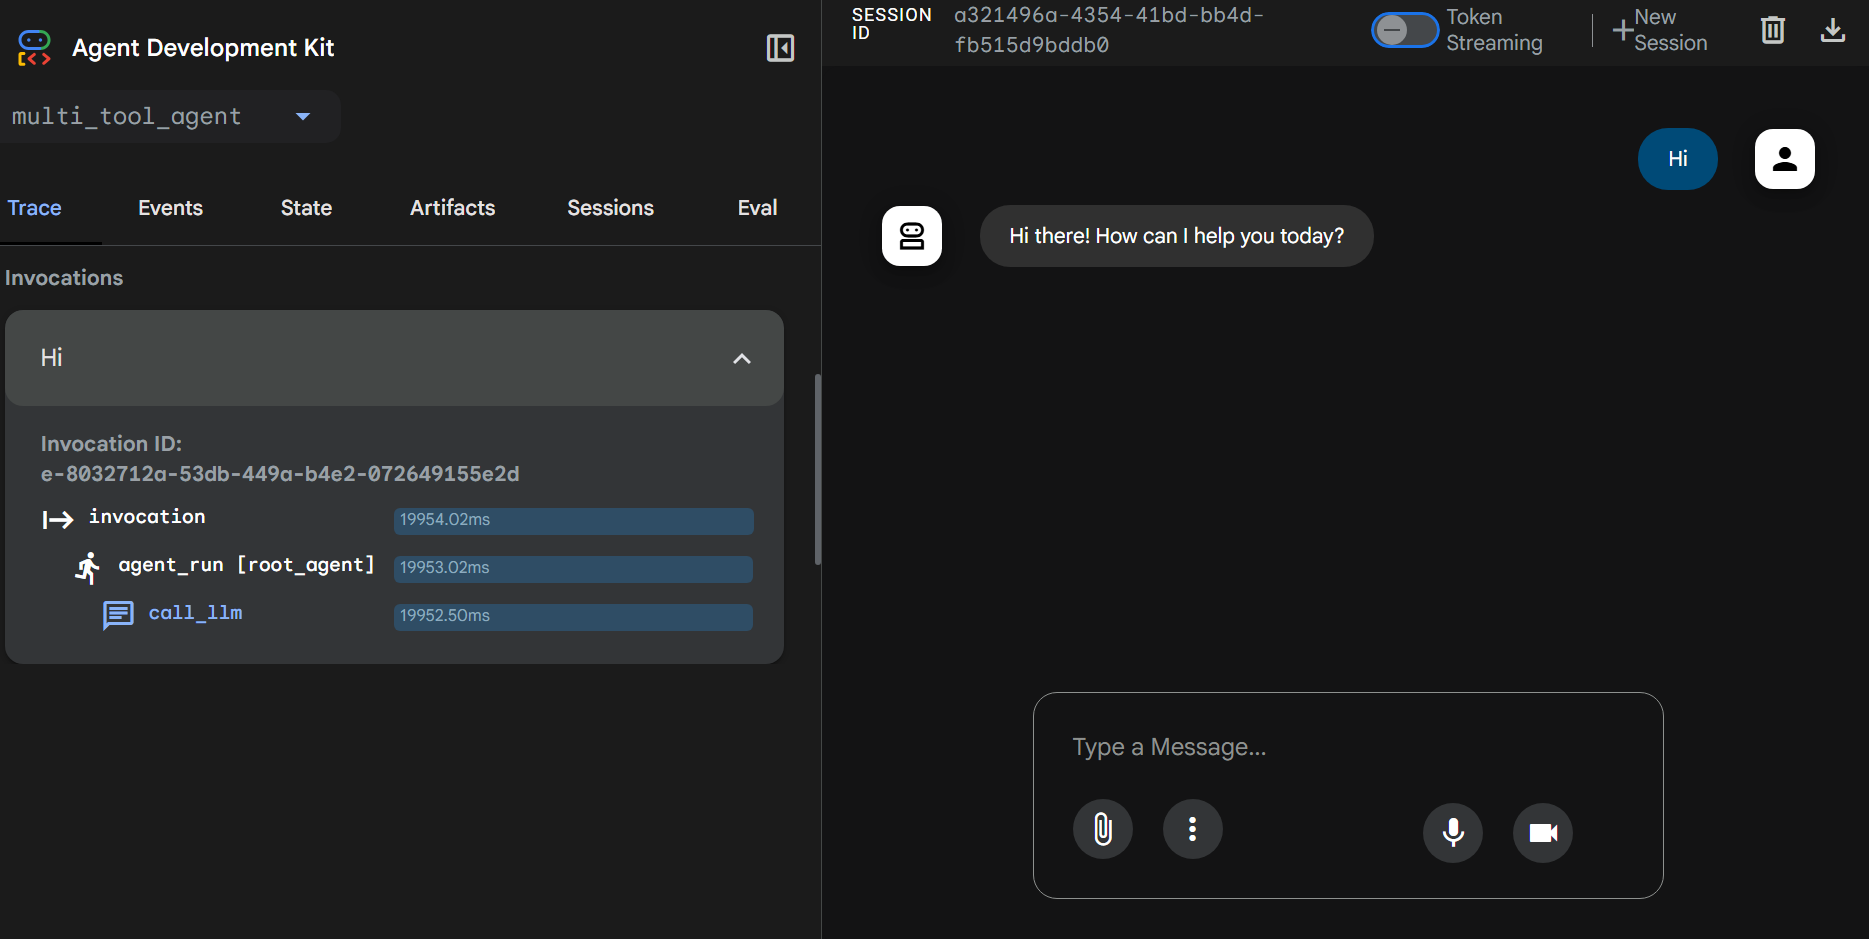 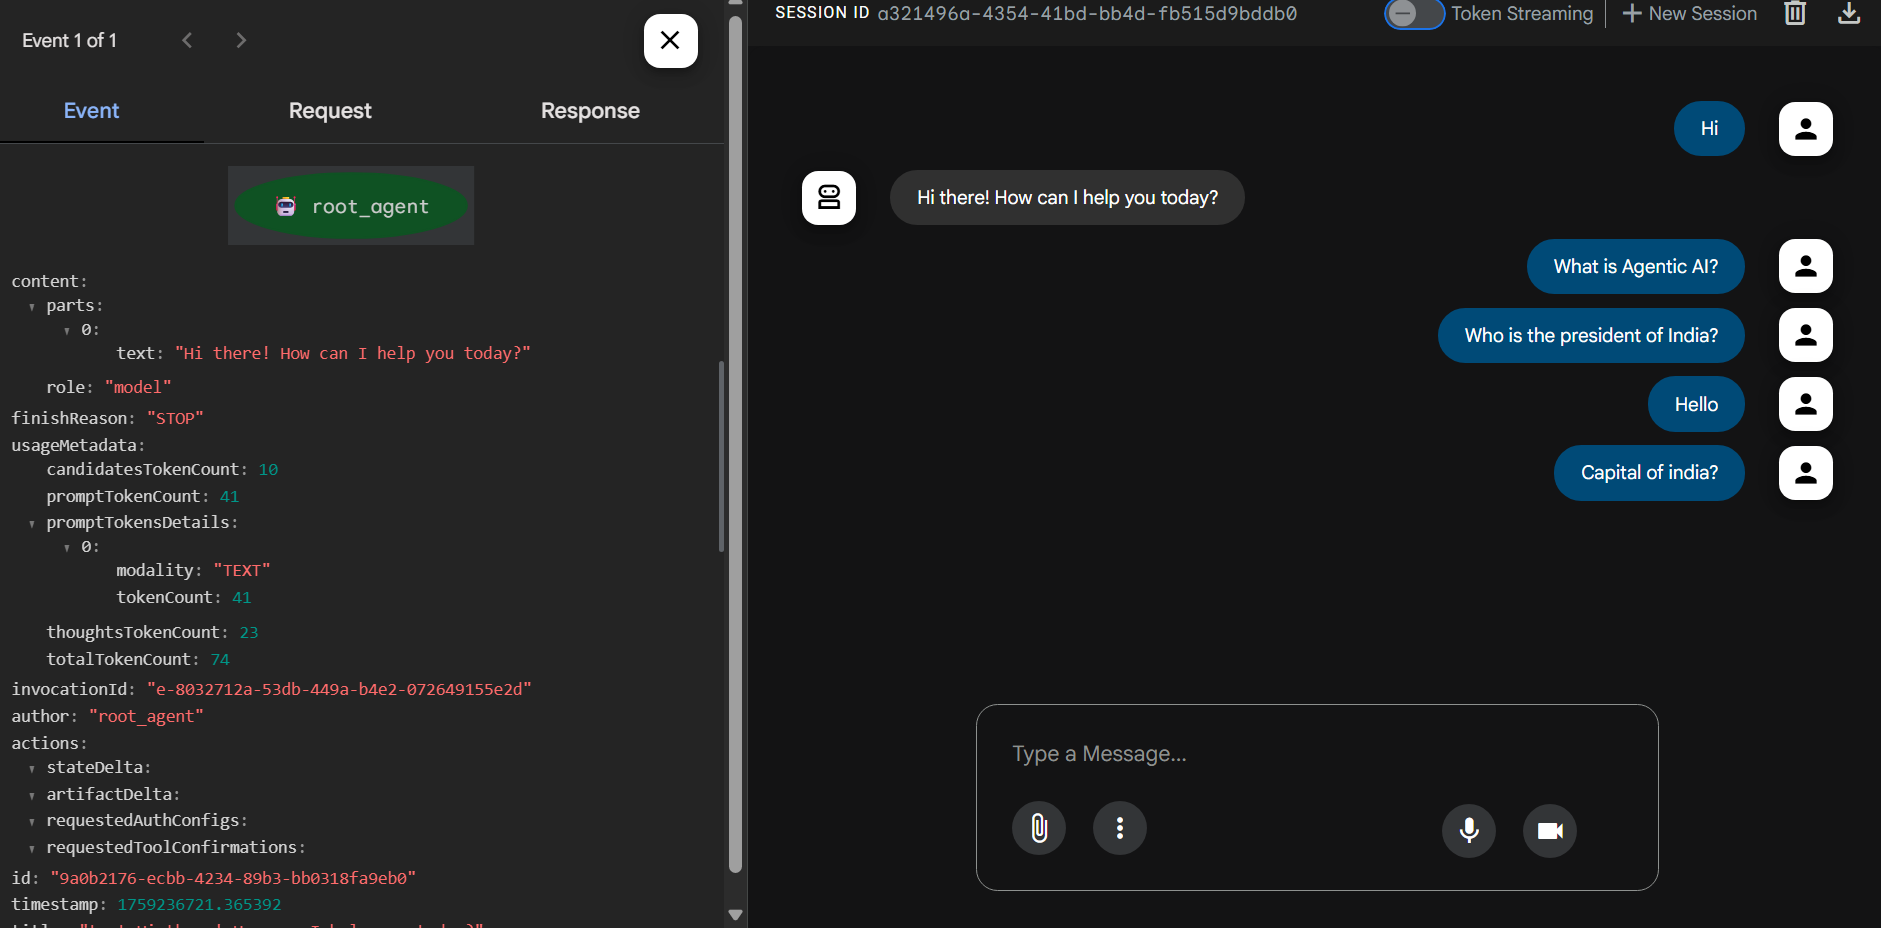 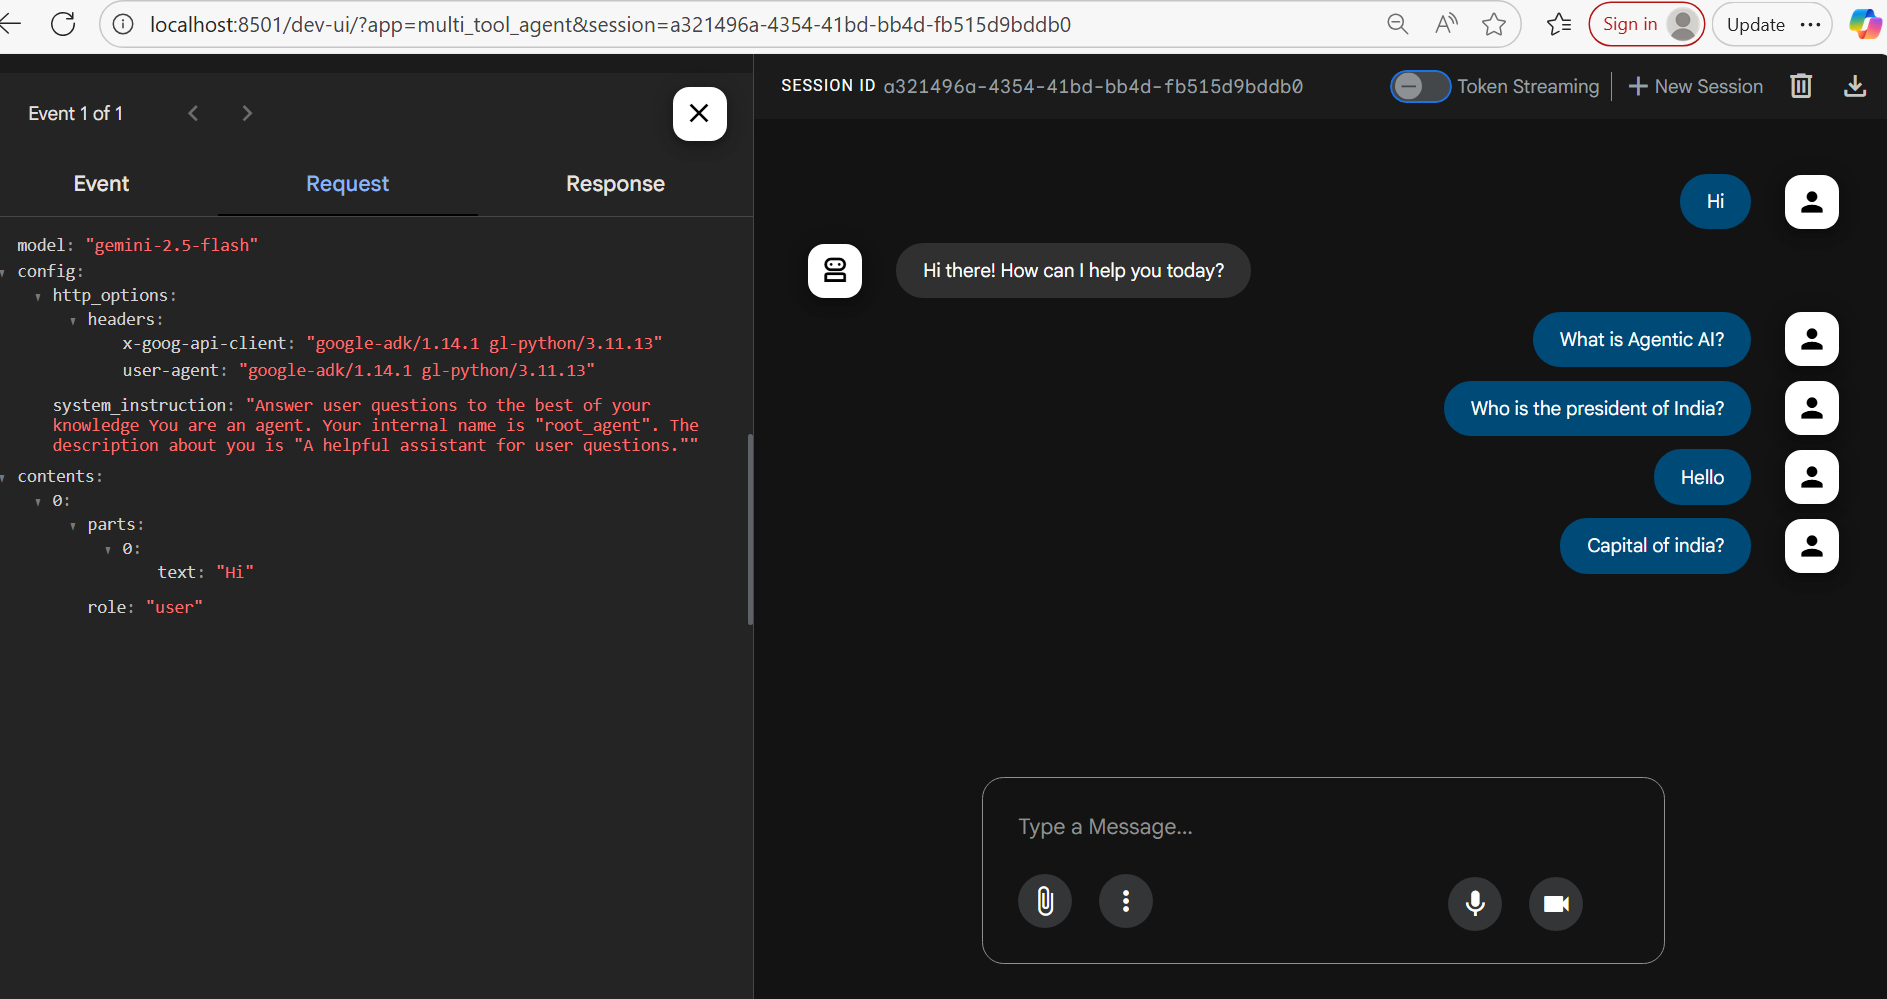 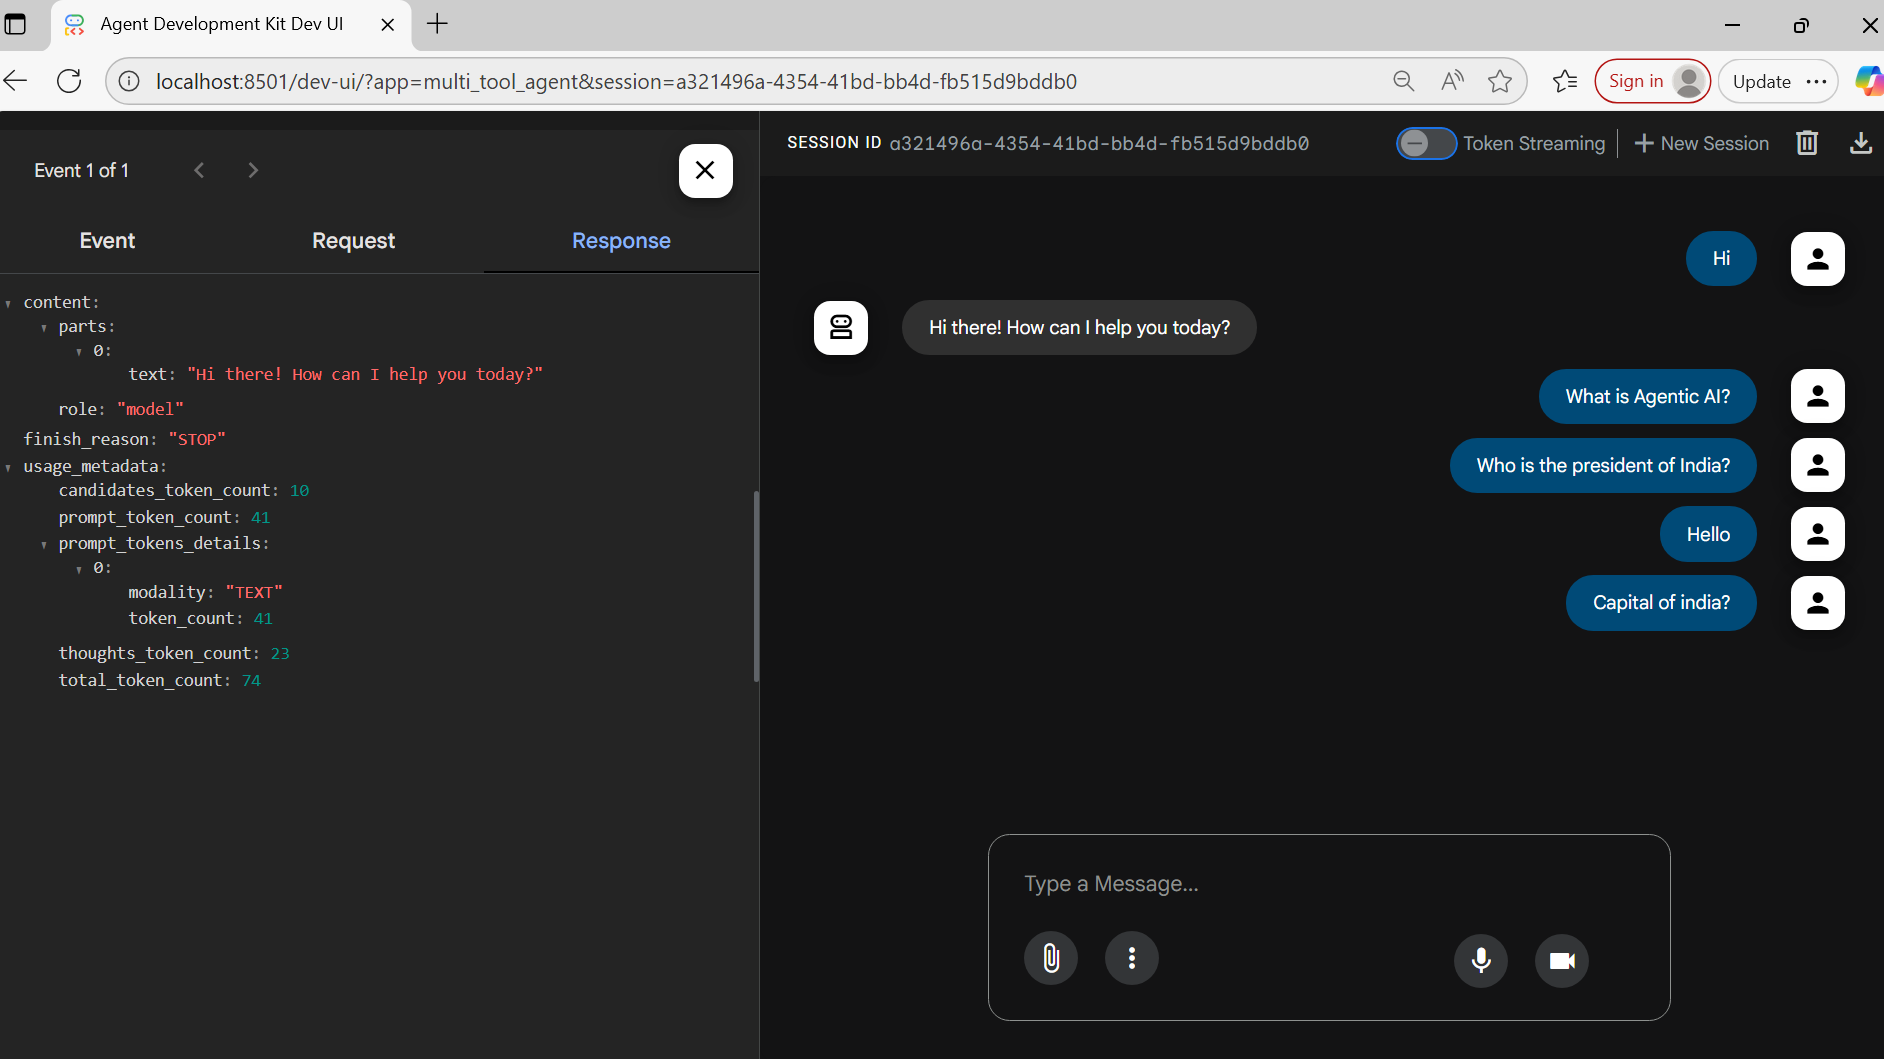 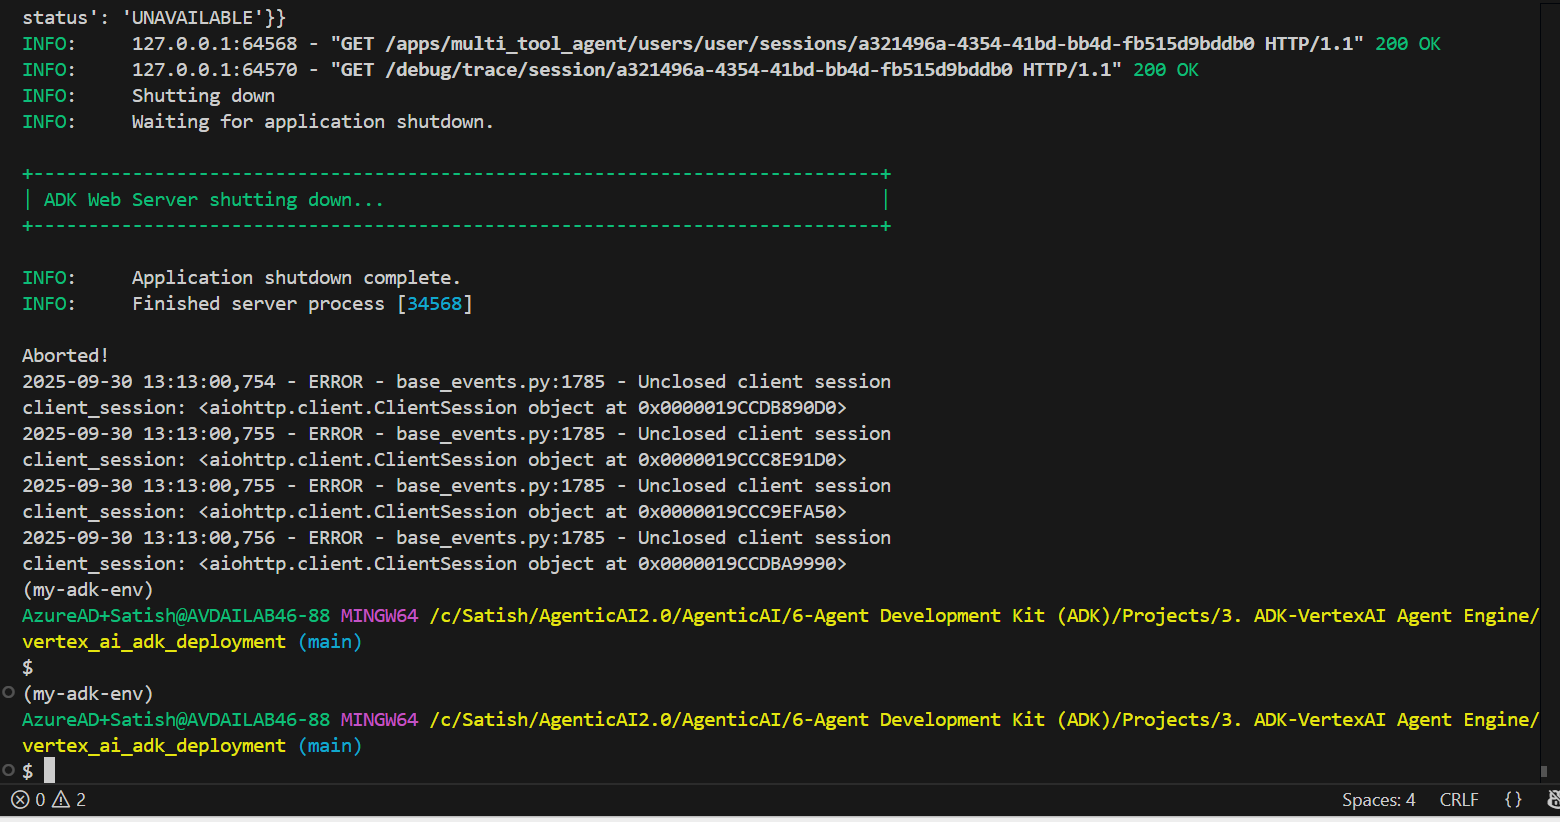

#### `Logs`
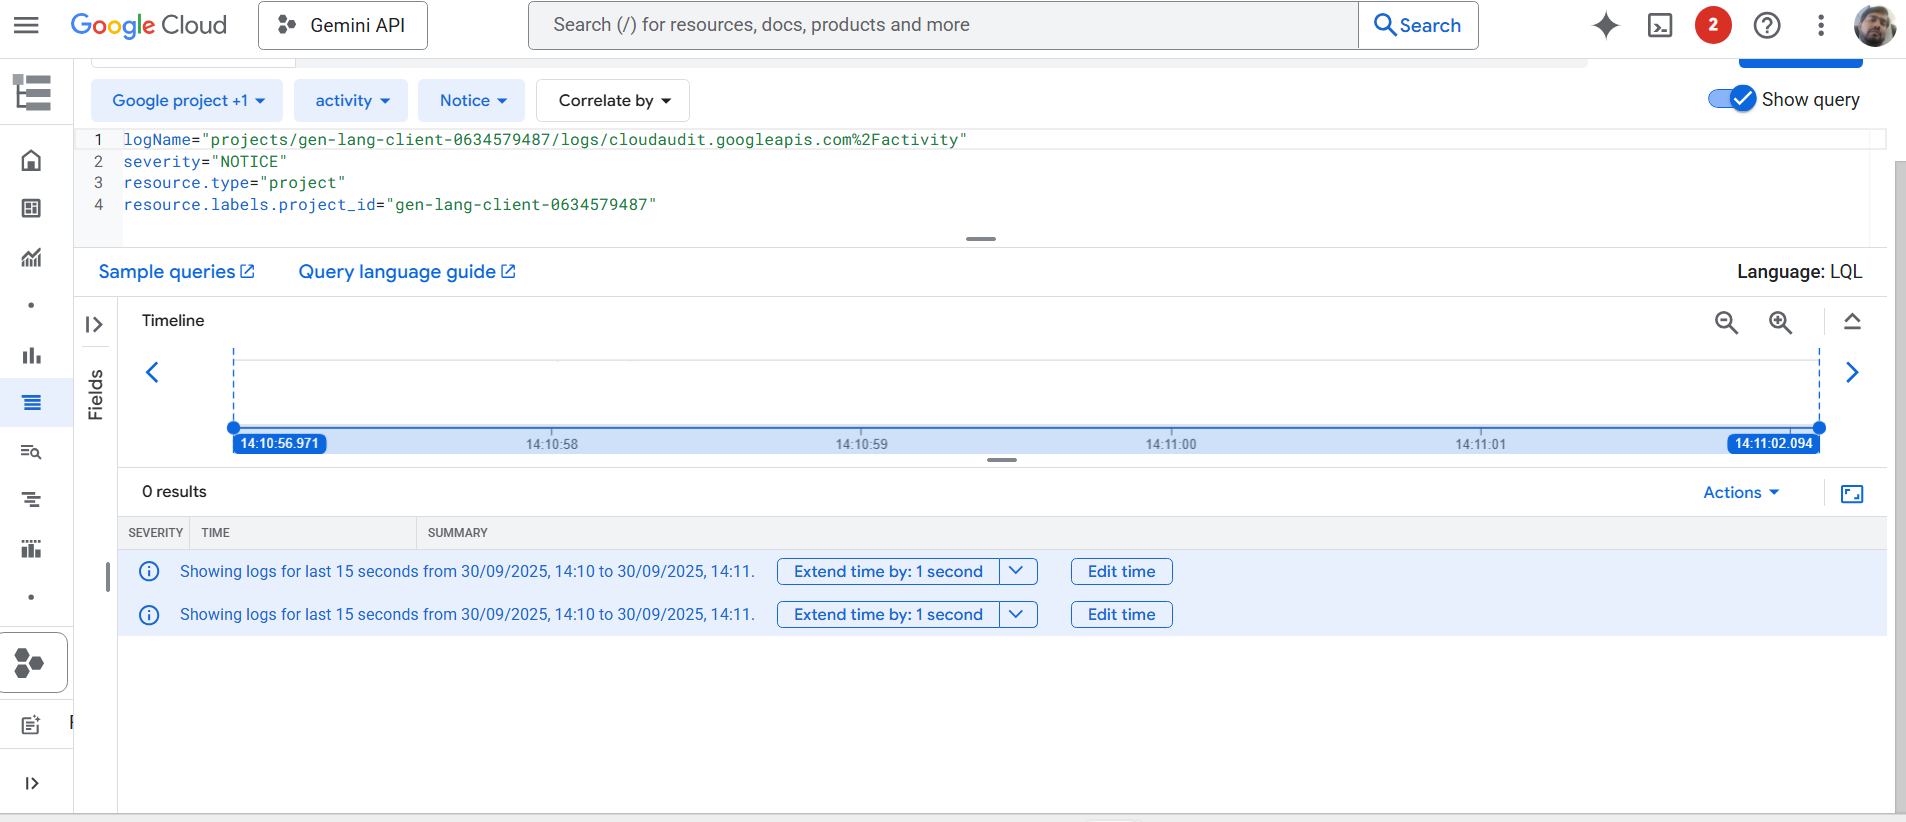 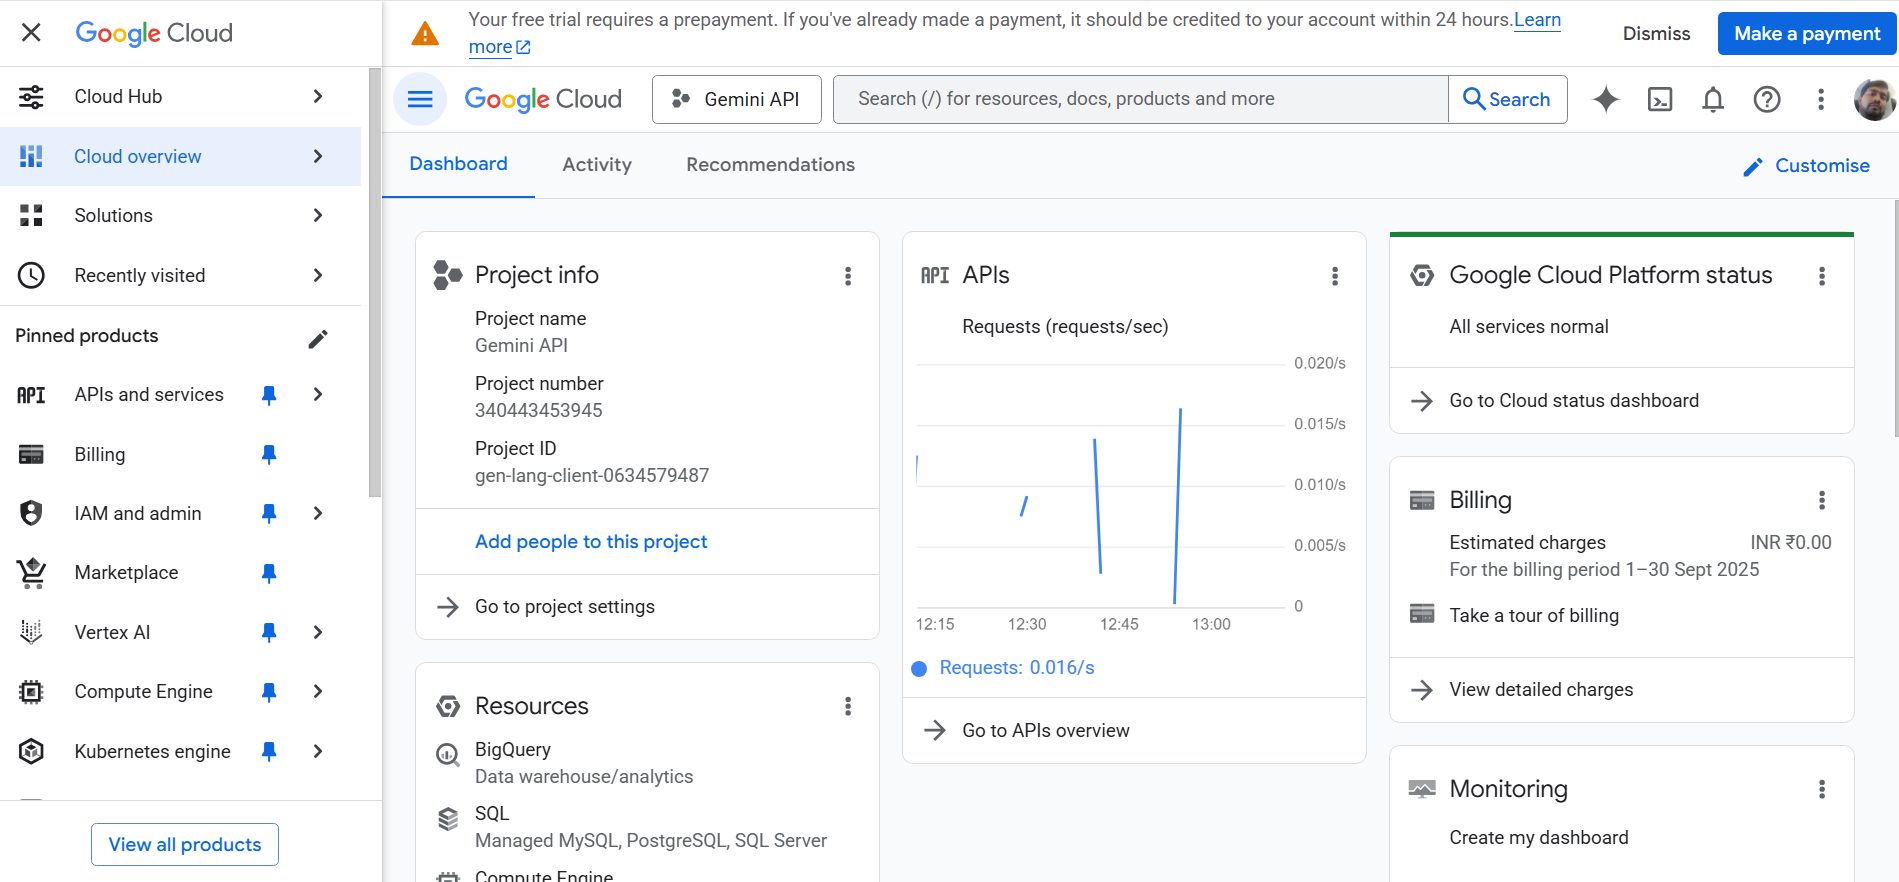

---

### Changes to your ADK project
The ASP tools add more files to your project for deployment. The procedure below backs up your existing project files before modifying them. This guide uses the [multi_tool_agent](https://github.com/google/adk-docs/tree/main/examples/python/snippets/get-started/multi_tool_agent) project as a reference example. The original project has the following file structure to start with:

```
multi_tool_agent/
├─ __init__.py
├─ agent.py
└─ .env
```

After running the ASP enhance command to add Agent Engine deployment information, the new structure is as follows:

```
multi-tool-agent/
├─ app/                 # Core application code
│   ├─ agent.py         # Main agent logic
│   ├─ agent_engine_app.py # Agent Engine application logic
│   └─ utils/           # Utility functions and helpers
├─ .cloudbuild/         # CI/CD pipeline configurations for Google Cloud Build
├─ deployment/          # Infrastructure and deployment scripts
├─ notebooks/           # Jupyter notebooks for prototyping and evaluation
├─ tests/               # Unit, integration, and load tests
├─ Makefile             # Makefile for common commands
├─ GEMINI.md            # AI-assisted development guide
└─ pyproject.toml       # Project dependencies and configuration
```

> See the README.md file in your updated ADK project folder for more information. For more information on using Agent Starter Pack, see the [Development guide](https://googlecloudplatform.github.io/agent-starter-pack/guide/development-guide.html).


----

### Standard deployment
This section describes how to perform a deployment to Agent Engine step-by-step. These instructions are more appropriate if you want to carefully manage your deployment settings, or are modifying an existing deployment with Agent Engine.

#### `standard_agent_engine_deployment`
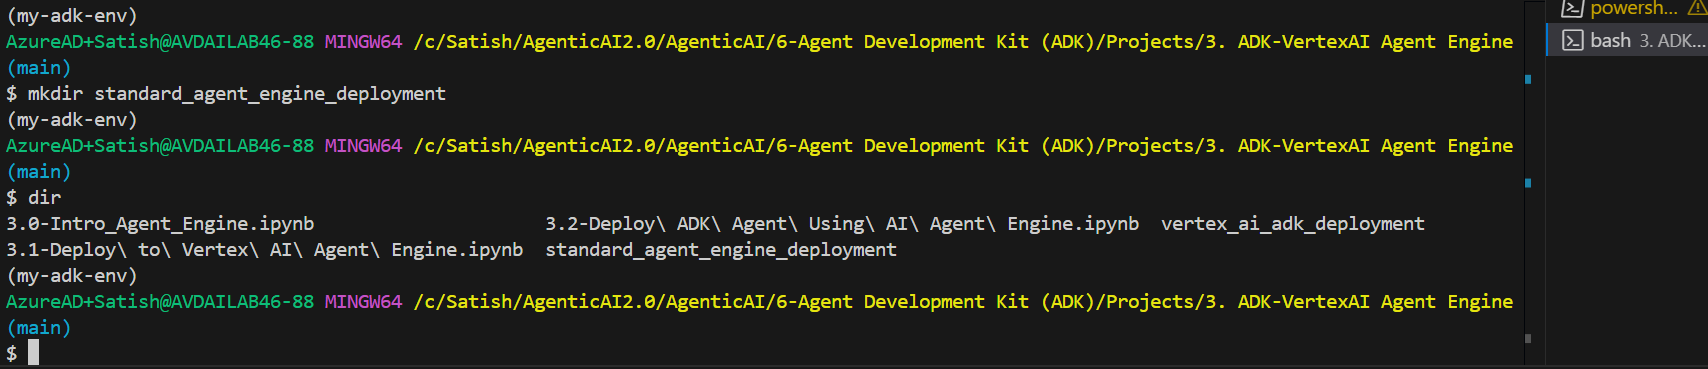

#### `multi_tool_agent`
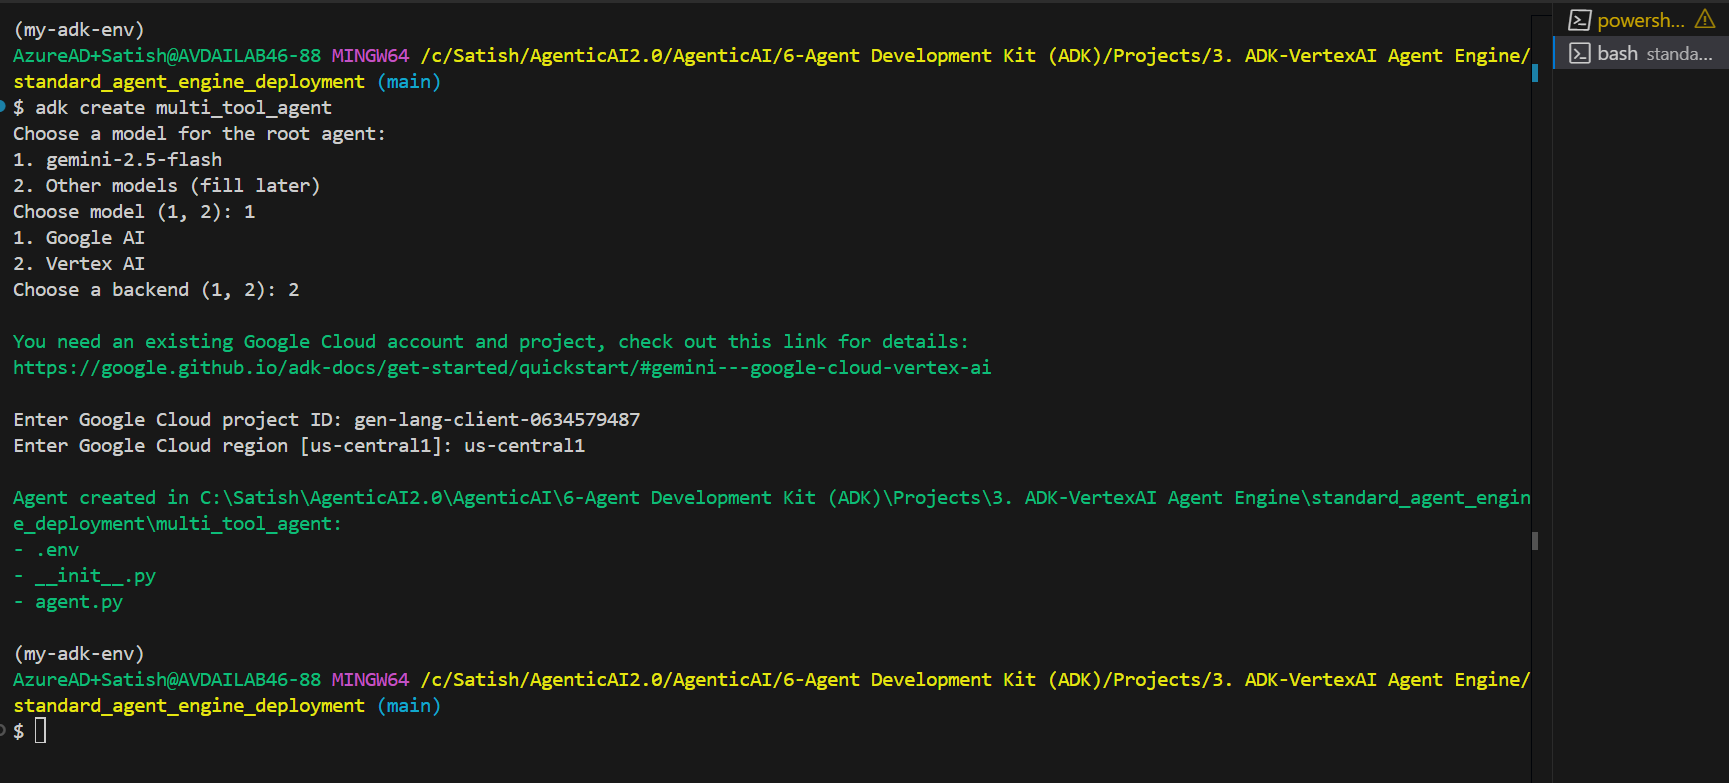 <br> 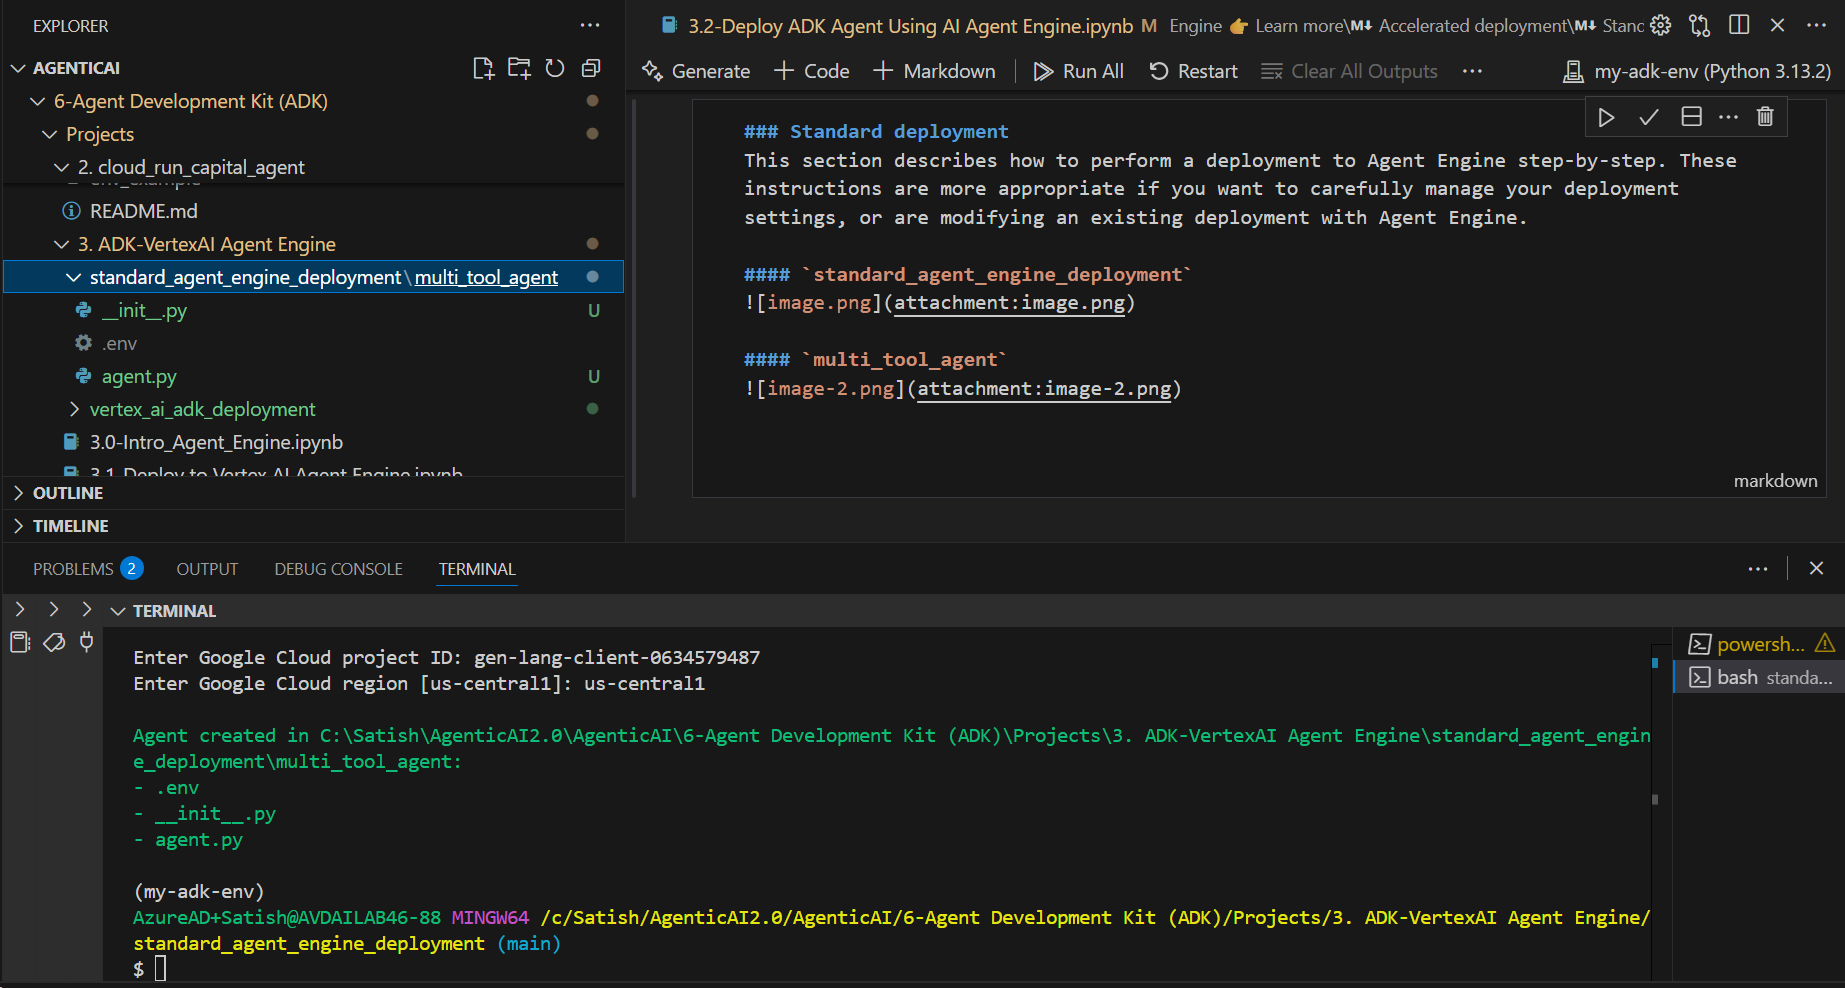

##### **.env**
```bash
GOOGLE_GENAI_USE_VERTEXAI=1
GOOGLE_CLOUD_PROJECT=gen-lang-client-0634579487
GOOGLE_CLOUD_LOCATION=us-central1
```

#### Define your agent
These instructions assume you have an existing ADK project that you are modifying for deployment. If you do not have an ADK project, or want to use a test project, complete the Python [Quickstart](https://google.github.io/adk-docs/get-started/quickstart/) guide, which creates a [multi_tool_agent](https://github.com/google/adk-docs/tree/main/examples/python/snippets/get-started/multi_tool_agent) project. The following instructions use the `multi_tool_agent` project as an example.

##### Initialize Vertex AI
Next, initialize the Vertex AI SDK. This tells the SDK which Google Cloud project and region to use, and where to stage files for deployment.

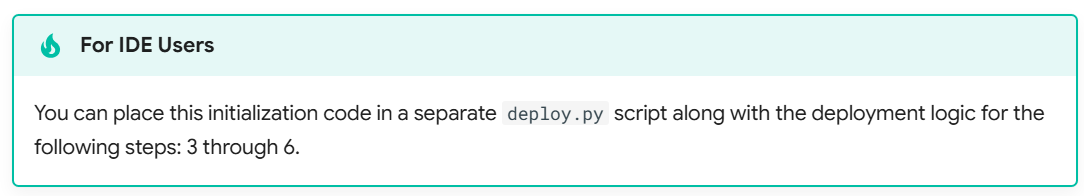

##### **deploy.py**
```python
import vertexai
from agent import root_agent # modify this if your agent is not in agent.py

# TODO: Fill in these values for your project
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-central1"  # For other options, see https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions
STAGING_BUCKET = "gs://your-gcs-bucket-name"

# Initialize the Vertex AI SDK
vertexai.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)
```
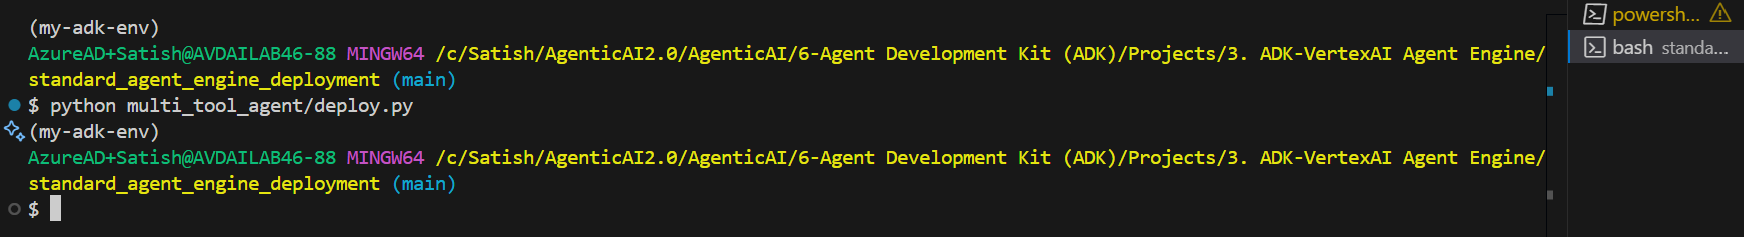

##### **Google Cloud -> Buckets**
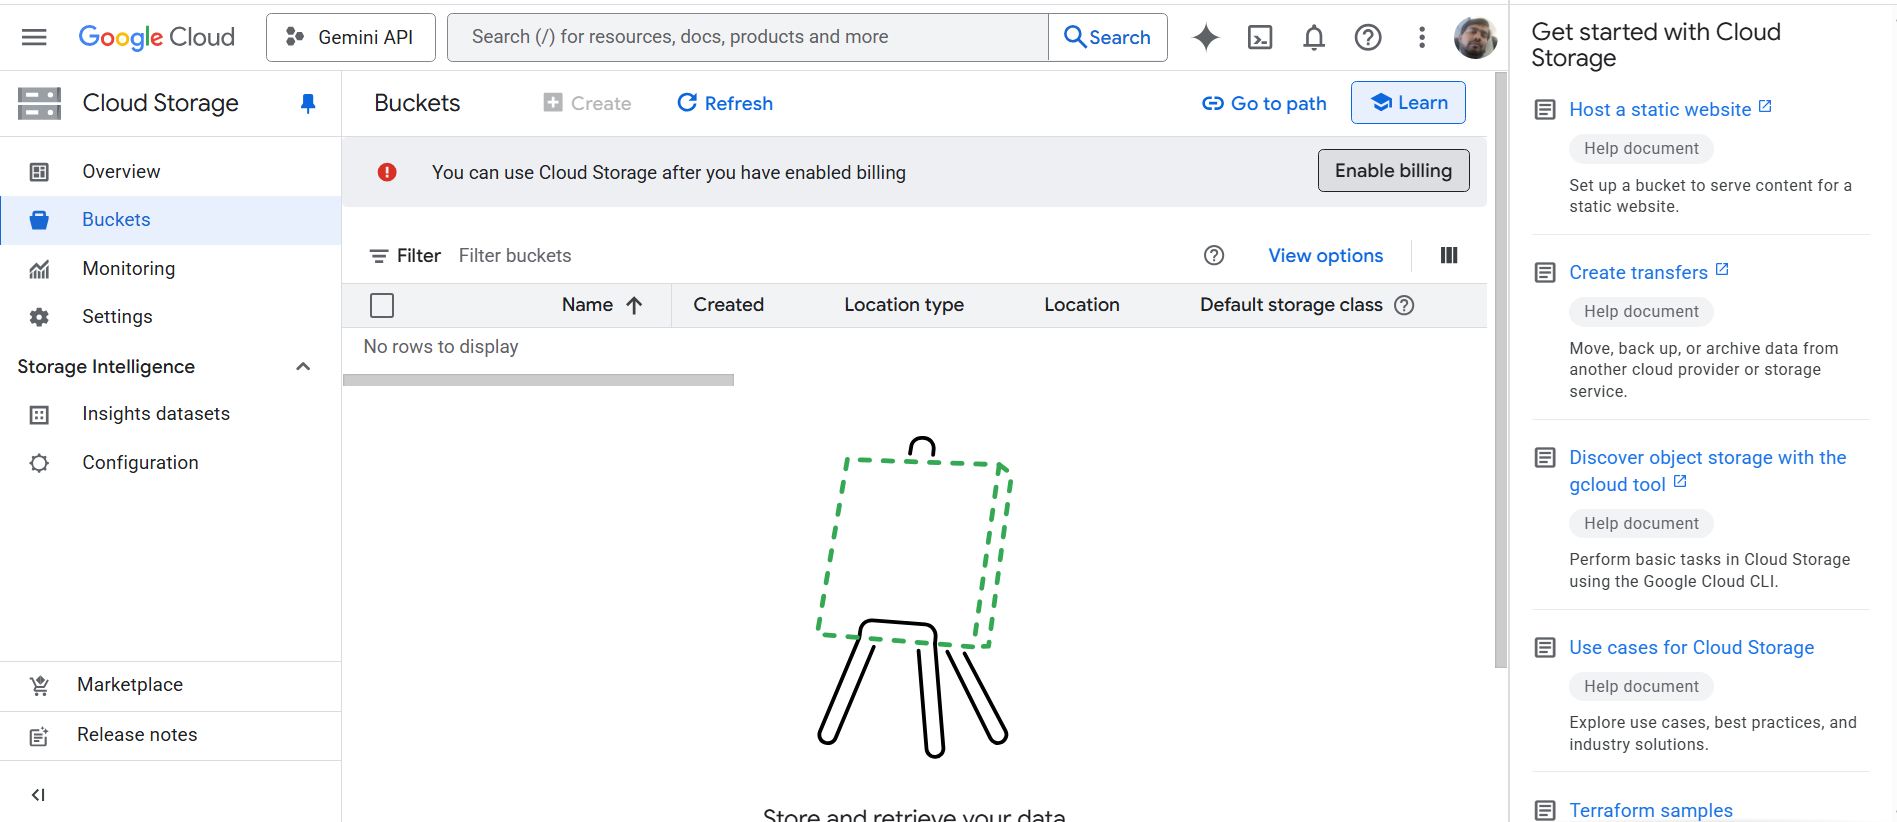

#### Prepare the agent for deployment
To make your agent compatible with Agent Engine, you need to wrap it in an `AdkApp` object.

##### **deploy.py**
```Python
from vertexai import agent_engines

# Wrap the agent in an AdkApp object
app = agent_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
)
```

```Python
import vertexai
from agent import root_agent # modify this if your agent is not in agent.py

# TODO: Fill in these values for your project
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-central1"  # For other options, see https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions
STAGING_BUCKET = "gs://your-gcs-bucket-name"

# Initialize the Vertex AI SDK
vertexai.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)

from vertexai import agent_engines

# Wrap the agent in an AdkApp object
app = agent_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
)
```

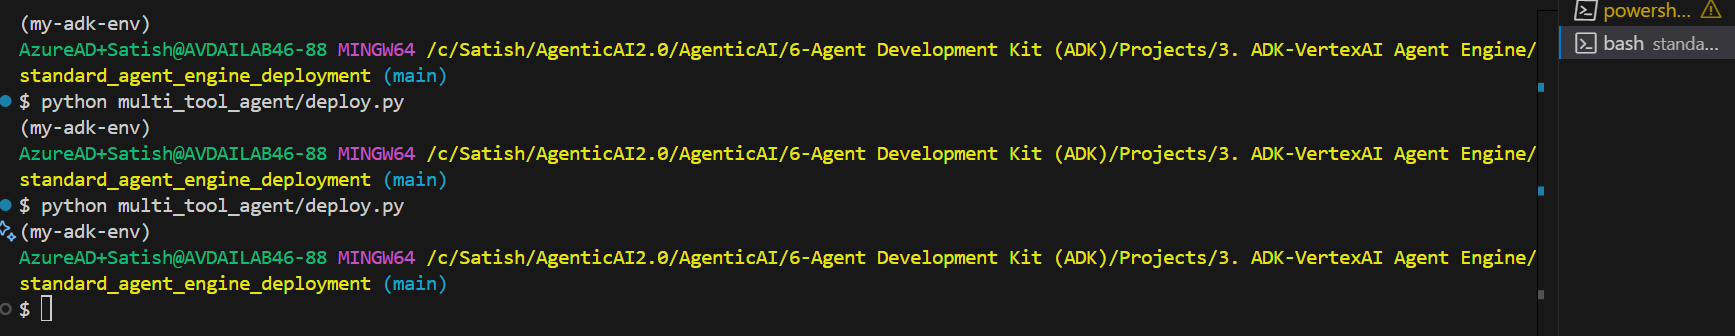 <br> 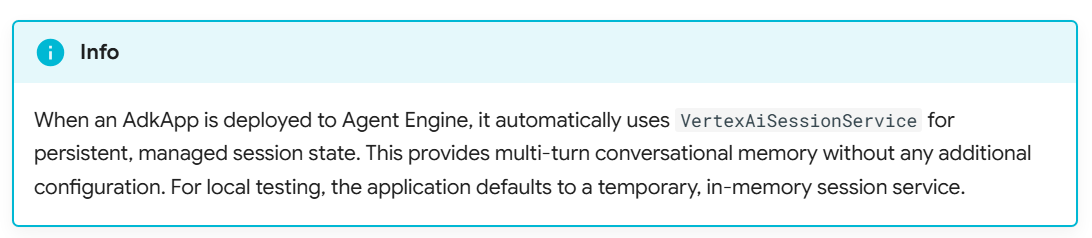

#### Test agent locally (optional)
Before deploying, you can test your agent's behavior locally. <br>

The `async_stream_query` method returns a stream of events that represent the agent's execution trace.

##### **deploy.py**
```python
# Create a local session to maintain conversation history
session = await app.async_create_session(user_id="u_123")
print(session)
```
----
```Python
import vertexai
import asyncio
from agent import root_agent # modify this if your agent is not in agent.py

# TODO: Fill in these values for your project
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-central1"  # For other options, see https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions
STAGING_BUCKET = "gs://your-gcs-bucket-name"

# Initialize the Vertex AI SDK
vertexai.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)

### Prepare the agent for deployment
from vertexai import agent_engines

# Wrap the agent in an AdkApp object
app = agent_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
)

### Test agent locally (optional)
# Create a local session to maintain conversation history
async def main():
    session = await app.async_create_session(user_id="u_123")
    print("Session created:", session)

# Run the async main using asyncio
if __name__ == "__main__":
    asyncio.run(main())
```
---

**Expected output for** `create_session` (local):
```Python
Session(id='c6a33dae-26ef-410c-9135-b434a528291f', app_name='default-app-name', user_id='u_123', state={}, events=[], last_update_time=1743440392.8689594)
```
---

<br>

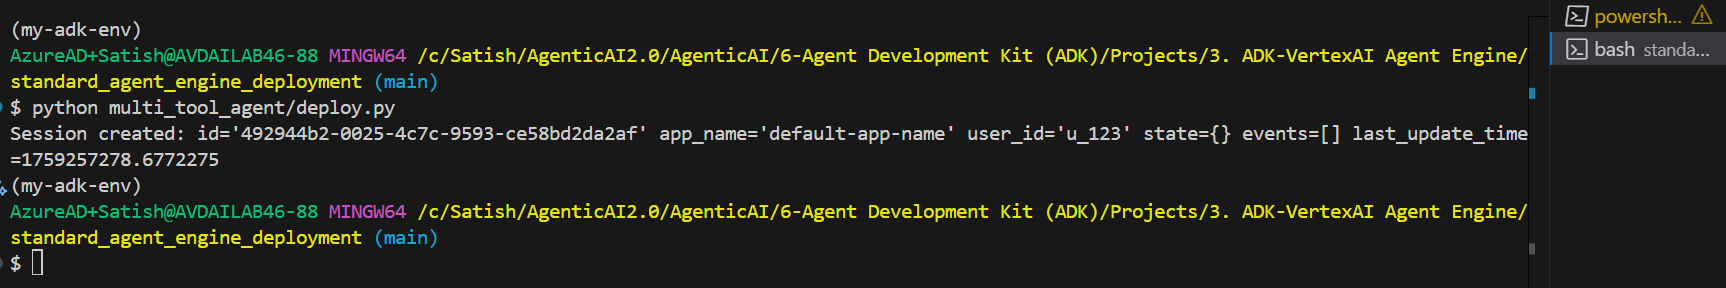

---

Send a query to the agent. Copy-paste the following code to your "deploy.py" python script or a notebook.

##### **deploy.py**
```python
events = []
async for event in app.async_stream_query(
    user_id="u_123",
    session_id=session.id,
    message="whats the weather in new york",
):
    events.append(event)

# The full event stream shows the agent's thought process
print("--- Full Event Stream ---")
for event in events:
    print(event)

# For quick tests, you can extract just the final text response
final_text_responses = [
    e for e in events
    if e.get("content", {}).get("parts", [{}])[0].get("text")
    and not e.get("content", {}).get("parts", [{}])[0].get("function_call")
]
if final_text_responses:
    print("\n--- Final Response ---")
    print(final_text_responses[0]["content"]["parts"][0]["text"])
```
----

##### [multi_tool_agent/agnet.py](https://github.com/google/adk-docs/blob/main/examples/python/snippets/get-started/multi_tool_agent/agent.py)
```Python
import datetime
from zoneinfo import ZoneInfo
from google.adk.agents import Agent

def get_weather(city: str) -> dict:
    """Retrieves the current weather report for a specified city.

    Args:
        city (str): The name of the city for which to retrieve the weather report.

    Returns:
        dict: status and result or error msg.
    """
    if city.lower() == "new york":
        return {
            "status": "success",
            "report": (
                "The weather in New York is sunny with a temperature of 25 degrees"
                " Celsius (77 degrees Fahrenheit)."
            ),
        }
    else:
        return {
            "status": "error",
            "error_message": f"Weather information for '{city}' is not available.",
        }


def get_current_time(city: str) -> dict:
    """Returns the current time in a specified city.

    Args:
        city (str): The name of the city for which to retrieve the current time.

    Returns:
        dict: status and result or error msg.
    """

    if city.lower() == "new york":
        tz_identifier = "America/New_York"
    else:
        return {
            "status": "error",
            "error_message": (
                f"Sorry, I don't have timezone information for {city}."
            ),
        }

    tz = ZoneInfo(tz_identifier)
    now = datetime.datetime.now(tz)
    report = (
        f'The current time in {city} is {now.strftime("%Y-%m-%d %H:%M:%S %Z%z")}'
    )
    return {"status": "success", "report": report}


root_agent = Agent(
    name="weather_time_agent",
    model="gemini-2.0-flash",
    description=(
        "Agent to answer questions about the time and weather in a city."
    ),
    instruction=(
        "You are a helpful agent who can answer user questions about the time and weather in a city."
    ),
    tools=[get_weather, get_current_time],
)
```
---

##### **deploy.py**
```Python
import vertexai
import asyncio
from agent import root_agent # modify this if your agent is not in agent.py

# TODO: Fill in these values for your project
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-central1"  # For other options, see https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions
STAGING_BUCKET = "gs://your-gcs-bucket-name"

# Initialize the Vertex AI SDK
vertexai.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)

### Prepare the agent for deployment
from vertexai import agent_engines

# Wrap the agent in an AdkApp object
app = agent_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
)

### Test agent locally (optional)
# Create a local session to maintain conversation history
async def main():
    session = await app.async_create_session(user_id="u_123")
    print("Session created:", session)

    ### Send a query to the agent. Copy-paste the following code to your "deploy.py" python script or a notebook.
    events = []
    async for event in app.async_stream_query(
        user_id="u_123",
        session_id=session.id,
        message="whats the weather in new york",
    ):
        events.append(event)

    # The full event stream shows the agent's thought process
    print("--- Full Event Stream ---")
    for event in events:
        print(event)

    # For quick tests, you can extract just the final text response
    final_text_responses = [
        e for e in events
        if e.get("content", {}).get("parts", [{}])[0].get("text")
        and not e.get("content", {}).get("parts", [{}])[0].get("function_call")
    ]
    if final_text_responses:
        print("\n--- Final Response ---")
        print(final_text_responses[0]["content"]["parts"][0]["text"])

# Run the async main using asyncio
if __name__ == "__main__":
    asyncio.run(main())
```
----
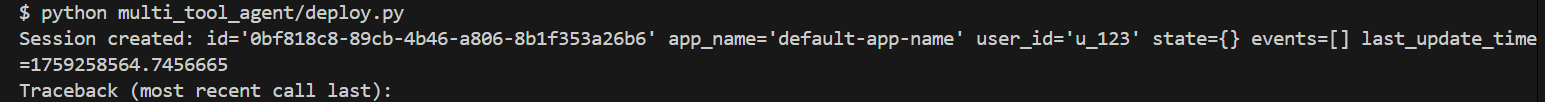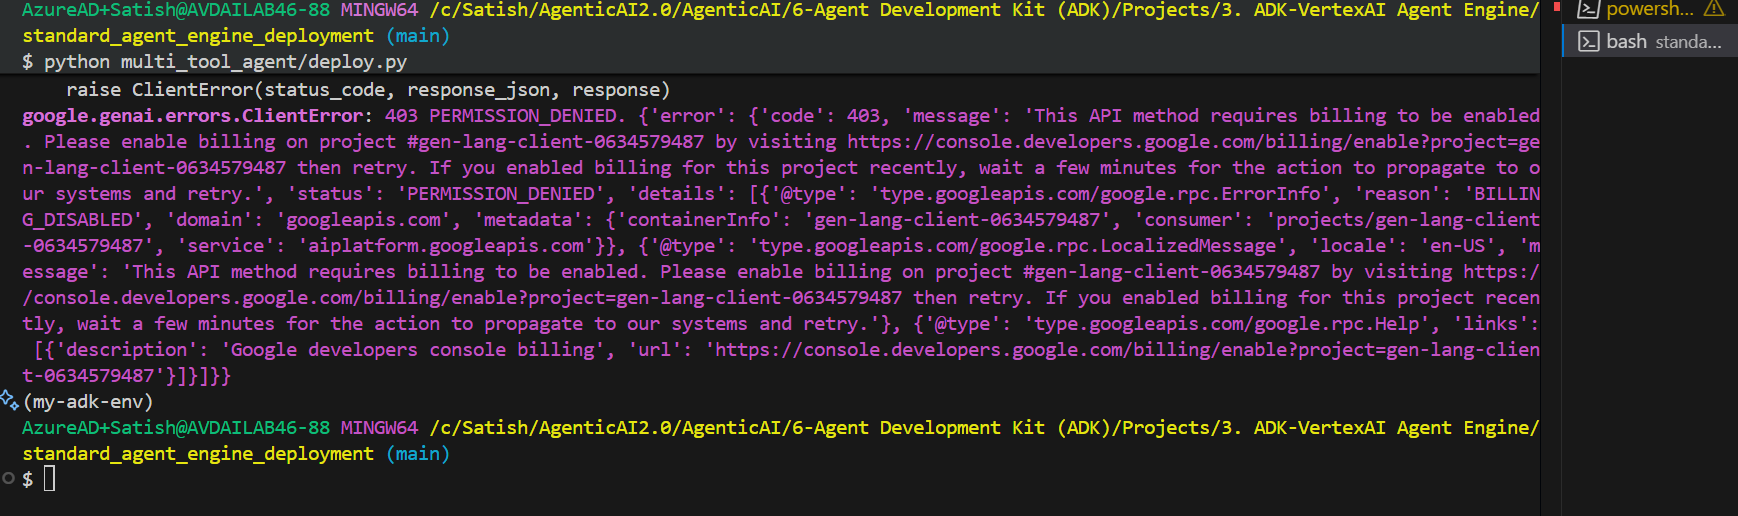 <br><br>

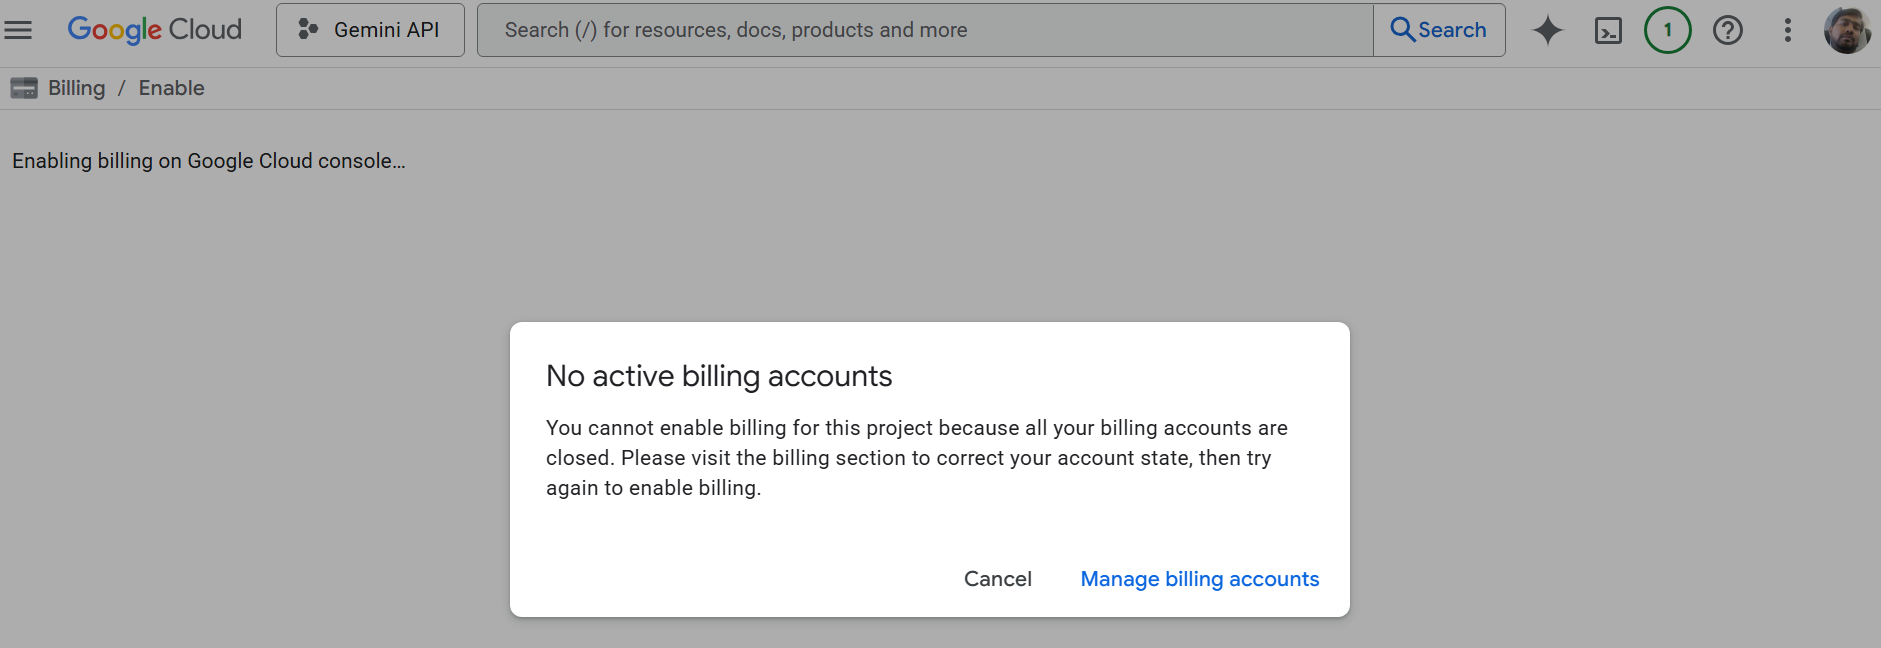 <br>

##### `Manage billing accounts`
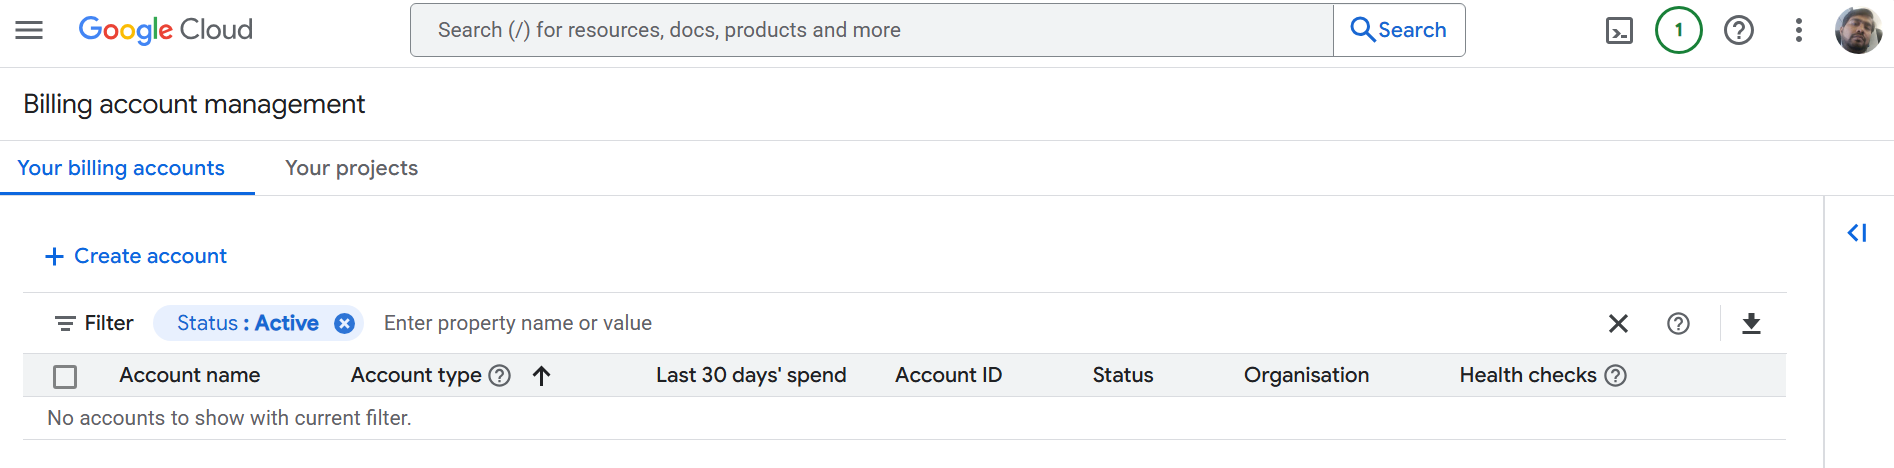 <br> 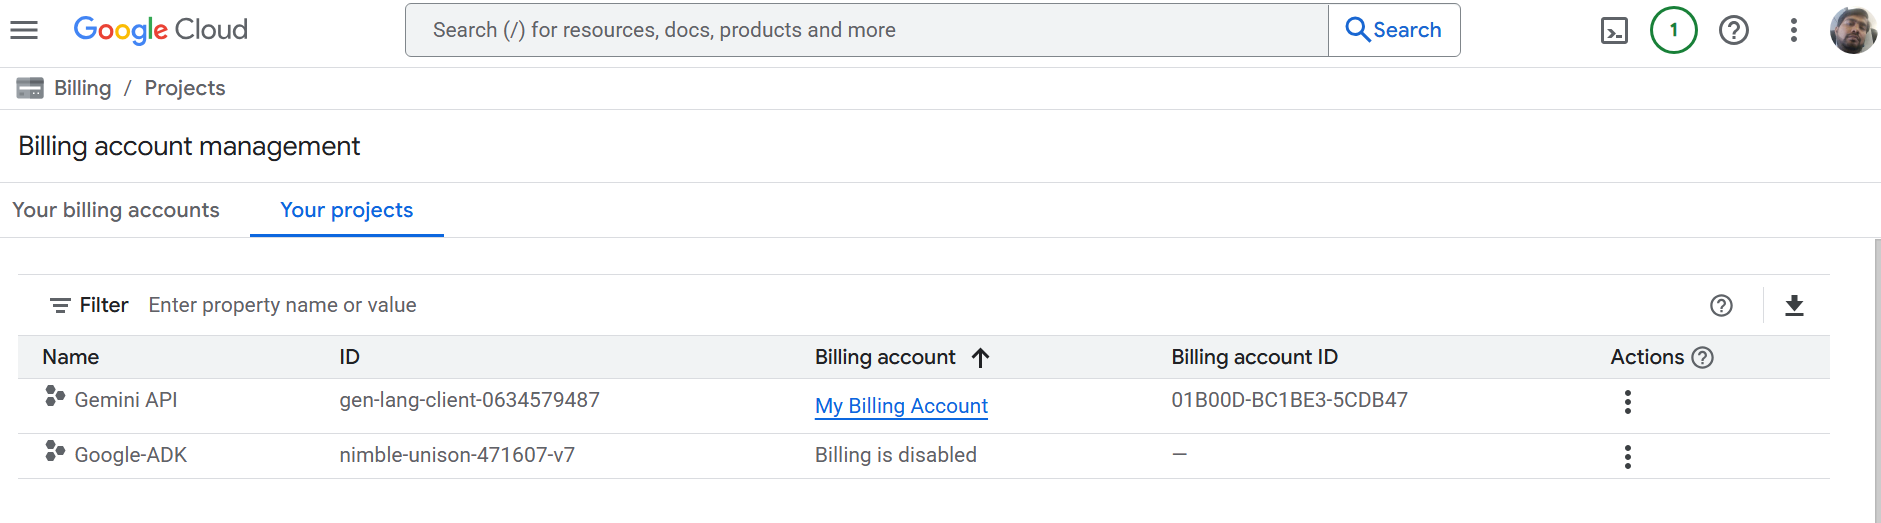 <br>
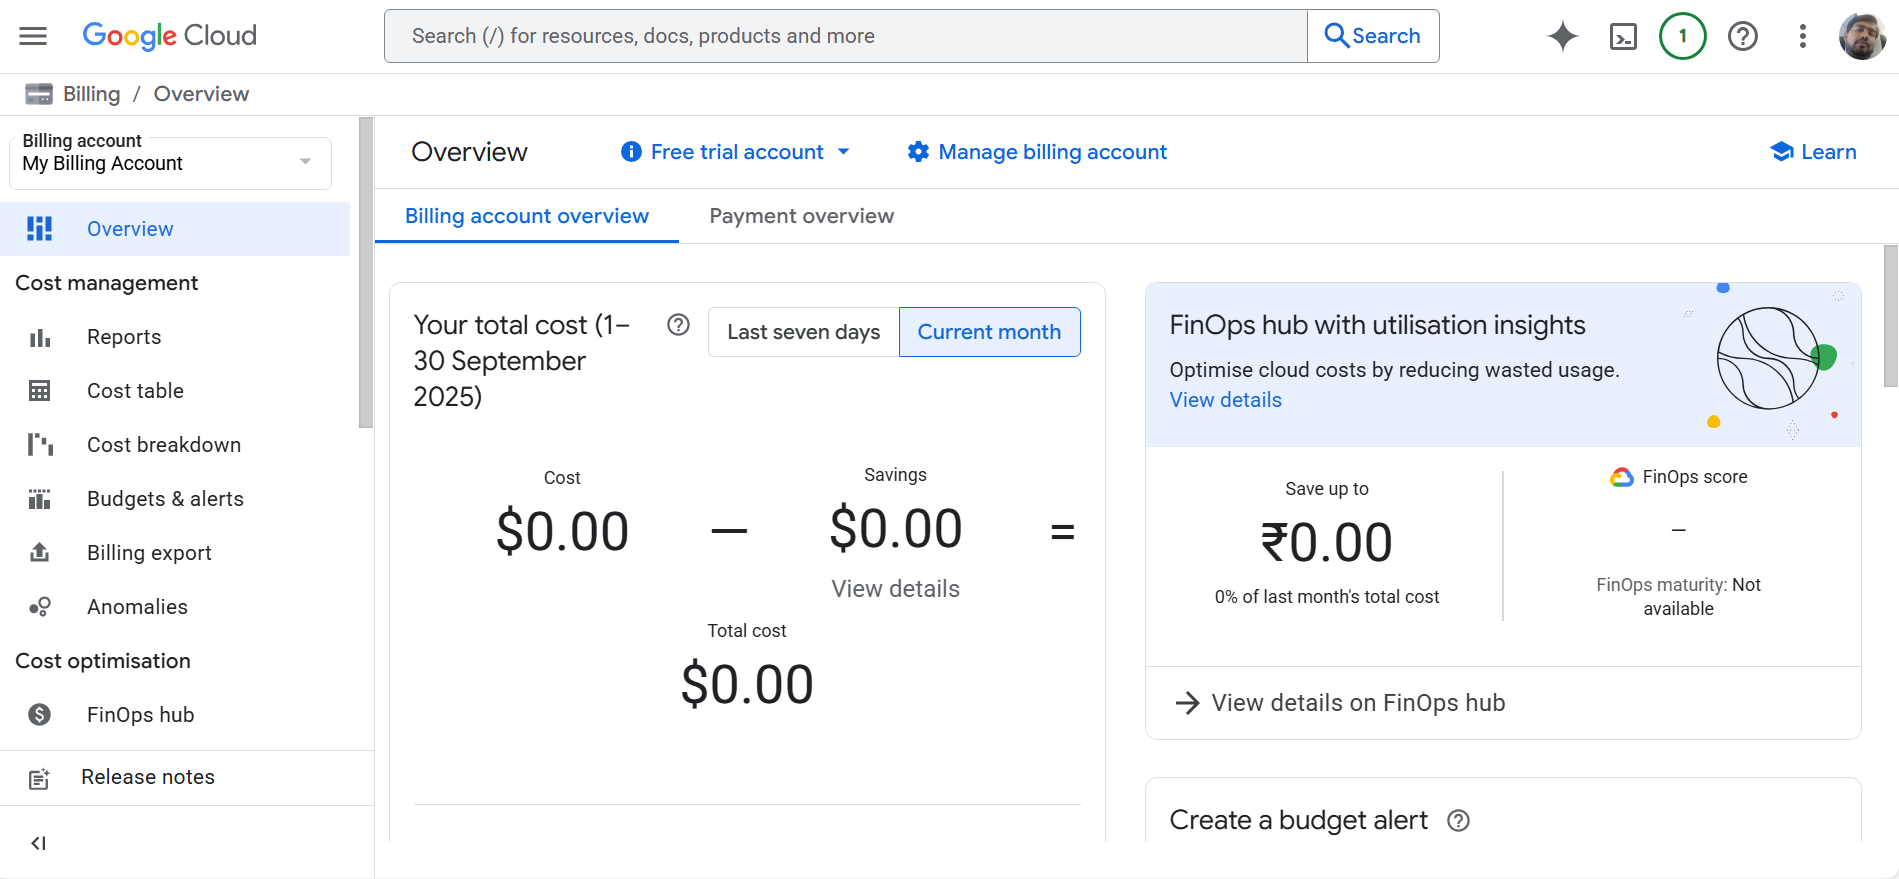

---

#### **Understanding the output**
When you run the code above, you will see a few types of events: <br>

- **Tool Call Event**: The model asks to call a tool (e.g., get_weather).

- **Tool Response Event**: The system provides the result of the tool call back to the model.

- **Model Response Event**: The final text response from the agent after it has processed the tool results.

**Expected output for** `async_stream_query` (local):
```Python
{'parts': [{'function_call': {'id': 'af-a33fedb0-29e6-4d0c-9eb3-00c402969395', 'args': {'city': 'new york'}, 'name': 'get_weather'}}], 'role': 'model'}
{'parts': [{'function_response': {'id': 'af-a33fedb0-29e6-4d0c-9eb3-00c402969395', 'name': 'get_weather', 'response': {'status': 'success', 'report': 'The weather in New York is sunny with a temperature of 25 degrees Celsius (41 degrees Fahrenheit).'}}}], 'role': 'user'}
{'parts': [{'text': 'The weather in New York is sunny with a temperature of 25 degrees Celsius (41 degrees Fahrenheit).'}], 'role': 'model'}
```

#### Deploy to agent engine
Once you are satisfied with your agent's local behavior, you can deploy it. You can do this using the Python SDK or the `adk` command-line tool.

This process packages your code, builds it into a container, and deploys it to the managed Agent Engine service. This process can take several minutes.

##### **ADK CLI**
You can deploy from your terminal using the `adk deploy` command line tool. The following example deploy command uses the `multi_tool_agent` sample code as the project to be deployed:
```bash
adk deploy agent_engine \
    --project=my-cloud-project-xxxxx \
    --region=us-central1 \
    --staging_bucket=gs://my-cloud-project-staging-bucket-name \
    --display_name="My Agent Name" \
    /multi_tool_agent
```
> Find the names of your available storage buckets in the [Cloud Storage Bucket](https://login.corp.google.com/request?s=pantheon.corp.google.com:443/uberproxy/&d=https://pantheon.corp.google.com/storage/browser%3Fupxsrf%3DAM2vRLk-Iaj8Nk6qq2w_C4XZZ8eSC652xxvrqIcb0cWFW-qS-Q:1759259283705&maxAge=1200&authLevel=2000000&keyIds=-1273316527,-221346616,-1229300527,-2055258506,-593293778,-1018294551&c=1) section of your deployment project in the Google Cloud Console. For more details on using the adk deploy command, see the [ADK CLI reference](https://google.github.io/adk-docs/api-reference/cli/cli.html#adk-deploy).

<br> 

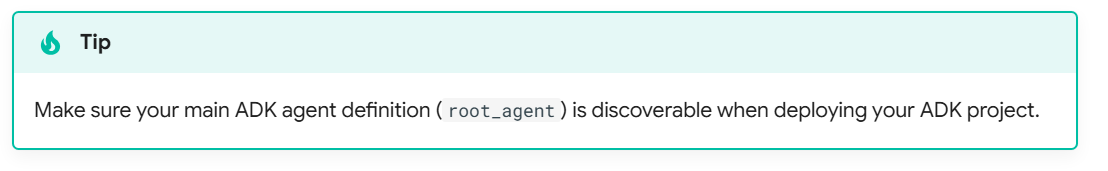

##### **Python**
This code block initiates the deployment from a Python script or notebook.
##### **deploy.py**
```Python
from vertexai import agent_engines

remote_app = agent_engines.create(
    agent_engine=app,
    requirements=[
        "google-cloud-aiplatform[adk,agent_engines]"   
    ]
)

print(f"Deployment finished!")
print(f"Resource Name: {remote_app.resource_name}")
# Resource Name: "projects/{PROJECT_NUMBER}/locations/{LOCATION}/reasoningEngines/{RESOURCE_ID}"
#       Note: The PROJECT_NUMBER is different than the PROJECT_ID.
```

**Monitoring and verification**
- You can monitor the deployment status in the [Agent Engine UI](https://console.cloud.google.com/vertex-ai/agents/agent-engines) in the Google Cloud Console.

- The `remote_app.resource_name` is the unique identifier for your deployed agent. You will need it to interact with the agent. You can also get this from the response returned by the ADK CLI command.

- For additional details, you can visit the Agent Engine documentation [deploying an agent](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/deploy) and [managing deployed agents](https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/manage/overview).

----

##### **deploy.py**
```Python
# Create a local session to maintain conversation history
import vertexai
import asyncio
from agent import root_agent # modify this if your agent is not in agent.py

# TODO: Fill in these values for your project
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-central1"  # For other options, see https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions
STAGING_BUCKET = "gs://your-gcs-bucket-name"

# Initialize the Vertex AI SDK
vertexai.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)

### Prepare the agent for deployment
from vertexai import agent_engines

# Wrap the agent in an AdkApp object
app = agent_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
)

### Deploy to agent engine
from vertexai import agent_engines
remote_app = agent_engines.create(
    agent_engine=app,
    requirements=[
        "google-cloud-aiplatform[adk,agent_engines]"   
    ]
)

print(f"Deployment finished!")
print(f"Resource Name: {remote_app.resource_name}")
# Resource Name: "projects/{PROJECT_NUMBER}/locations/{LOCATION}/reasoningEngines/{RESOURCE_ID}"
# Note: The PROJECT_NUMBER is different than the PROJECT_ID.

### Test agent locally (optional)
# Create a local session to maintain conversation history
# async def main():
#     session = await app.async_create_session(user_id="u_123")
#     print("Session created:", session)

#     ### Send a query to the agent. Copy-paste the following code to your "deploy.py" python script or a notebook.
#     events = []
#     async for event in app.async_stream_query(
#         user_id="u_123",
#         session_id=session.id,
#         message="whats the weather in new york",
#     ):
#         events.append(event)

#     # The full event stream shows the agent's thought process
#     print("--- Full Event Stream ---")
#     for event in events:
#         print(event)

#     # For quick tests, you can extract just the final text response
#     final_text_responses = [
#         e for e in events
#         if e.get("content", {}).get("parts", [{}])[0].get("text")
#         and not e.get("content", {}).get("parts", [{}])[0].get("function_call")
#     ]
#     if final_text_responses:
#         print("\n--- Final Response ---")
#         print(final_text_responses[0]["content"]["parts"][0]["text"])

# # Run the async main using asyncio
# if __name__ == "__main__":
#     asyncio.run(main())
```

----
```Python
# Create a local session to maintain conversation history
import vertexai
import asyncio
from agent import root_agent # modify this if your agent is not in agent.py

# TODO: Fill in these values for your project
PROJECT_ID = "gen-lang-client-0634579487"
LOCATION = "us-central1"  # For other options, see https://cloud.google.com/vertex-ai/generative-ai/docs/agent-engine/overview#supported-regions
STAGING_BUCKET = "gs://your-gcs-bucket-name"

# Initialize the Vertex AI SDK
vertexai.init(
    project=PROJECT_ID,
    location=LOCATION,
    staging_bucket=STAGING_BUCKET,
)

### Prepare the agent for deployment
from vertexai import agent_engines

# Wrap the agent in an AdkApp object
app = agent_engines.AdkApp(
    agent=root_agent,
    enable_tracing=True,
)

### Deploy to agent engine
from vertexai import agent_engines
remote_app = agent_engines.create(
    agent_engine=app,
    requirements=[
        "google-cloud-aiplatform[adk,agent_engines]"   
    ]
)

print(f"Deployment finished!")
print(f"Resource Name: {remote_app.resource_name}")
# Resource Name: "projects/{PROJECT_NUMBER}/locations/{LOCATION}/reasoningEngines/{RESOURCE_ID}"
# Note: The PROJECT_NUMBER is different than the PROJECT_ID.

### Test agent locally (optional)
async def main():
    session = await app.async_create_session(user_id="u_123")
    print("Session created:", session)

    ### Send a query to the agent. Copy-paste the following code to your "deploy.py" python script or a notebook.
    events = []
    async for event in app.async_stream_query(
        user_id="u_123",
        session_id=session.id,
        message="whats the weather in new york",
    ):
        events.append(event)

    # The full event stream shows the agent's thought process
    print("--- Full Event Stream ---")
    for event in events:
        print(event)

    # For quick tests, you can extract just the final text response
    final_text_responses = [
        e for e in events
        if e.get("content", {}).get("parts", [{}])[0].get("text")
        and not e.get("content", {}).get("parts", [{}])[0].get("function_call")
    ]
    if final_text_responses:
        print("\n--- Final Response ---")
        print(final_text_responses[0]["content"]["parts"][0]["text"])

# Run the async main using asyncio
if __name__ == "__main__":
    asyncio.run(main())
```
---